In [1]:
library(ggplot2)

library(gridExtra)
library(plotly)

library(reshape2)


Warning message:
"le package 'ggplot2' a été compilé avec la version R 4.5.3"
Warning message:
"le package 'gridExtra' a été compilé avec la version R 4.5.3"

Attachement du package : 'plotly'


L'objet suivant est masqué depuis 'package:ggplot2':

    last_plot


L'objet suivant est masqué depuis 'package:stats':

    filter


L'objet suivant est masqué depuis 'package:graphics':

    layout




In [2]:
data<-read.csv("new_games.csv",header = TRUE)

In [3]:
summary(data)

     AppID             Name           Release.date       Estimated.owners  
 Min.   :     10   Length:122611      Length:122611      Length:122611     
 1st Qu.:1063175   Class :character   Class :character   Class :character  
 Median :1907380   Mode  :character   Mode  :character   Mode  :character  
 Mean   :1985386                                                           
 3rd Qu.:2869560                                                           
 Max.   :4264350                                                           
                                                                           
    Peak.CCU          Required.age         Price             Discount     
 Min.   :0.000e+00   Min.   : 0.0000   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   1st Qu.: 0.0000   1st Qu.:   0.550   1st Qu.:  0.00  
 Median :0.000e+00   Median : 0.0000   Median :   2.240   Median :  0.00  
 Mean   :5.459e+01   Mean   : 0.1676   Mean   :   4.765   Mean   : 18.35  
 3rd Qu.:0.000e+0

# Conversion des variables lues en tant que quantitatives en qualitatives

Il me semble que les variables ci-dessous sont plutôt des variables qualitatives donc je les ai converti.

In [4]:

data[,"Estimated.owners"]=as.factor(data[,"Estimated.owners"])
data[,"Required.age"]=as.factor(data[,"Required.age"])
data[,"Windows"]=as.factor(data[,"Windows"])
data[,"Mac"]=as.factor(data[,"Mac"])
data[,"Linux"]=as.factor(data[,"Linux"])


summary(data)

       

     AppID             Name           Release.date      
 Min.   :     10   Length:122611      Length:122611     
 1st Qu.:1063175   Class :character   Class :character  
 Median :1907380   Mode  :character   Mode  :character  
 Mean   :1985386                                        
 3rd Qu.:2869560                                        
 Max.   :4264350                                        
                                                        
        Estimated.owners    Peak.CCU          Required.age   
 0 - 20000      :75404   Min.   :0.000e+00   0      :121339  
 0 - 0          :21641   1st Qu.:0.000e+00   17     :   828  
 20000 - 50000  :11396   Median :0.000e+00   13     :   175  
 50000 - 100000 : 5355   Mean   :5.459e+01   18     :   164  
 100000 - 200000: 3454   3rd Qu.:0.000e+00   16     :    32  
 200000 - 500000: 2853   Max.   :1.014e+06   10     :    26  
 (Other)        : 2508                       (Other):    47  
     Price             Discount        DLC.count

#  Suppresion de variables inutiles à l'exploration des données

J'ai choisi de supprimer plusieurs variable qui à mon avis ne seraient pas pertinente lors de l'analyse de certaine donnée. J'ai aussi supprimé la variable Movies car elle ne contennait que des NA. score rank ne contient que 40 valeurs.

In [5]:
library(tidyverse)
data1 <- data %>% select(-c(AppID, About.the.game, Reviews,Movies,Header.image,Support.email,Support.url,Notes,Metacritic.url,Screenshots,Score.rank,Website))

Warning message:
"le package 'tibble' a été compilé avec la version R 4.5.3"
Warning message:
"le package 'tidyr' a été compilé avec la version R 4.5.3"
Warning message:
"le package 'purrr' a été compilé avec la version R 4.5.3"
Warning message:
"le package 'dplyr' a été compilé avec la version R 4.5.3"
Warning message:
"le package 'stringr' a été compilé avec la version R 4.5.3"
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::combine() masks gridExtra::combine()
✖ dplyr::filter()  masks plotly::filter(), stats::filter()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force a

In [6]:
head(data1)

,Name,Release.date,Estimated.owners,Peak.CCU,Required.age,Price,Discount,DLC.count,Supported.languages,Full.audio.languages,⋯,Recommendations,Average.playtime.forever,Average.playtime.two.weeks,Median.playtime.forever,Median.playtime.two.weeks,Developers,Publishers,Categories,Genres,Tags
,<chr>,<chr>,<fct>,<int>,<fct>,<dbl>,<int>,<int>,<chr>,<chr>,⋯,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,[],[],⋯,0,0,0,0,0,,,,,
2,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,['English'],[],⋯,231,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,Family Sharing",Adventure,"Adventure,Visual Novel,Anime,Cute"
3,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"['English', 'French', 'German', 'Russian']",[],⋯,0,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Object,2D,Colorful,Stylized,Logic,Mystery,Atmospheric,Family Friendly,PvE,Tutorial,Singleplayer,Tabletop"
4,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,['Korean'],['Korean'],⋯,0,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",
5,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,['English'],['English'],⋯,0,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Family Sharing","Action,Early Access",
6,Agony VR,"Apr 5, 2023",0 - 20000,0,0,13.99,0,0,"['English', 'French', 'Italian', 'German', 'Spanish - Spain', 'Polish', 'Portuguese - Portugal', 'Russian', 'Turkish']","['English', 'Turkish']",⋯,0,0,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR Only,Family Sharing","Action,Adventure",


# Analyse de la qualités des individus (les jeux vidéos): filtrage

Avant de commencer notre analyse, nous allons faire un premier filtrage sur les individus. En effet, nous cherchons à supprimer pour les variables suivantes les cases vides, les cases contenant des NAN et pour Supported.language les cases ne contenant pas de valeurs soit $[]$:Publishers,Developers,Name,Supported.languages,Genres. Nous avons effectué ce filtage car nous avons jugé inutilisable les individus(les jeux) qui au minimun n'avaient aucunes données pour ces variables là.

In [7]:

for (col in colnames(data1))
{

    print((paste(col,sum(is.na(data1[,col]) | data1[,col] == "" |data1[,col] == "[]" ))))
    
}

[1] "Name 1"
[1] "Release.date 0"
[1] "Estimated.owners 0"
[1] "Peak.CCU 0"
[1] "Required.age 0"
[1] "Price 0"
[1] "Discount 0"
[1] "DLC.count 0"
[1] "Supported.languages 8380"
[1] "Full.audio.languages 72730"
[1] "Windows 0"
[1] "Mac 0"
[1] "Linux 0"
[1] "Metacritic.score 0"
[1] "User.score 0"
[1] "Positive 0"
[1] "Negative 0"
[1] "Achievements 0"
[1] "Recommendations 0"
[1] "Average.playtime.forever 0"
[1] "Average.playtime.two.weeks 0"
[1] "Median.playtime.forever 0"
[1] "Median.playtime.two.weeks 0"
[1] "Developers 8432"
[1] "Publishers 8838"
[1] "Categories 8953"
[1] "Genres 8413"
[1] "Tags 39265"


In [8]:

dat_filtered <- data1 %>%
  mutate(
    # 1. Fusion des LANGUES (Supported + Audio)
    temp_langs = paste(Supported.languages, Full.audio.languages, sep = ","),
    Language= temp_langs %>%
      str_remove_all("[\\[\\]'\" ]") %>%
      str_replace_all("(?i)na|nan|null", "") %>%
      str_replace_all(",+", ",") %>%
      str_remove("^,") %>%
      str_remove(",$"),

    # 2. Fusion des GENRES et Tags
    temp_genres_cat = paste(Genres, Tags, sep = ","),
    TagGenre = temp_genres_cat %>%
      str_remove_all("[\\[\\]'\" ]") %>%
      str_replace_all("(?i)na|nan|null", "") %>%
      str_replace_all(",+", ",") %>%
      str_remove("^,") %>%
      str_remove(",$")
  ) %>%
  # 3. Étape finale : On retire les doublons internes (ex: si "Action" est dans les deux)
  mutate(
    Language = sapply(str_split(Language, ","), function(x) paste(unique(x[x != ""]), collapse = ", ")),
    TagGenre = sapply(str_split(TagGenre, ","), function(x) paste(unique(x[x != ""]), collapse = ", "))
  ) %>%
  # 4. On nettoie les colonnes temporaires
  select(-temp_langs, -temp_genres_cat)

In [9]:

data2 <- dat_filtered %>% select(-c(Supported.languages,Full.audio.languages,Tags, Genres))
summary(data2)

     Name           Release.date              Estimated.owners
 Length:122611      Length:122611      0 - 20000      :75404  
 Class :character   Class :character   0 - 0          :21641  
 Mode  :character   Mode  :character   20000 - 50000  :11396  
                                       50000 - 100000 : 5355  
                                       100000 - 200000: 3454  
                                       200000 - 500000: 2853  
                                       (Other)        : 2508  
    Peak.CCU          Required.age        Price             Discount     
 Min.   :0.000e+00   0      :121339   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   17     :   828   1st Qu.:   0.550   1st Qu.:  0.00  
 Median :0.000e+00   13     :   175   Median :   2.240   Median :  0.00  
 Mean   :5.459e+01   18     :   164   Mean   :   4.765   Mean   : 18.35  
 3rd Qu.:0.000e+00   16     :    32   3rd Qu.:   5.240   3rd Qu.: 40.00  
 Max.   :1.014e+06   10     :    26   Max.   : 999.9

In [10]:
head(data2)

,Name,Release.date,Estimated.owners,Peak.CCU,Required.age,Price,Discount,DLC.count,Windows,Mac,⋯,Recommendations,Average.playtime.forever,Average.playtime.two.weeks,Median.playtime.forever,Median.playtime.two.weeks,Developers,Publishers,Categories,Language,TagGenre
,<chr>,<chr>,<fct>,<int>,<fct>,<dbl>,<int>,<int>,<fct>,<fct>,⋯,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,True,False,⋯,0,0,0,0,0,,,,,
2,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,True,False,⋯,231,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,Family Sharing",English,"Adventure, VisualNovel, Anime, Cute"
3,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,True,True,⋯,0,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing","English, French, German, Russian","Casual, CardGame, Solitaire, Puzzle, HiddenObject, 2D, Colorful, Stylized, Logic, Mystery, Atmospheric, FamilyFriendly, PvE, Tutorial, Singleplayer, Tabletop"
4,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,True,False,⋯,0,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing",Korean,"Casual, Indie, Simulation"
5,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,True,False,⋯,0,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Family Sharing",English,"Action, EarlyAccess"
6,Agony VR,"Apr 5, 2023",0 - 20000,0,0,13.99,0,0,True,False,⋯,0,0,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR Only,Family Sharing","English, French, Italian, German, Spanish-Spain, Polish, Portuguese-Portugal, Russian, Turkish","Action, Adventure"


In [11]:
data_filtered <- data2 %>%
  filter(
    (TagGenre != "" ) |
    (Categories != "" ) |
    ( Language != "" )
  )


In [12]:
summary(data_filtered)

     Name           Release.date              Estimated.owners
 Length:114629      Length:114629      0 - 20000      :75404  
 Class :character   Class :character   0 - 0          :13659  
 Mode  :character   Mode  :character   20000 - 50000  :11396  
                                       50000 - 100000 : 5355  
                                       100000 - 200000: 3454  
                                       200000 - 500000: 2853  
                                       (Other)        : 2508  
    Peak.CCU          Required.age        Price             Discount     
 Min.   :0.000e+00   0      :113357   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   17     :   828   1st Qu.:   0.890   1st Qu.:  0.00  
 Median :0.000e+00   13     :   175   Median :   2.690   Median :  0.00  
 Mean   :5.839e+01   18     :   164   Mean   :   5.097   Mean   : 19.63  
 3rd Qu.:0.000e+00   16     :    32   3rd Qu.:   5.990   3rd Qu.: 45.00  
 Max.   :1.014e+06   10     :    26   Max.   : 999.9

In [13]:
for (col in colnames(data_filtered)) {
    # On calcule le nombre de vides/NA/[]
    nb_vides <- sum(is.na(data_filtered[[col]]) | 
                    data_filtered[[col]] == "" | 
                    data_filtered[[col]] == "[]", 
                    na.rm = TRUE)
    
    # On affiche le résultat de manière lisible
    print(paste(col, ":", nb_vides))
}

[1] "Name : 0"
[1] "Release.date : 0"
[1] "Estimated.owners : 0"
[1] "Peak.CCU : 0"
[1] "Required.age : 0"
[1] "Price : 0"
[1] "Discount : 0"
[1] "DLC.count : 0"
[1] "Windows : 0"
[1] "Mac : 0"
[1] "Linux : 0"
[1] "Metacritic.score : 0"
[1] "User.score : 0"
[1] "Positive : 0"
[1] "Negative : 0"
[1] "Achievements : 0"
[1] "Recommendations : 0"
[1] "Average.playtime.forever : 0"
[1] "Average.playtime.two.weeks : 0"
[1] "Median.playtime.forever : 0"
[1] "Median.playtime.two.weeks : 0"
[1] "Developers : 450"
[1] "Publishers : 856"
[1] "Categories : 971"
[1] "Language : 398"
[1] "TagGenre : 320"


In [14]:
nbr_suppr <- nrow(data1) - nrow(data_filtered)

print(paste("Nous avons supprimé", nbr_suppr, "individus."))

[1] "Nous avons supprimé 7982 individus."


## Traitement des doublons (jeux qui ont le même nom)

In [15]:
doublons <- data_filtered %>%
  group_by(Name) %>%
  filter(n() > 1) %>%
  arrange(Name)
head(doublons,20)

total_doublons <- nrow(doublons)

noms_problematiques <- n_distinct(doublons$Name)

print(paste("Il y a", total_doublons, "lignes qui concernent", noms_problematiques, "noms de jeux en double."))

Name,Release.date,Estimated.owners,Peak.CCU,Required.age,Price,Discount,DLC.count,Windows,Mac,⋯,Recommendations,Average.playtime.forever,Average.playtime.two.weeks,Median.playtime.forever,Median.playtime.two.weeks,Developers,Publishers,Categories,Language,TagGenre
<chr>,<chr>,<fct>,<int>,<fct>,<dbl>,<int>,<int>,<fct>,<fct>,⋯,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
A Better Tomorrow,"Jul 31, 2024",0 - 20000,0,0,0.00,0,0,True,False,⋯,0,0,0,0,0,GoragarX,GoragarX,Single-player,"English, Spanish-Spain","Casual, Strategy, FreeToPlay"
A Better Tomorrow,"Sep 30, 2025",0 - 0,0,0,0.00,0,0,True,False,⋯,0,0,0,0,0,WoofWoofStudio,WoofWoofStudio,"Single-player,Steam Achievements,Custom Volume Controls,Playable without Timed Input",SimplifiedChinese,"Indie, FreeToPlay, EarlyAccess"
A Walk in the Woods,"Apr 21, 2020",0 - 20000,0,0,0.00,0,0,True,False,⋯,0,0,0,0,0,Brightdawn Entertainment,Brightdawn Entertainment,"Single-player,Full controller support,Tracked Controller Support,VR Only",English,"Indie, Simulation, VR, Singleplayer, FamilyFriendly"
A Walk in the Woods,"May 1, 2018",100000 - 200000,0,0,0.00,0,0,True,False,⋯,0,13,0,13,0,Something Dark Studios,Something Dark Studios,"Multi-player,PvP,Online PvP,Co-op,Online Co-op,Partial Controller Support",English,"Adventure, FreeToPlay, Indie, FreetoPlay, Horror, Multiplayer, Co-op, SurvivalHorror, Survival"
ALONE,"May 31, 2021",50000 - 100000,0,0,0.74,0,0,True,False,⋯,200,0,0,0,0,DakeCraft,PsychoFlux Entertainment,"Single-player,Steam Achievements,Steam Cloud,Family Sharing","English, Korean, Thai","Adventure, Casual, Indie, Puzzle, FemaleProtagonist, RPG, 2D, Top-Down, Horror, PsychologicalHorror, ChoicesMatter, MultipleEndings, PixelGraphics, Investigation, SurvivalHorror, Multiplayer, Singleplayer, RPGMaker, FreetoPlay, SexualContent"
ALONE,"Dec 23, 2021",0 - 20000,0,0,8.99,0,0,True,False,⋯,0,0,0,0,0,True Nuke,True Nuke,"Single-player,Family Sharing",English,"Action, Adventure, Indie, PsychologicalHorror, Exploration, HeroShooter, FPS, Shooter, Action-Adventure, 3D, Horror, Stealth, ArtificialIntelligence, Physics, InventoryMagement, Singleplayer, SurvivalHorror"
ASTRA,"Oct 12, 2021",0 - 20000,0,0,0.89,91,0,True,False,⋯,0,0,0,0,0,Piece Of Voxel,Piece Of Voxel,"Single-player,Family Sharing","English, Russian","Action, Adventure, Casual, Indie, Stylized, Typing, 2DPlatformer, ChooseYourOwdventure, SpaceSim, Programming, OldSchool, 2D, Abstract, Runner, Dinosaurs, SideScroller, Puzzle, Point&Click, Arcade, Platformer, Text-Based"
ASTRA,"Jan 5, 2024",20000 - 50000,0,0,2.99,0,0,True,False,⋯,0,0,0,0,0,NewOrderFantasySimulations,NewOrderFantasySimulations,"Single-player,Steam Achievements,Family Sharing",English,"Action, Adventure, DarkFantasy, OpenWorld, Exploration, Capitalism, Medieval, Abstract, ActionRPG, HackandSlash, DungeonCrawler, 3D, Stylized, Retro, CharacterCustomization, Combat, Singleplayer"
ASTRA,"Feb 26, 2021",0 - 20000,0,0,0.00,0,0,True,False,⋯,0,0,0,0,0,Amemi Kinosuke,Personal,,Japanese,AudioProduction


[1] "Il y a 2049 lignes qui concernent 926 noms de jeux en double."


In [16]:
data3 <- data_filtered %>%
  # 1. On trie par nom, puis par Peak.CCU du plus grand au plus petit
  # Comme ça, la ligne avec le plus gros score arrive en premier pour chaque jeu
  arrange(Name, Developers, Publishers, desc(Peak.CCU)) %>%
  
  # 2. On ne garde que la première occurrence pour chaque combinaison identique
  # R va garder la 1ère ligne rencontrée (donc celle avec le CCU max grâce au tri)
  distinct(Name, Developers, Publishers, .keep_all = TRUE)

In [17]:
nbr_suppr <- nrow(data_filtered) - nrow(data3)

print(paste("Nous avons supprimé", nbr_suppr, "individus."))

[1] "Nous avons supprimé 116 individus."


# Etude sur variables

# Variables quantitatives

In [18]:
data3$Positive=data3$Positive+1
data3$Negative=data3$Negative+1
data3$Recommendations=data3$Recommendations+1

data3[, "LPositive"] <- log(data3[, "Positive"])

data3[, "LNegative"] <- log(data3[, "Negative"])
data3[, "LRecommendations"] <- log(data3[, "Recommendations"])

In [19]:
data4 <- data3 %>% select(-c(Positive,Negative))
summary(data4)

     Name           Release.date              Estimated.owners
 Length:114513      Length:114513      0 - 20000      :75337  
 Class :character   Class :character   0 - 0          :13649  
 Mode  :character   Mode  :character   20000 - 50000  :11395  
                                       50000 - 100000 : 5349  
                                       100000 - 200000: 3450  
                                       200000 - 500000: 2845  
                                       (Other)        : 2488  
    Peak.CCU          Required.age        Price             Discount     
 Min.   :0.000e+00   0      :113288   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   17     :   782   1st Qu.:   0.890   1st Qu.:  0.00  
 Median :0.000e+00   13     :   175   Median :   2.690   Median :  0.00  
 Mean   :5.844e+01   18     :   164   Mean   :   5.093   Mean   : 19.62  
 3rd Qu.:0.000e+00   16     :    31   3rd Qu.:   5.990   3rd Qu.: 45.00  
 Max.   :1.014e+06   10     :    26   Max.   : 999.9

language count variable

In [20]:
data5 <- data4 %>%
  mutate(LanguageCount = case_when(
      Language == "" ~ 0, # Cas où c'est vide
    TRUE ~ str_count(Language, ",") + 1              
  ))

In [21]:
data5$Average.playtime.forever=data3$Average.playtime.forever+1
data5$Median.playtime.forever=data5$Median.playtime.forever+1


data5[, "LAverage.playtime.forever"] <- log(data5[, "Average.playtime.forever"])

data5[, "LMedian.playtime.forever"] <- log(data5[, "Median.playtime.forever"])

In [22]:
data5 <- data5 %>% select(-c(Average.playtime.forever,Median.playtime.forever))
summary(data5)

     Name           Release.date              Estimated.owners
 Length:114513      Length:114513      0 - 20000      :75337  
 Class :character   Class :character   0 - 0          :13649  
 Mode  :character   Mode  :character   20000 - 50000  :11395  
                                       50000 - 100000 : 5349  
                                       100000 - 200000: 3450  
                                       200000 - 500000: 2845  
                                       (Other)        : 2488  
    Peak.CCU          Required.age        Price             Discount     
 Min.   :0.000e+00   0      :113288   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   17     :   782   1st Qu.:   0.890   1st Qu.:  0.00  
 Median :0.000e+00   13     :   175   Median :   2.690   Median :  0.00  
 Mean   :5.844e+01   18     :   164   Mean   :   5.093   Mean   : 19.62  
 3rd Qu.:0.000e+00   16     :    31   3rd Qu.:   5.990   3rd Qu.: 45.00  
 Max.   :1.014e+06   10     :    26   Max.   : 999.9

In [164]:
data_rename <- data5 %>%
  mutate(Estimated.owners = fct_recode(Estimated.owners,
    "0"           = "0 - 0",
    "0-20K"       = "0 - 20000",
    "20K-50K"     = "20000 - 50000",
    "50K-100K"    = "50000 - 100000",
    "100K-200K"   = "100000 - 200000",
    "200K-500K"   = "200000 - 500000",
    "500K-1M"     = "500000 - 1000000",
    "1M-2M"       = "1000000 - 2000000",
    "2M-5M"       = "2000000 - 5000000",
    "5M-10M"      = "5000000 - 10000000",
    "10M-20M"     = "10000000 - 20000000",
    "20M-50M"     = "20000000 - 50000000",
    "50M-100M"    = "50000000 - 100000000",
    "100M-200M"   = "100000000 - 200000000"
  ))

ordre_logique <- c(
  "0", "0-20K", "20K-50K", "50K-100K", "100K-200K", 
  "200K-500K", "500K-1M", "1M-2M", "2M-5M", "5M-10M", 
  "10M-20M", "20M-50M", "50M-100M", "100M-200M"
)

data_ready <- data_rename %>%
  mutate(Estimated.owners = fct_relevel(Estimated.owners, ordre_logique))

In [165]:
summary(data_ready)

     Name           Release.date        Estimated.owners    Peak.CCU        
 Length:114513      Length:114513      0-20K    :75337   Min.   :0.000e+00  
 Class :character   Class :character   0        :13649   1st Qu.:0.000e+00  
 Mode  :character   Mode  :character   20K-50K  :11395   Median :0.000e+00  
                                       50K-100K : 5349   Mean   :5.844e+01  
                                       100K-200K: 3450   3rd Qu.:0.000e+00  
                                       200K-500K: 2845   Max.   :1.014e+06  
                                       (Other)  : 2488                      
  Required.age        Price             Discount        DLC.count        
 0      :113288   Min.   :   0.000   Min.   :  0.00   Min.   :   0.0000  
 17     :   782   1st Qu.:   0.890   1st Qu.:  0.00   1st Qu.:   0.0000  
 13     :   175   Median :   2.690   Median :  0.00   Median :   0.0000  
 18     :   164   Mean   :   5.093   Mean   : 19.62   Mean   :   0.5549  
 16     :    3

# Release date

In [166]:
head(data_ready$Release.date)

[1] "Oct 13, 2023" "Mar 3, 2016"  "Apr 28, 2020" "Jun 6, 2018"  "Jun 13, 2018"
[6] "May 27, 2024"

In [167]:
data_ready$Release.date <- sub(".*, ", "", data_ready$Release.date)
head(data_ready$Release.date)

[1] "2023" "2016" "2020" "2018" "2018" "2024"

In [168]:
data_ready$Release.date = as.factor(data_ready$Release.date)

In [169]:
summary(data_ready$Release.date)

1997  1998  1999  2000  2001  2002  2003  2004  2005  2006  2007  2008  2009 
    2     1     2     2     4     1     3     5     7    63    85   153   308 
 2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022 
  242   252   319   464  1517  2501  4139  5917  7441  7242  8746 10441 11403 
 2023  2024  2025  2026 
13337 18104 21728    84

In [170]:
col=as.character(1997:2013)
sum(as.numeric(data_ready$Release.date) < 17, na.rm = TRUE) #nb d'individus qui ont une release date inferieure ou égale à 2013

[1] 1449

In [171]:
#On regroupe aussi les jeux qui sont sortis en 2025 et 2026

data_ready <- data_ready %>%
  mutate(Release.date = fct_collapse(as.factor(Release.date),
    "1997-2013" =col,
    "2025-2026"= as.character(2025:2026)                                 
  ))

head(data_ready$Release.date)

[1] 2023 2016 2020 2018 2018 2024
13 Levels: 1997-2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 ... 2025-2026

# Préparation données  pour pca

In [172]:
data_quanti<- data_ready %>%
  select(where(is.numeric)) 

In [173]:
summary(data_quanti)

    Peak.CCU             Price             Discount        DLC.count        
 Min.   :0.000e+00   Min.   :   0.000   Min.   :  0.00   Min.   :   0.0000  
 1st Qu.:0.000e+00   1st Qu.:   0.890   1st Qu.:  0.00   1st Qu.:   0.0000  
 Median :0.000e+00   Median :   2.690   Median :  0.00   Median :   0.0000  
 Mean   :5.844e+01   Mean   :   5.093   Mean   : 19.62   Mean   :   0.5549  
 3rd Qu.:0.000e+00   3rd Qu.:   5.990   3rd Qu.: 45.00   3rd Qu.:   0.0000  
 Max.   :1.014e+06   Max.   : 999.980   Max.   :100.00   Max.   :3703.0000  
 Metacritic.score   User.score         Achievements     Recommendations    
 Min.   : 0.000   Min.   :  0.00000   Min.   :   0.00   Min.   :      1.0  
 1st Qu.: 0.000   1st Qu.:  0.00000   1st Qu.:   0.00   1st Qu.:      1.0  
 Median : 0.000   Median :  0.00000   Median :   5.00   Median :      1.0  
 Mean   : 2.703   Mean   :  0.02628   Mean   :  19.19   Mean   :    955.7  
 3rd Qu.: 0.000   3rd Qu.:  0.00000   3rd Qu.:  20.00   3rd Qu.:      1.0  
 Max.

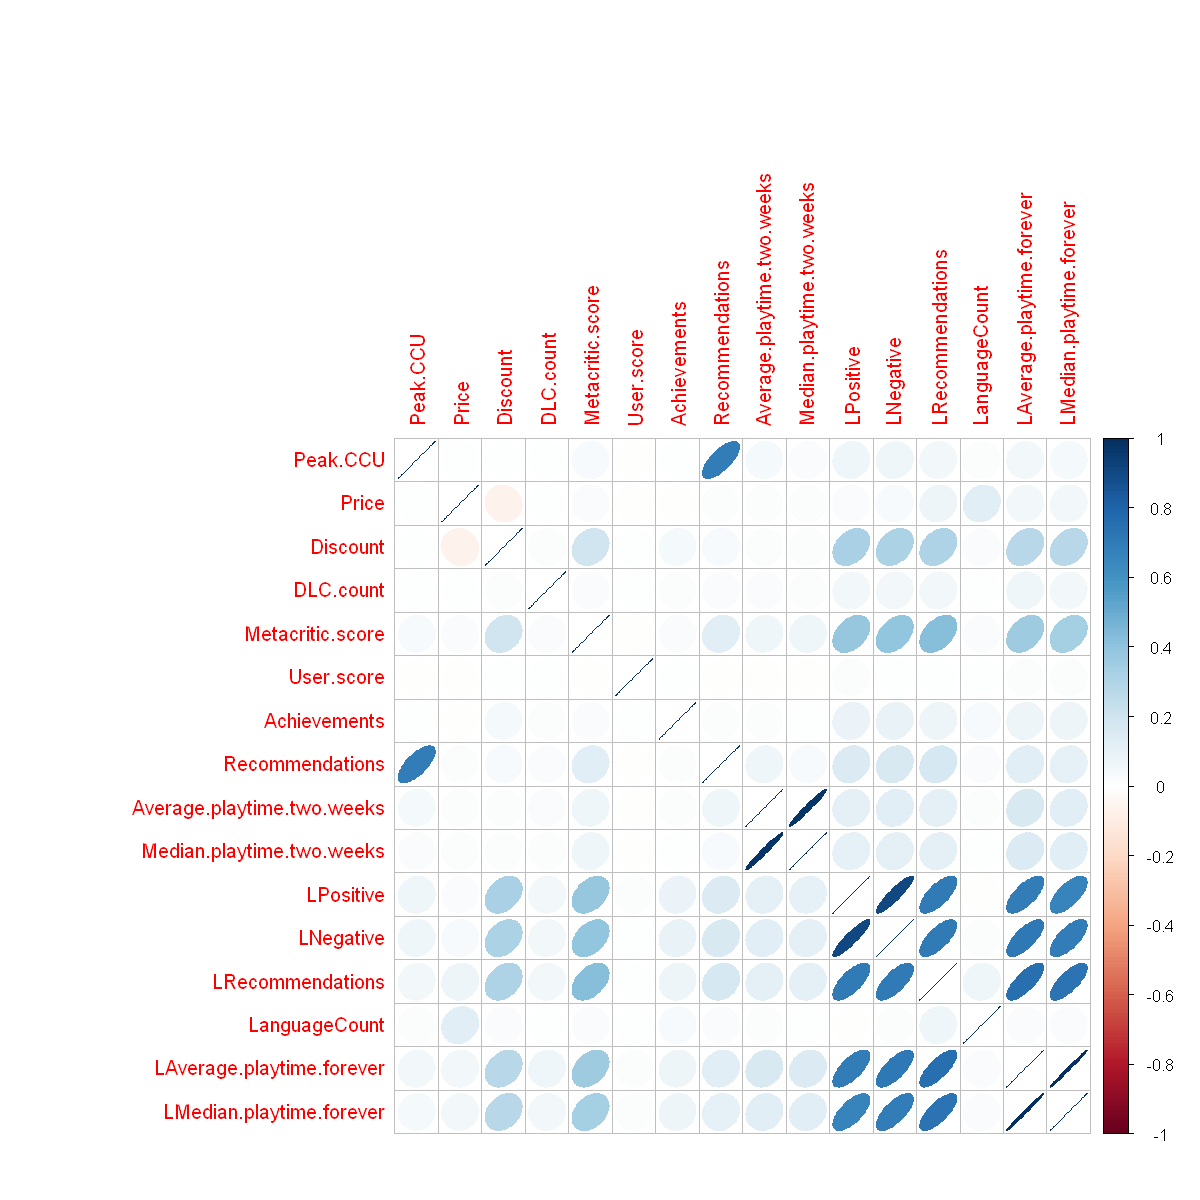

In [174]:
library(corrplot)
options(repr.plot.width = 10, repr.plot.height =10)
corrplot(cor(data_quanti),method="ellipse")

# PCA

In [28]:
library(FactoMineR) 
library(factoextra)


Warning message:
"le package 'FactoMineR' a été compilé avec la version R 4.5.3"


,eigenvalue,percentage of variance,cumulative percentage of variance
comp 1,4.527201430,28.29500893,28.29501
comp 2,1.916551943,11.97844964,40.27346
comp 3,1.659186092,10.36991307,50.64337
comp 4,1.142838406,7.14274004,57.78611
comp 5,1.009533506,6.30958441,64.09570
comp 6,1.000137805,6.25086128,70.34656
comp 7,0.993135477,6.20709673,76.55365
comp 8,0.922912190,5.76820118,82.32186
comp 9,0.801608810,5.01005506,87.33191
comp 10,0.773548901,4.83468063,92.16659


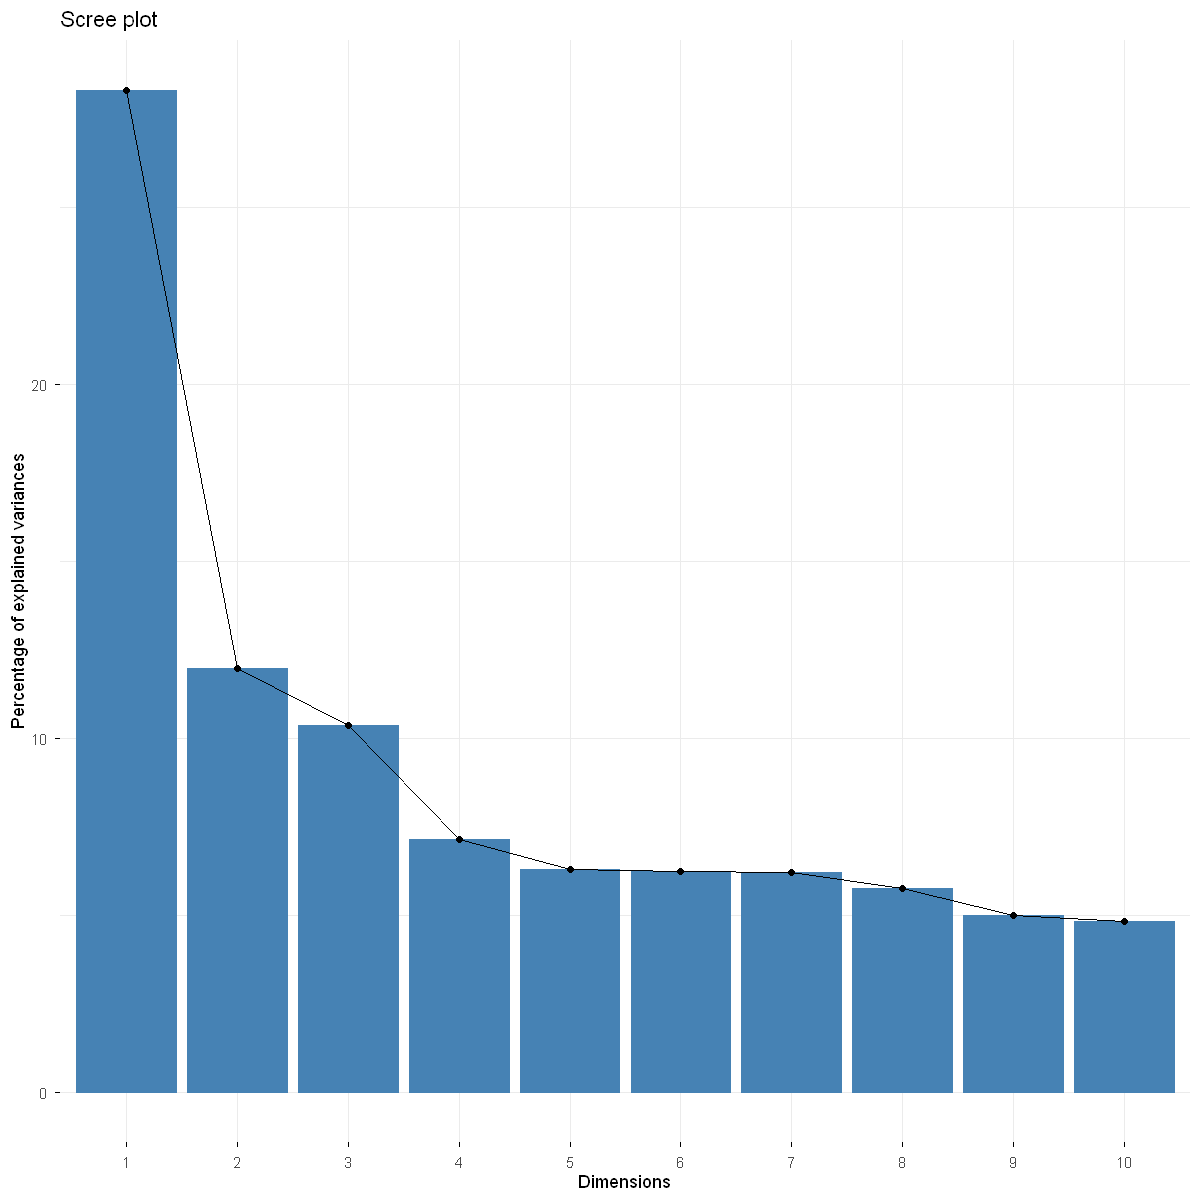

In [30]:


res.pca <- PCA(data_quanti,ncp = ncol(data_quanti), scale.unit = TRUE, graph = FALSE)
fviz_eig(res.pca)
res.pca$eig

**Commentaires**: on va décider d'expliquer au moins 80% de la variance donc on va garder 8 dimensions

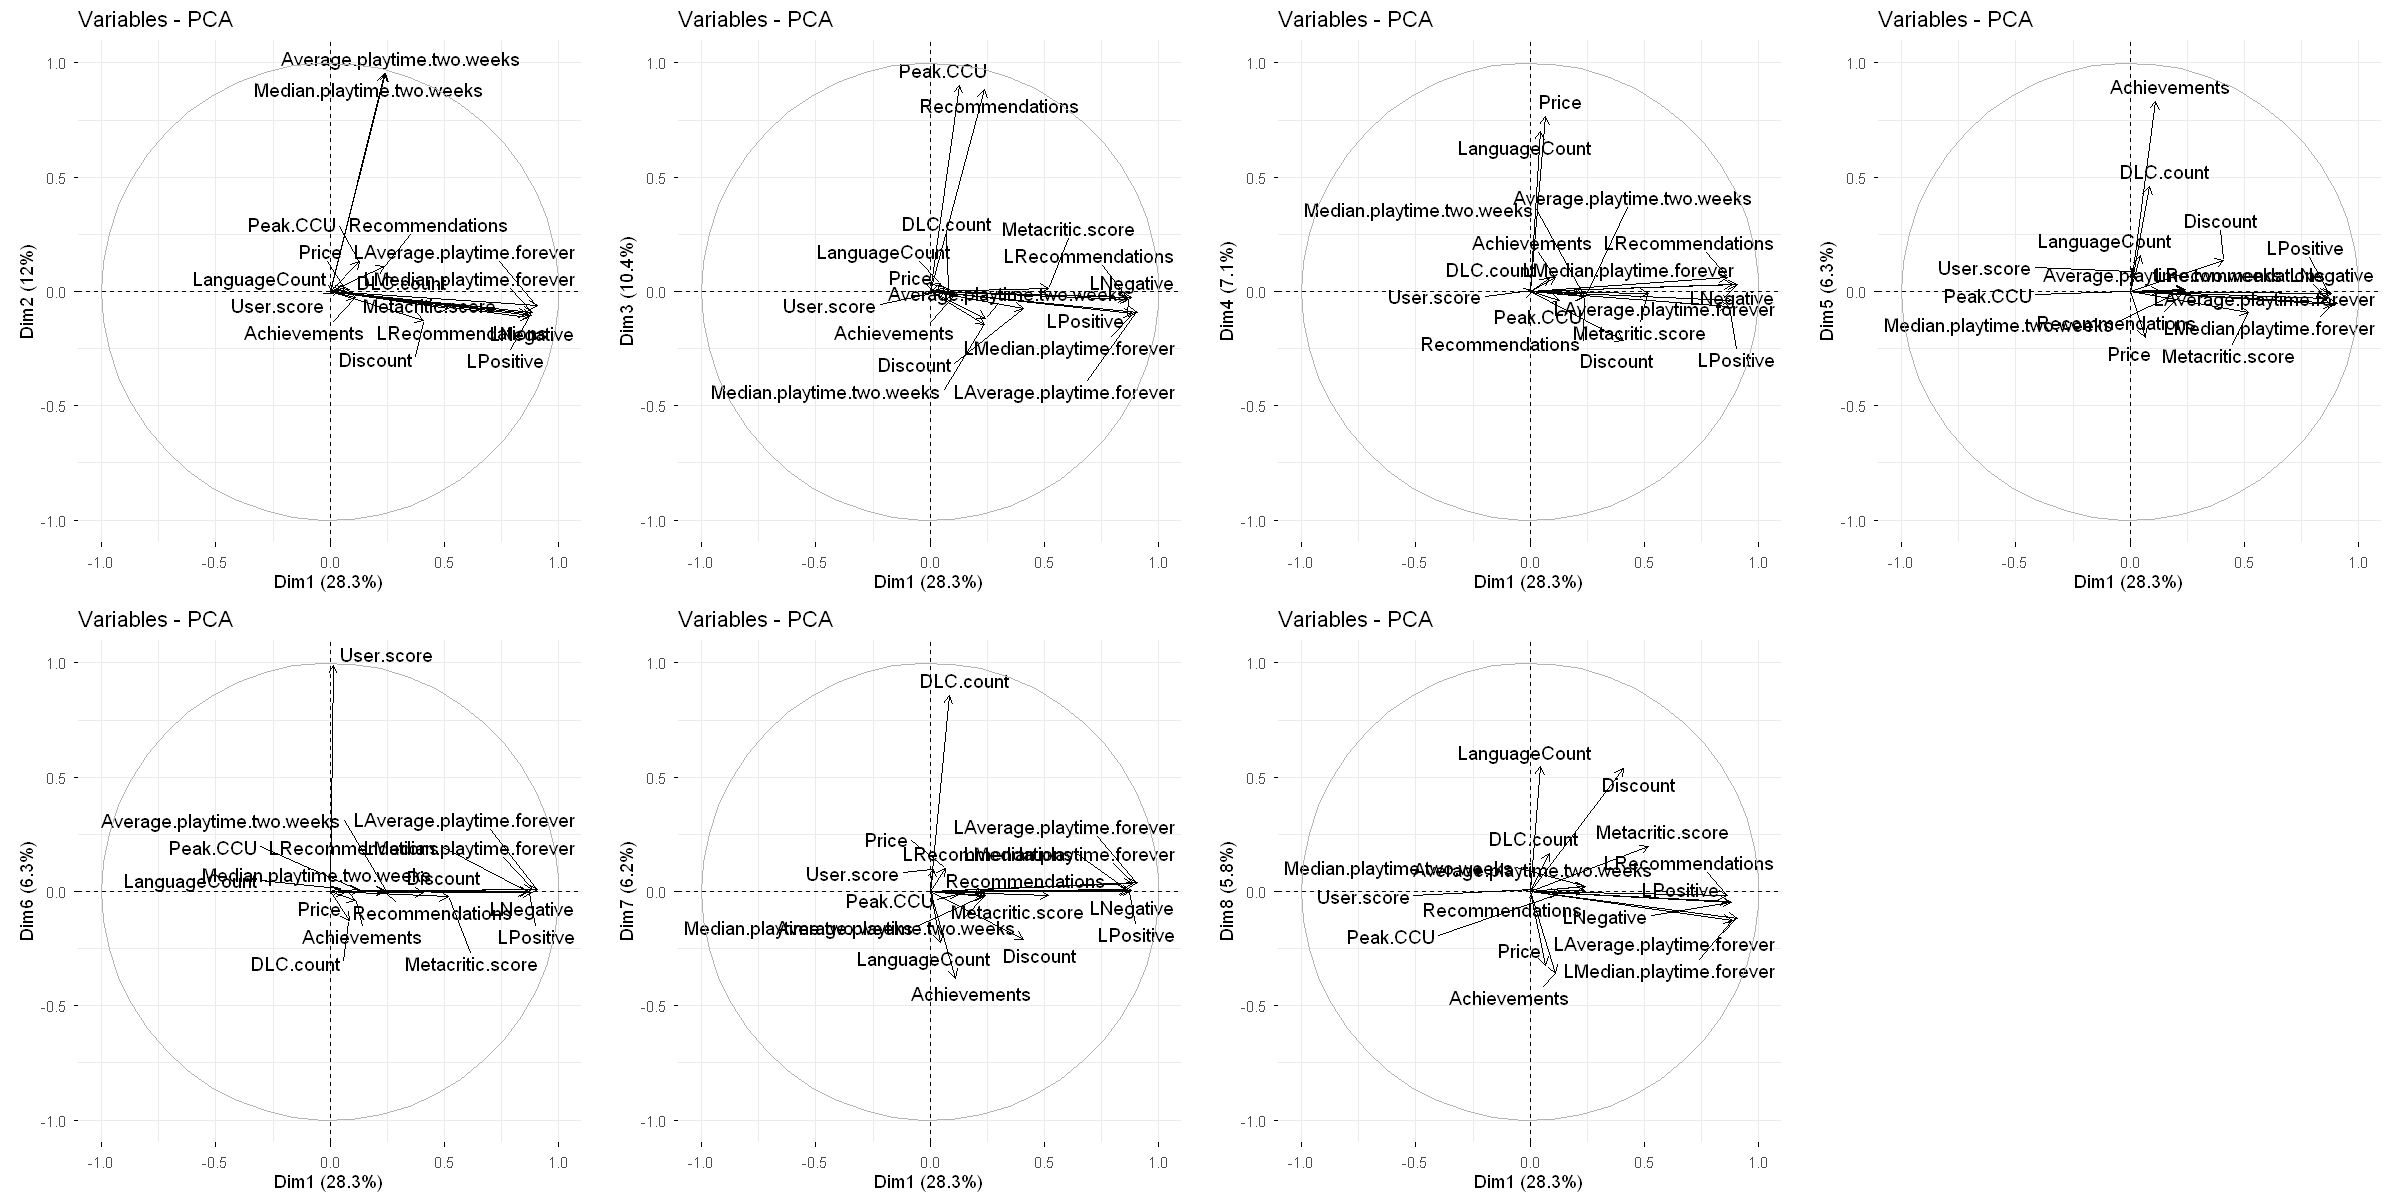

In [31]:
options(repr.plot.width = 20, repr.plot.height = 10)
g1=fviz_pca_var(res.pca,axes = c(1,2),repel=TRUE)
g2=fviz_pca_var(res.pca,axes = c(1,3),repel=TRUE)
g3=fviz_pca_var(res.pca,axes = c(1,4),repel=TRUE)
g4=fviz_pca_var(res.pca,axes = c(1,5),repel=TRUE)
g5=fviz_pca_var(res.pca,axes = c(1,6),repel=TRUE)
g6=fviz_pca_var(res.pca,axes = c(1,7),repel=TRUE)
g7=fviz_pca_var(res.pca,axes = c(1,8),repel=TRUE)
grid.arrange(g1,g2,g3,g4,g5,g6,g7,ncol=4)

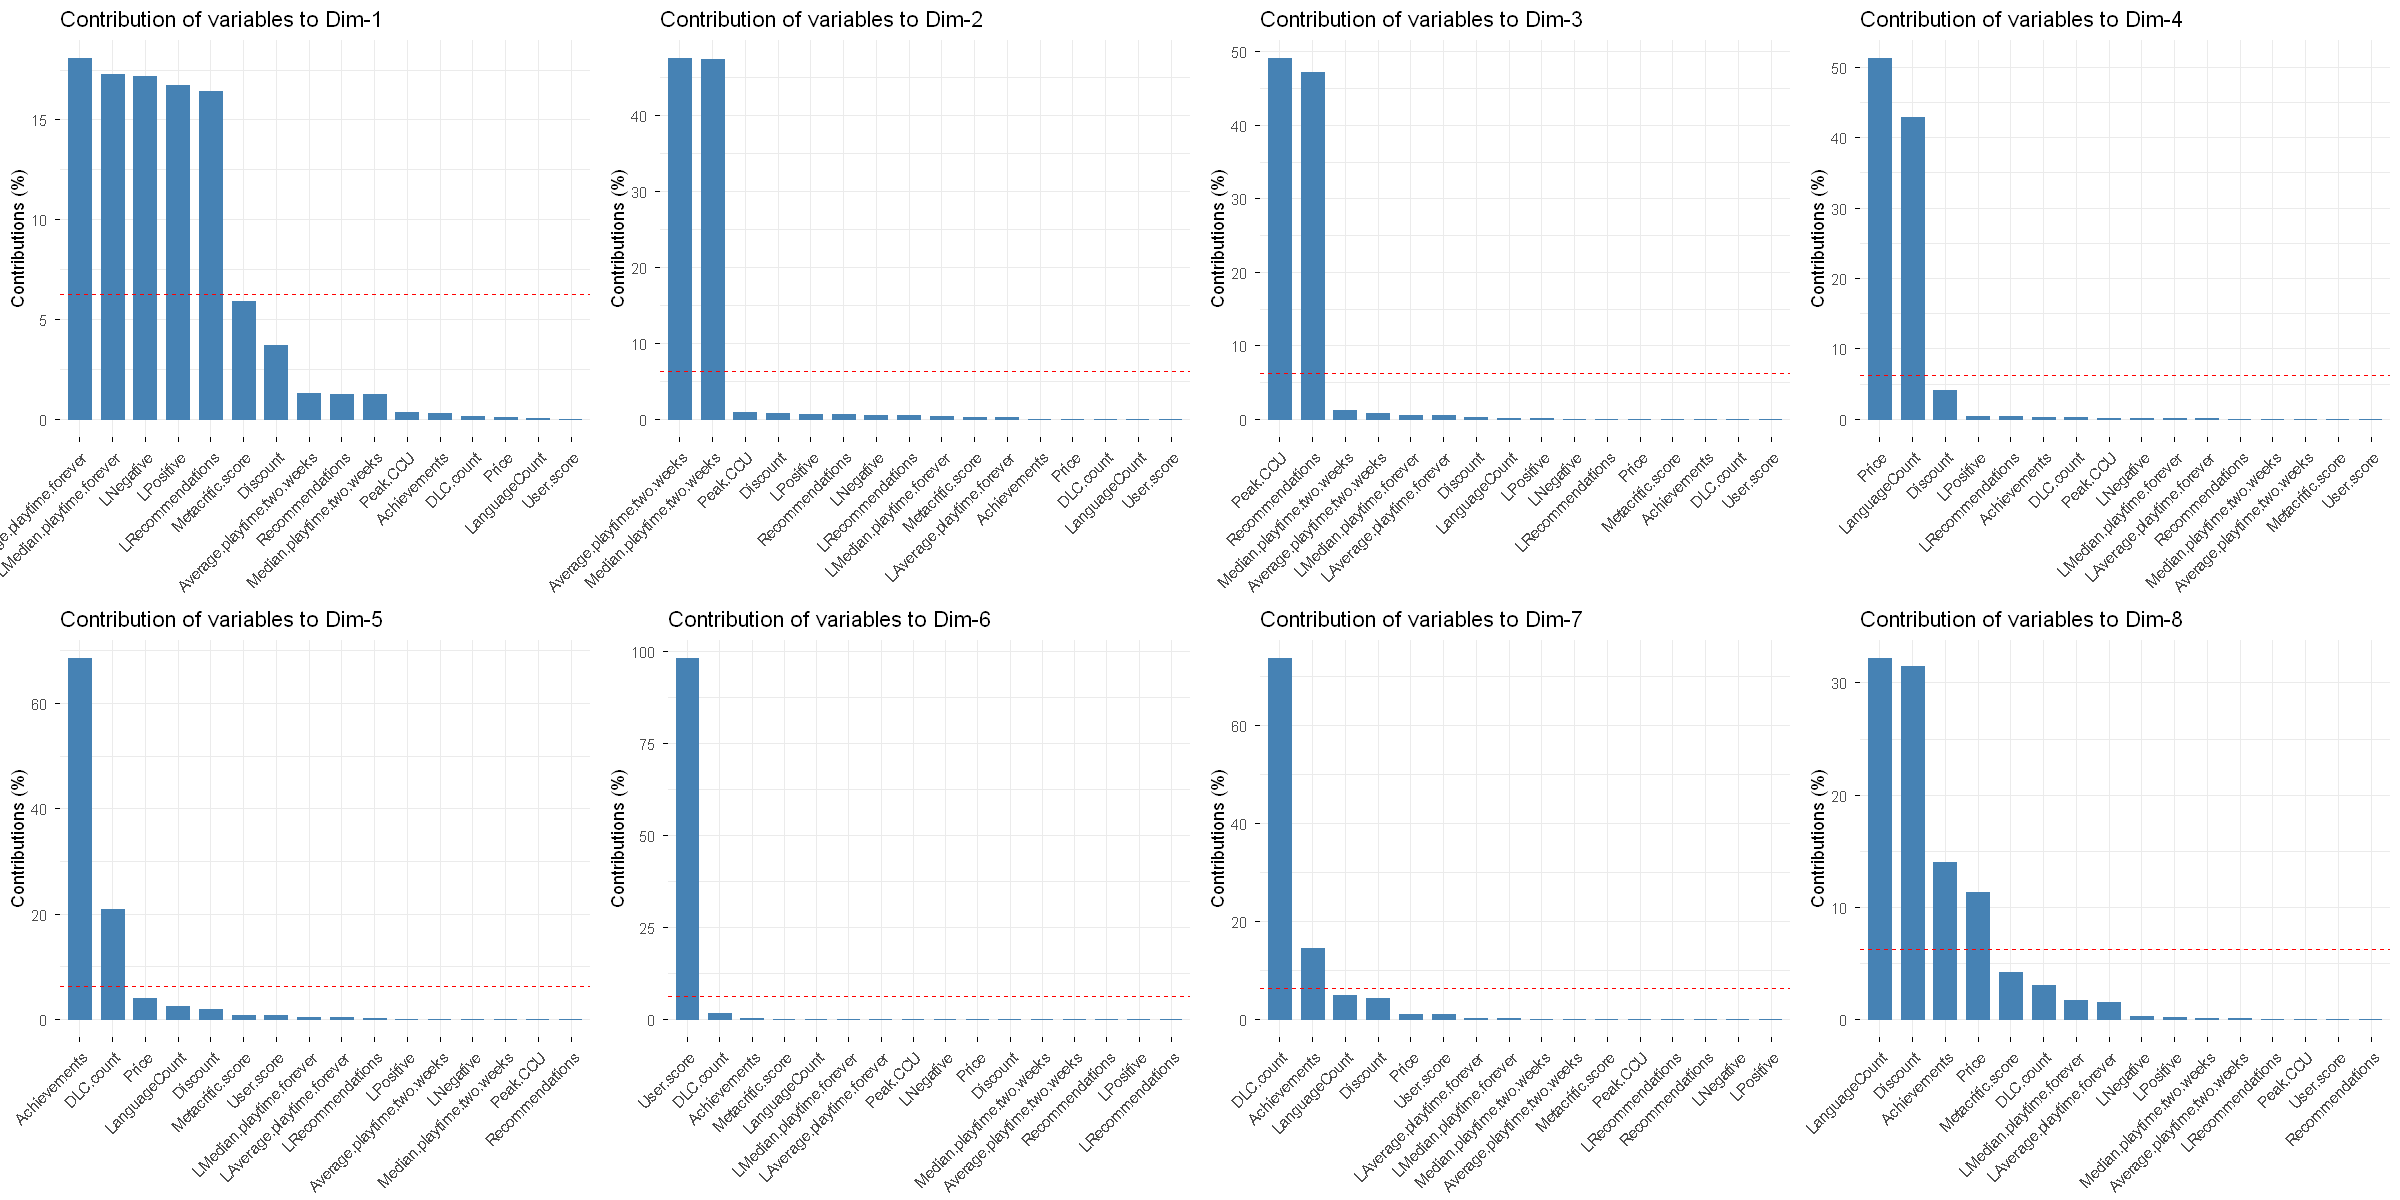

In [33]:
c1<-fviz_contrib(res.pca, choice = "var", axes = 1)
c2<-fviz_contrib(res.pca, choice = "var", axes = 2) 
c3<-fviz_contrib(res.pca, choice = "var", axes = 3)
c4<-fviz_contrib(res.pca, choice = "var", axes = 4) 
c5<-fviz_contrib(res.pca, choice = "var", axes = 5) 
c6<-fviz_contrib(res.pca, choice = "var", axes = 6)
c7<-fviz_contrib(res.pca, choice = "var", axes = 7) 
c8<-fviz_contrib(res.pca, choice = "var", axes = 8) 
grid.arrange(c1,c2,c3,c4,c5,c6,c7,c8,ncol=4)

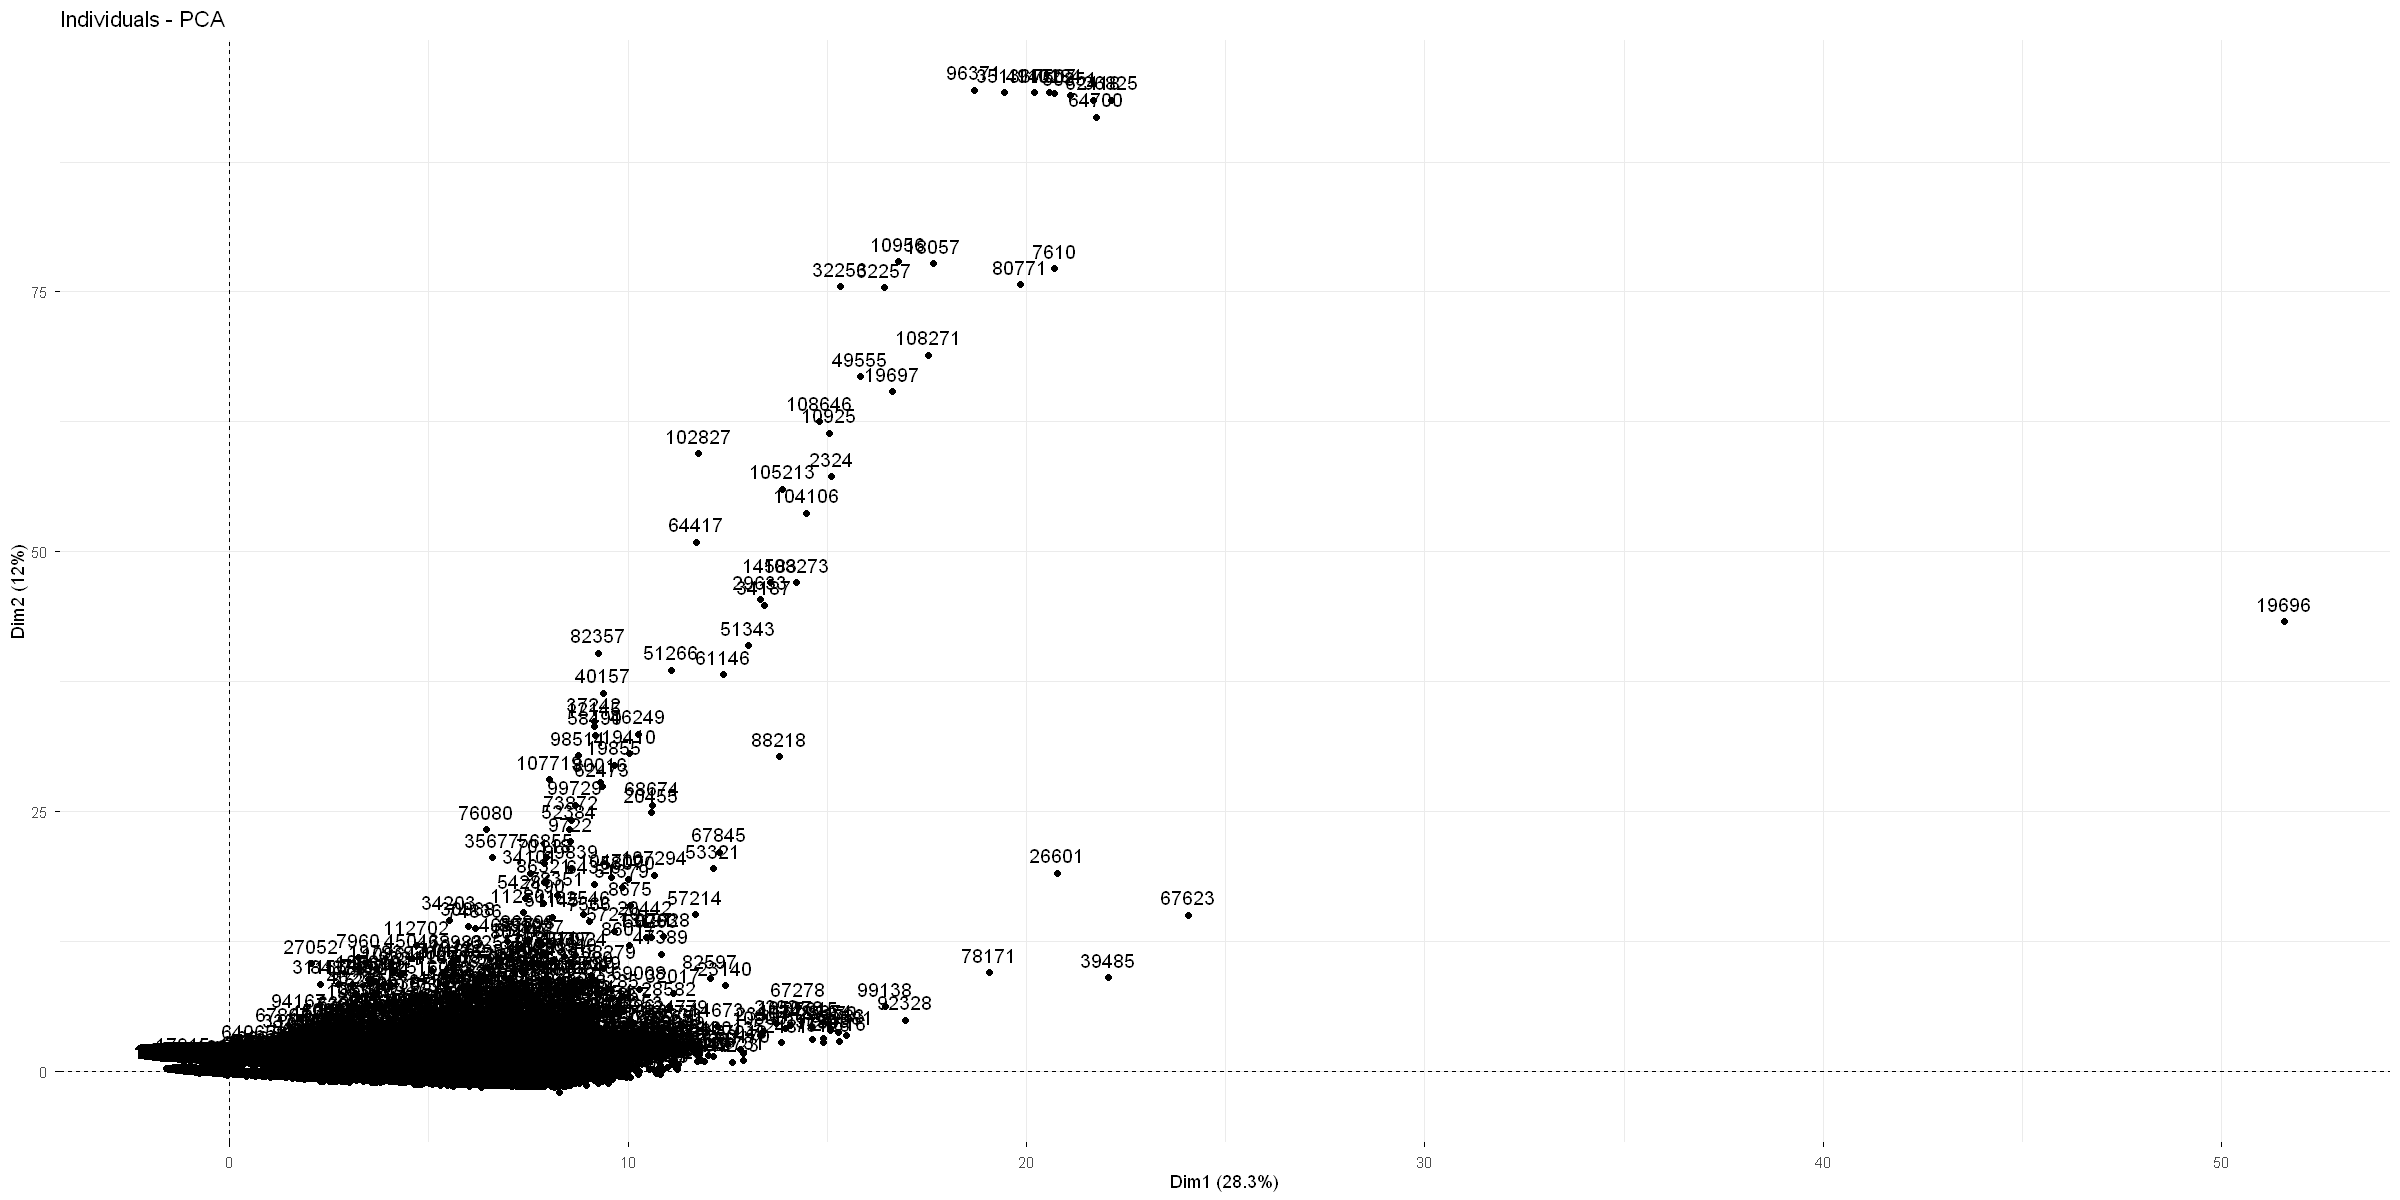

In [34]:
i1=fviz_pca_ind(res.pca,axes = c(1,2),repel=FALSE)
i1

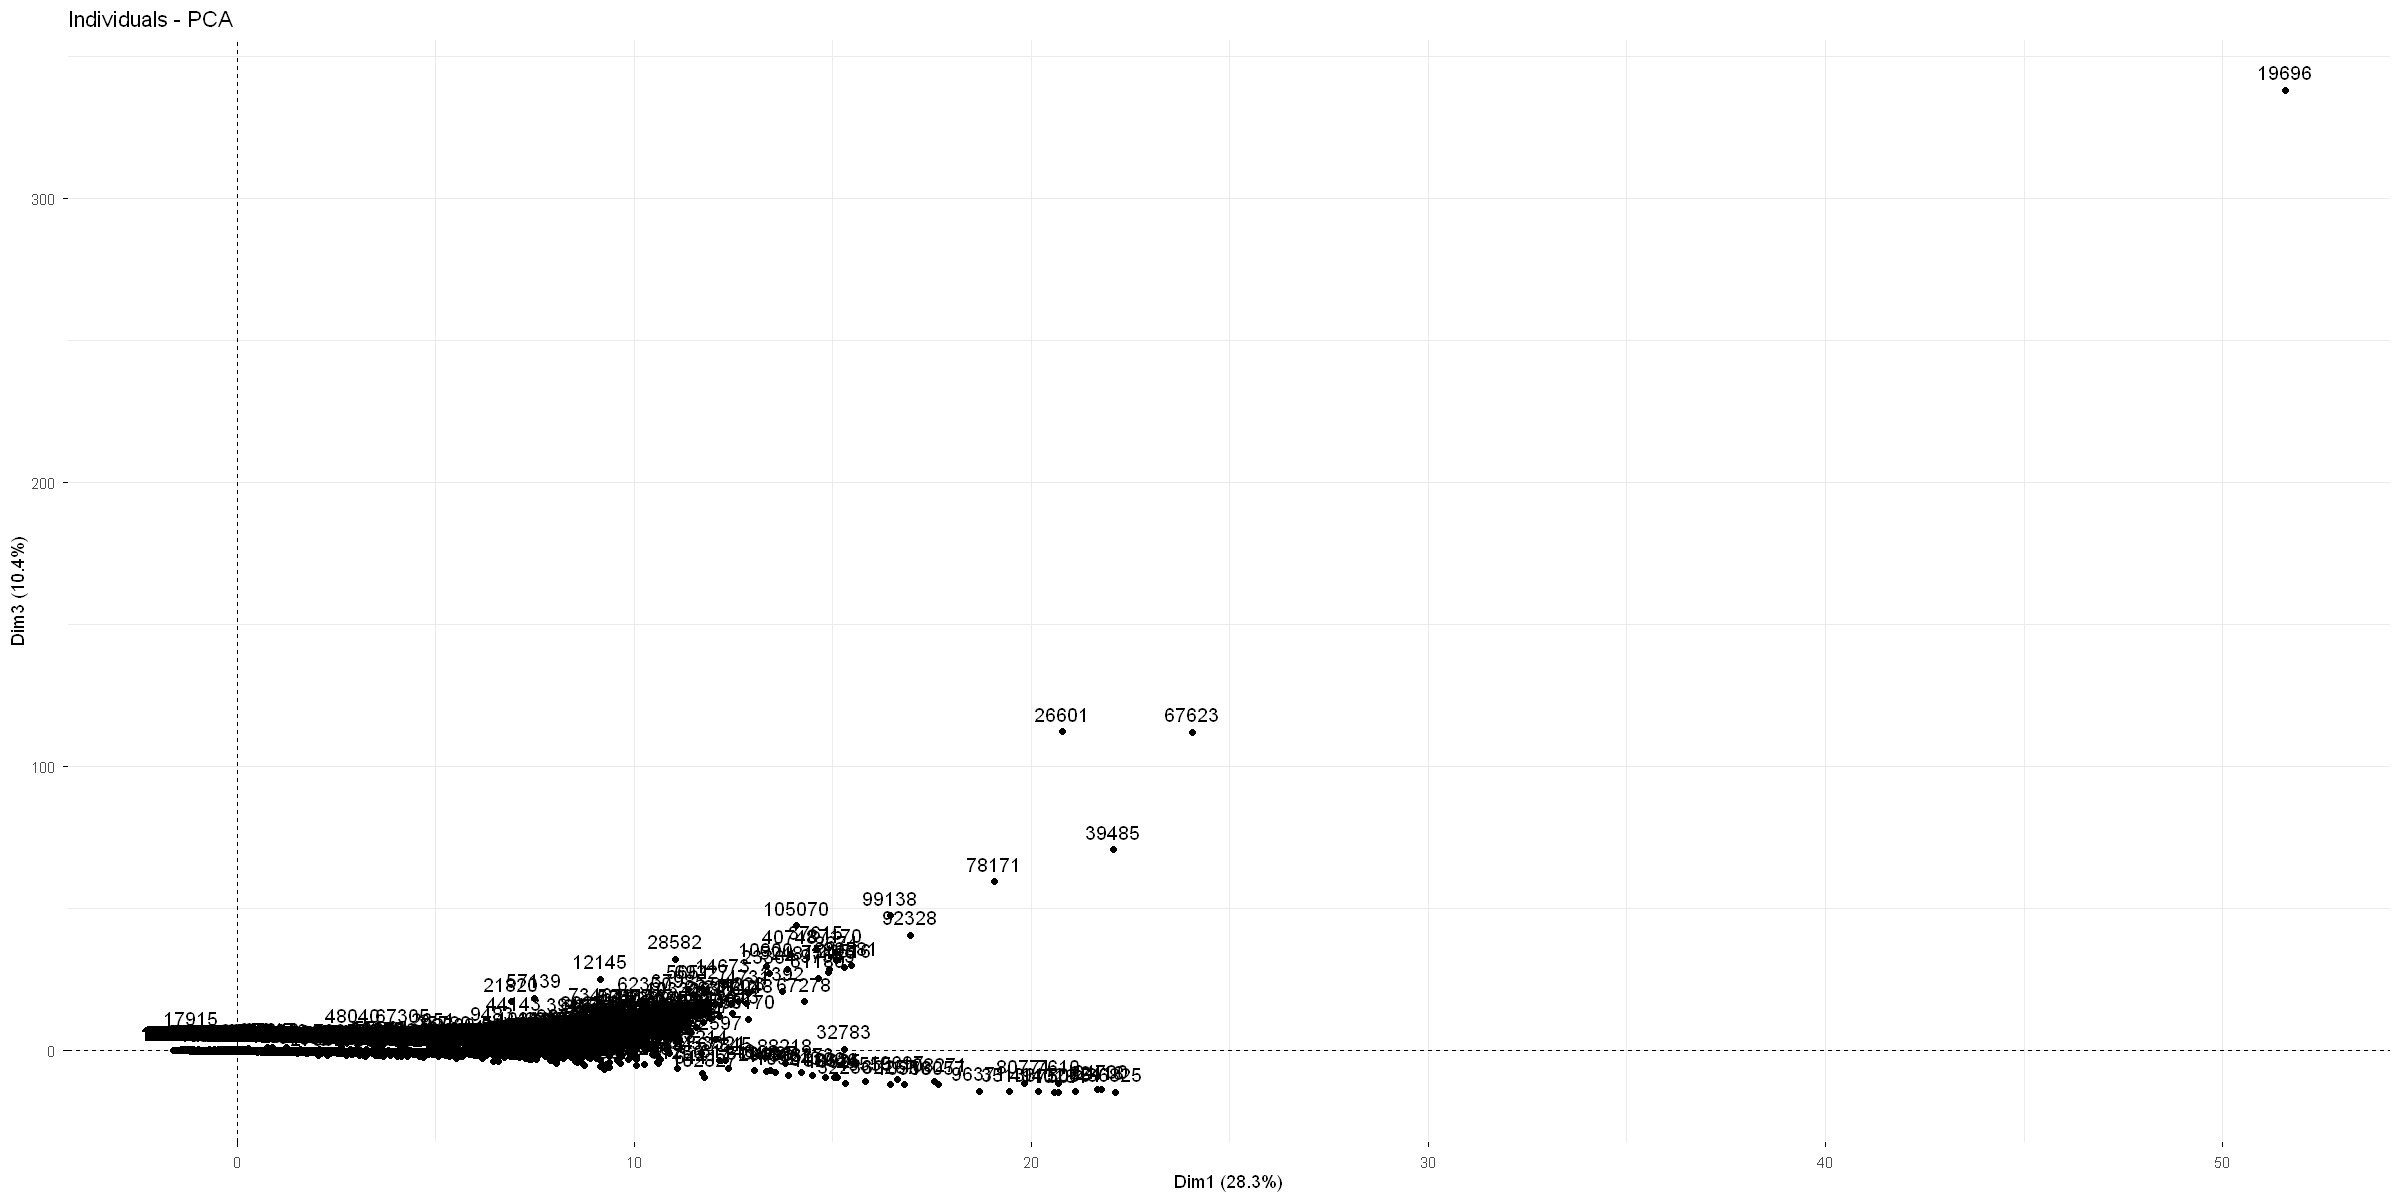

In [35]:
i2=fviz_pca_ind(res.pca,axes = c(1,3),repel=FALSE)
i2

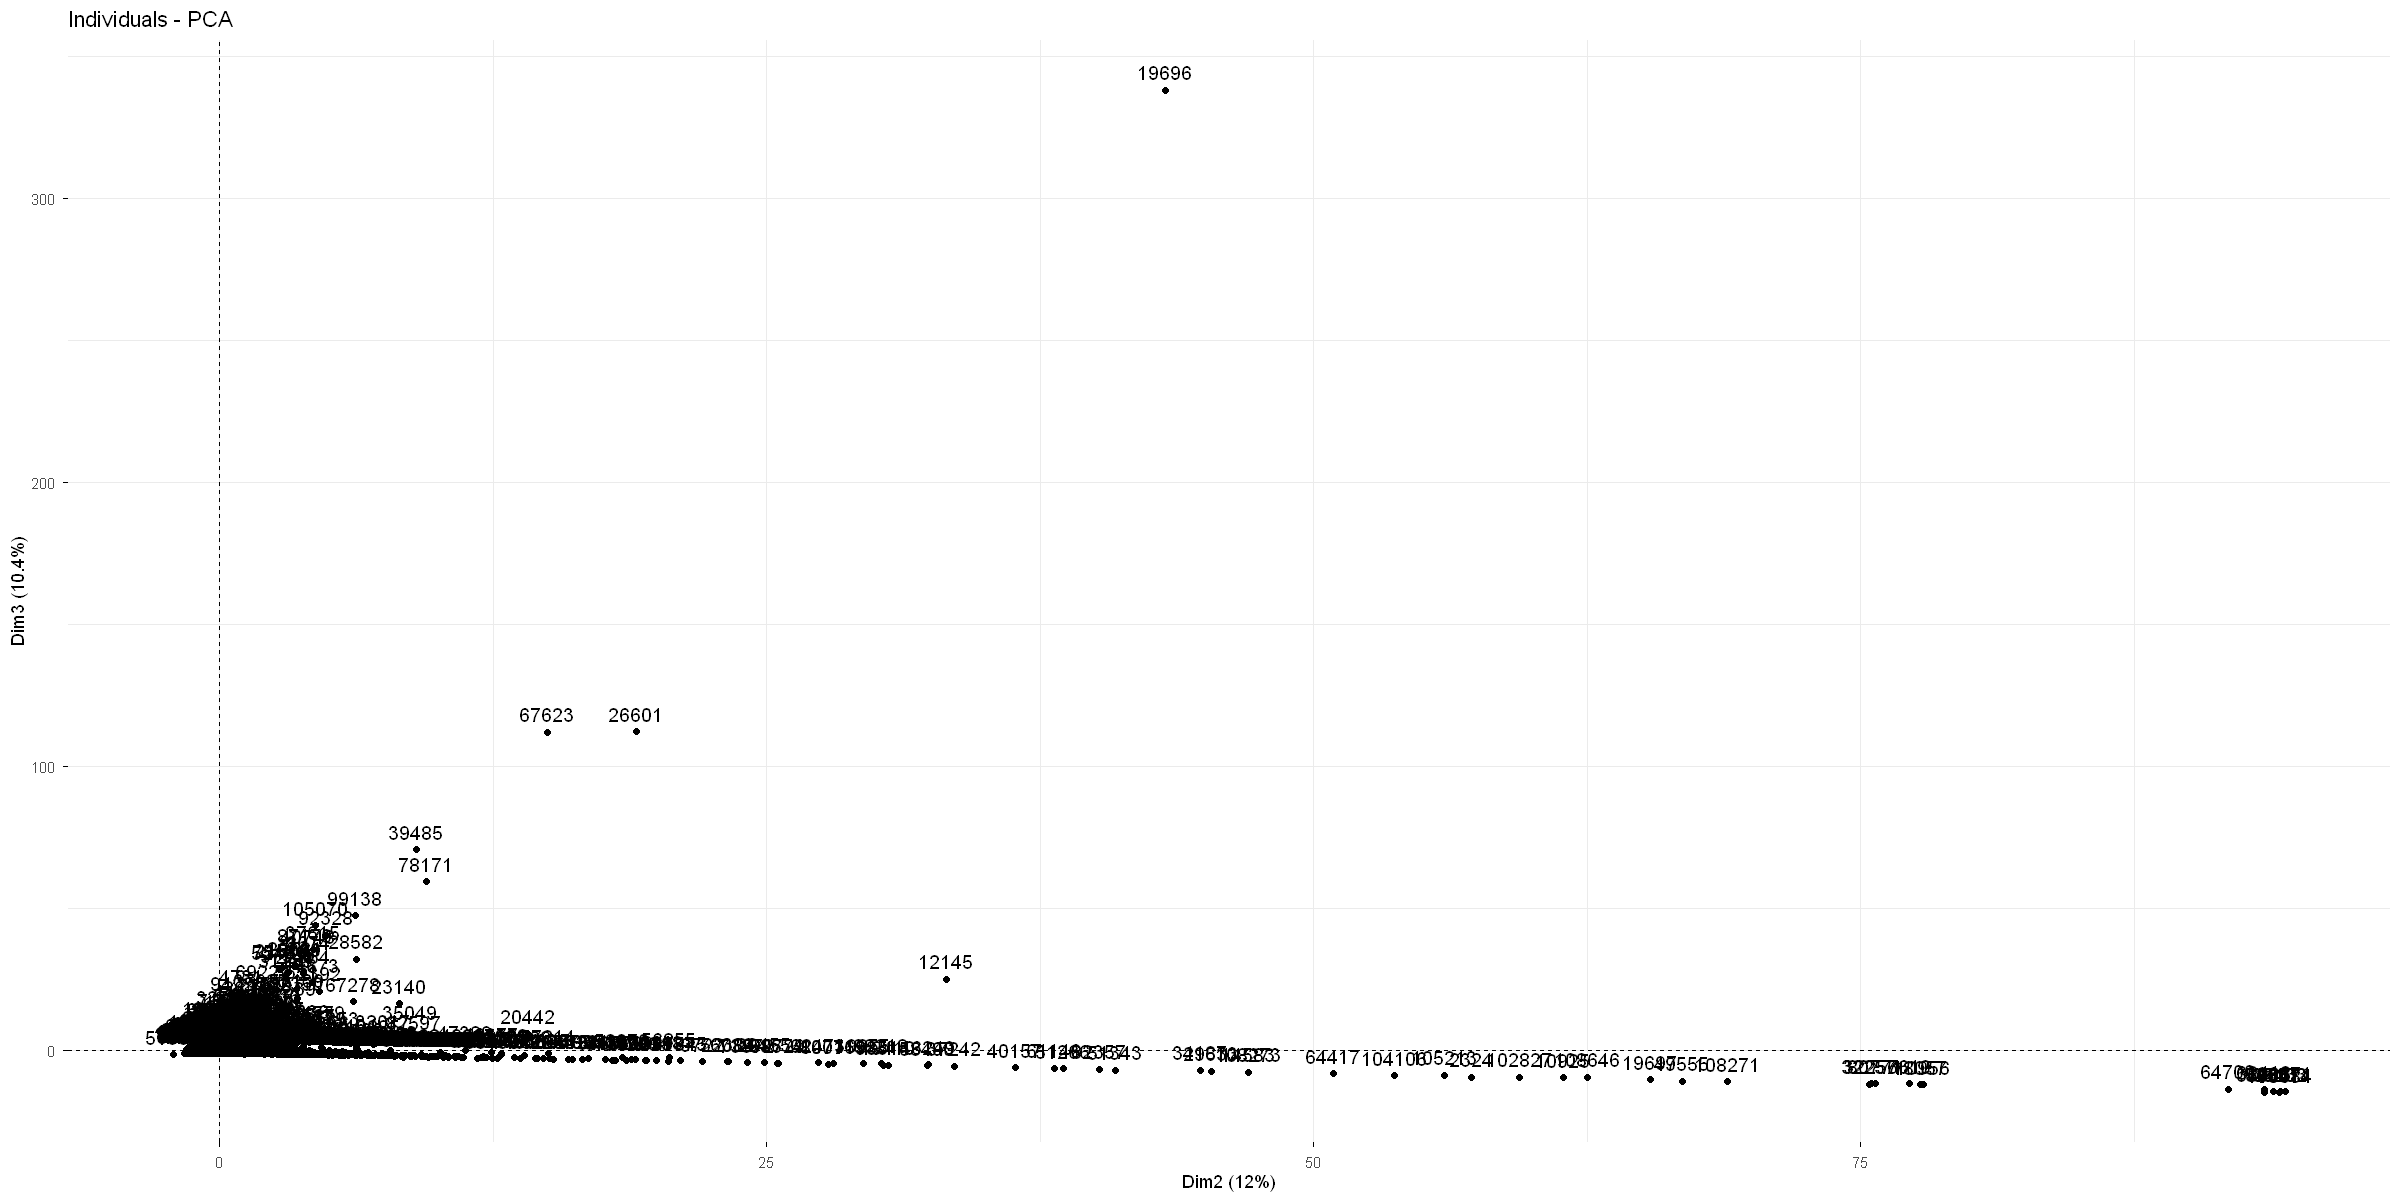

In [36]:
i3=fviz_pca_ind(res.pca,axes = c(2,3),repel=FALSE)
i3

On remarque un outlier l'individu: 19696, 67623, 26601, 12145, 39485

In [37]:
data_ready[c('19696',"67623","26601","12145","39485"),]


,Name,Release.date,Estimated.owners,Peak.CCU,Required.age,Price,Discount,DLC.count,Windows,Mac,⋯,Publishers,Categories,Language,TagGenre,LPositive,LNegative,LRecommendations,LanguageCount,LAverage.playtime.forever,LMedian.playtime.forever
,<chr>,<chr>,<fct>,<int>,<fct>,<dbl>,<int>,<int>,<fct>,<fct>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
19696,Counter-Strike 2,"Aug 21, 2012",100M-200M,1013936,0,0,0,1,True,False,⋯,Valve,"Multi-player,Cross-Platform Multiplayer,Steam Trading Cards,Steam Workshop,In-App Purchases,Adjustable Text Size,Camera Comfort,Color Alternatives,Custom Volume Controls,Playable without Timed Input,Stereo Sound,Surround Sound,Valve Anti-Cheat enabled,Stats,Remote Play on Phone,Remote Play on Tablet,Remote Play on TV,Steam Timeline","Czech, Danish, Dutch, English, Finnish, French, German, Hungarian, Italian, Japanese, Korean, Norwegian, Polish, Portuguese-Portugal, Portuguese-Brazil, Romanian, Russian, SimplifiedChinese, Spanish-Spain, Swedish, Thai, TraditiolChinese, Turkish, Bulgarian, Ukrainian, Greek, Spanish-Latimerica, Vietmese, Indonesian","Action, FreeToPlay, FPS, Shooter, Multiplayer, Competitive, Team-Based, e-sports, Tactical, First-Person, PvP, OnlineCo-Op, Co-op, Strategy, Military, War, Difficult, Trading, Realistic, Fast-Paced, Moddable",15.84918,13.97508,15.390451,29,10.431377,8.738415
67623,PUBG: BATTLEGROUNDS,"Dec 21, 2017",100M-200M,314682,13,0,0,0,True,False,⋯,"KRAFTON, Inc.","Multi-player,PvP,Online PvP,Stats,Remote Play on Phone,Remote Play on Tablet","English, Korean, SimplifiedChinese, French, German, Spanish-Spain, Arabic, Japanese, Polish, Portuguese-Portugal, Russian, Turkish, Thai, Italian, Portuguese-Brazil, TraditiolChinese, Ukrainian","Action, Adventure, MassivelyMultiplayer, FreeToPlay, Survival, Shooter, BattleRoyale, Multiplayer, FPS, PvP, Third-PersonShooter, OnlineCo-Op, Tactical, Co-op, First-Person, Strategy, EarlyAccess, Competitive, ThirdPerson, Team-Based, Difficult, Simulation, Stealth",14.23452,13.85231,14.376989,17,10.076937,8.713253
26601,Dota 2,"Jul 9, 2013",100M-200M,623941,0,0,0,2,True,True,⋯,Valve,"Multi-player,Co-op,Steam Trading Cards,Steam Workshop,SteamVR Collectibles,In-App Purchases,Camera Comfort,Color Alternatives,Custom Volume Controls,Valve Anti-Cheat enabled,Steam Timeline","Bulgarian, Czech, Danish, Dutch, English, Finnish, French, German, Greek, Hungarian, Italian, Japanese, Korean, Norwegian, Polish, Portuguese-Portugal, Portuguese-Brazil, Romanian, Russian, SimplifiedChinese, Spanish-Spain, Swedish, Thai, TraditiolChinese, Turkish, Ukrainian, Spanish-Latimerica, Vietmese","Action, Strategy, FreeToPlay, FreetoPlay, MOBA, Multiplayer, e-sports, Team-Based, Competitive, OnlineCo-Op, PvP, Difficult, Co-op, RTS, RPG, TowerDefense, Fantasy, CharacterCustomization, ReplayValue, ActionRPG, Simulation",14.52706,13.04295,9.572898,28,10.897942,7.052721
12145,Bongo Cat,"Mar 5, 2025",0-20K,164168,0,0,0,0,True,False,⋯,Irox Games,"Single-player,Multi-player,Co-op,Online Co-op,Steam Achievements,Partial Controller Support,Stats","English, German, Dutch, Japanese, Korean, Polish, Portuguese-Brazil, Portuguese-Portugal, Russian, SimplifiedChinese, TraditiolChinese, Ukrainian, French, Italian, Spanish-Spain, Arabic, Czech, Danish, Finnish, Norwegian, Romanian, Spanish-Latimerica, Swedish, Turkish","Casual, Indie, MassivelyMultiplayer, Simulation, FreeToPlay",0.00000,0.00000,0.000000,24,10.416611,7.707962
39485,Grand Theft Auto V Legacy,"Apr 13, 2015",50M-100M,67851,17,0,0,0,True,False,⋯,Rockstar Games,"Single-player,Multi-player,PvP,Online PvP,Co-op,Online Co-op,Steam Achievements,Full controller support,Remote Play on Phone,Remote Play on Tablet,Remote Play on TV","English, French, Italian, German, Spanish-Spain, Korean, Polish, Portuguese-Brazil, Russian, TraditiolChinese, Japanese, SimplifiedChinese, Spanish-Latimerica","Action, Adventure, OpenWorld, Multiplayer, Crime, AutomobileSim, ThirdPerson, First-Person, Mature, Shooter, Singleplayer, 

# Variables qualitatives

In [175]:
data_quali=data_ready %>%
  select(where(is.factor)) 

In [176]:
summary(data_quali)

    Release.date    Estimated.owners  Required.age     Windows      
 2025-2026:21812   0-20K    :75337   0      :113288   False:    44  
 2024     :18104   0        :13649   17     :   782   True :114469  
 2023     :13337   20K-50K  :11395   13     :   175                 
 2022     :11403   50K-100K : 5349   18     :   164                 
 2021     :10441   100K-200K: 3450   16     :    31                 
 2020     : 8746   200K-500K: 2845   10     :    26                 
 (Other)  :30670   (Other)  : 2488   (Other):    47                 
    Mac          Linux      
 False:93260   False:98841  
 True :21253   True :15672  
                            
                            
                            
                            
                            

## MCA

In [153]:
res.mca=MCA(data_quali)
print(res.mca)

**Results of the Multiple Correspondence Analysis (MCA)**
The analysis was performed on 114513 individuals, described by 6 variables
*The results are available in the following objects:

   name              description                       
1  "$eig"            "eigenvalues"                     
2  "$var"            "results for the variables"       
3  "$var$coord"      "coord. of the categories"        
4  "$var$cos2"       "cos2 for the categories"         
5  "$var$contrib"    "contributions of the categories" 
6  "$var$v.test"     "v-test for the categories"       
7  "$var$eta2"       "coord. of variables"             
8  "$ind"            "results for the individuals"     
9  "$ind$coord"      "coord. for the individuals"      
10 "$ind$cos2"       "cos2 for the individuals"        
11 "$ind$contrib"    "contributions of the individuals"
12 "$call"           "intermediate results"            
13 "$call$marge.col" "weights of columns"              
14 "$call$marge.li"  "weights

,eigenvalue,percentage of variance,cumulative percentage of variance
dim 1,0.2944532,4.206474,4.206474
dim 2,0.2396430,3.423472,7.629946
dim 3,0.2206434,3.152049,10.781994
dim 4,0.1868985,2.669978,13.451972
dim 5,0.1769492,2.527846,15.979818
dim 6,0.1757704,2.511006,18.490824


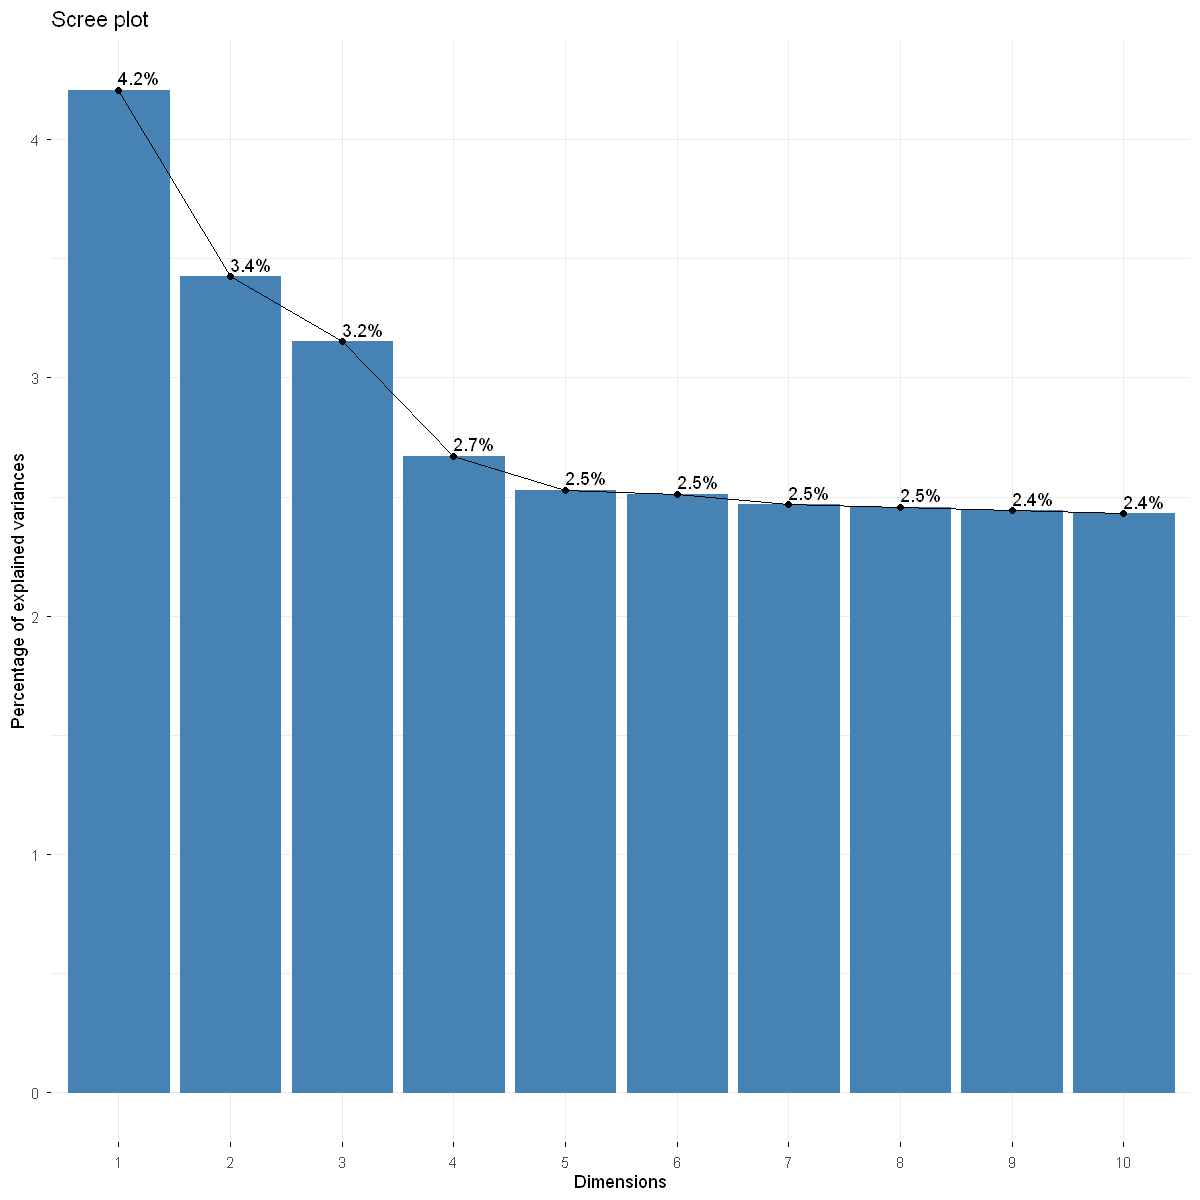

In [154]:
head(res.mca$eig)

fviz_screeplot(res.mca, addlabels=TRUE)



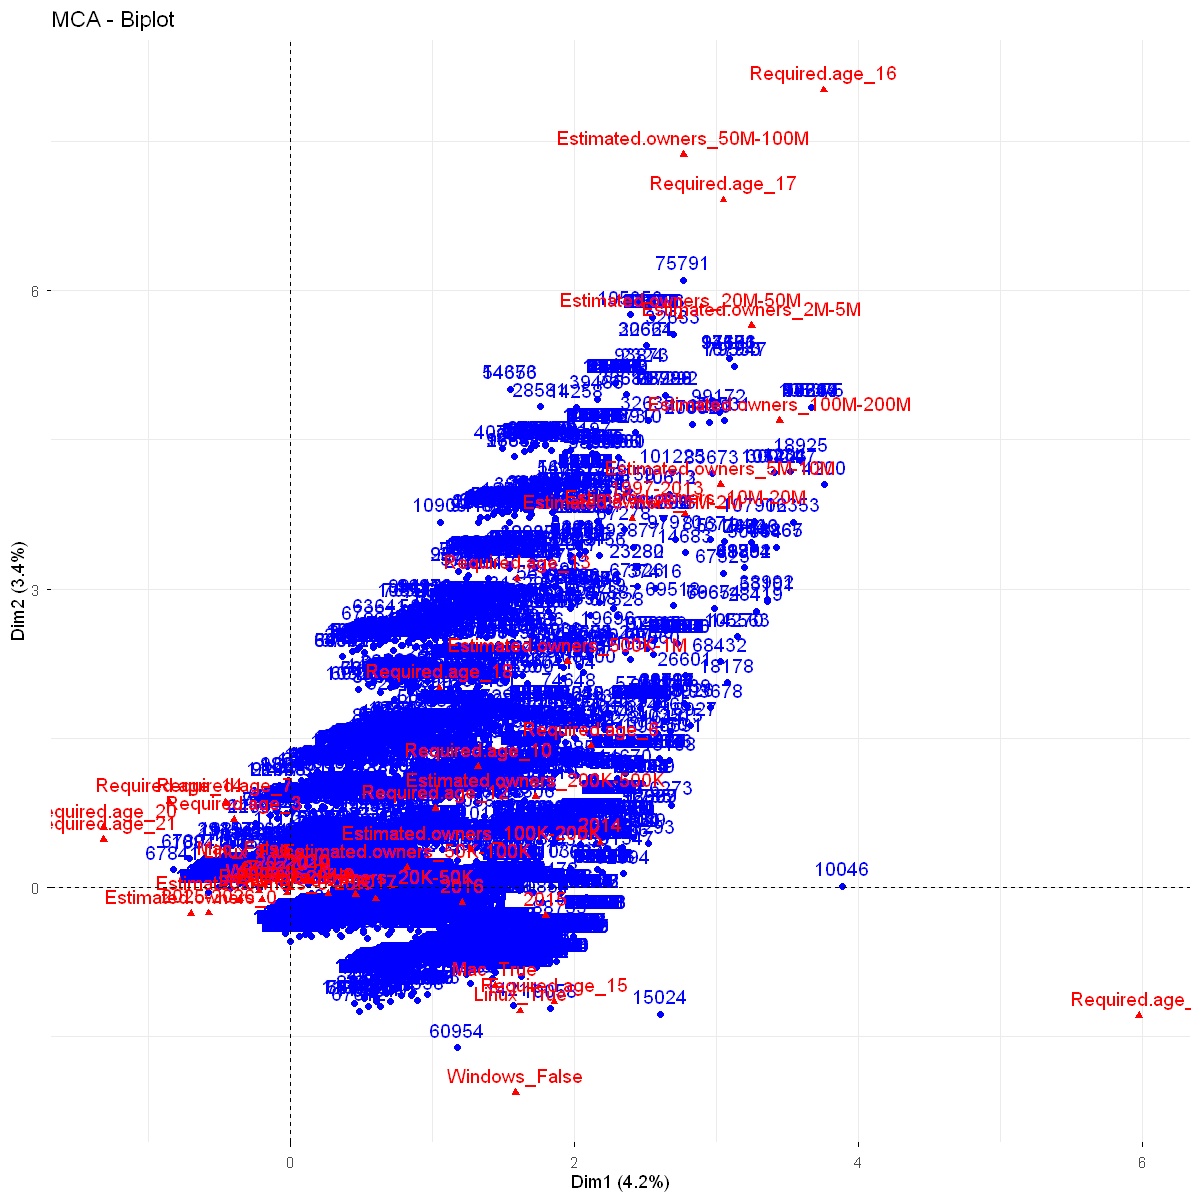

In [155]:
fviz_mca_biplot(res.mca)

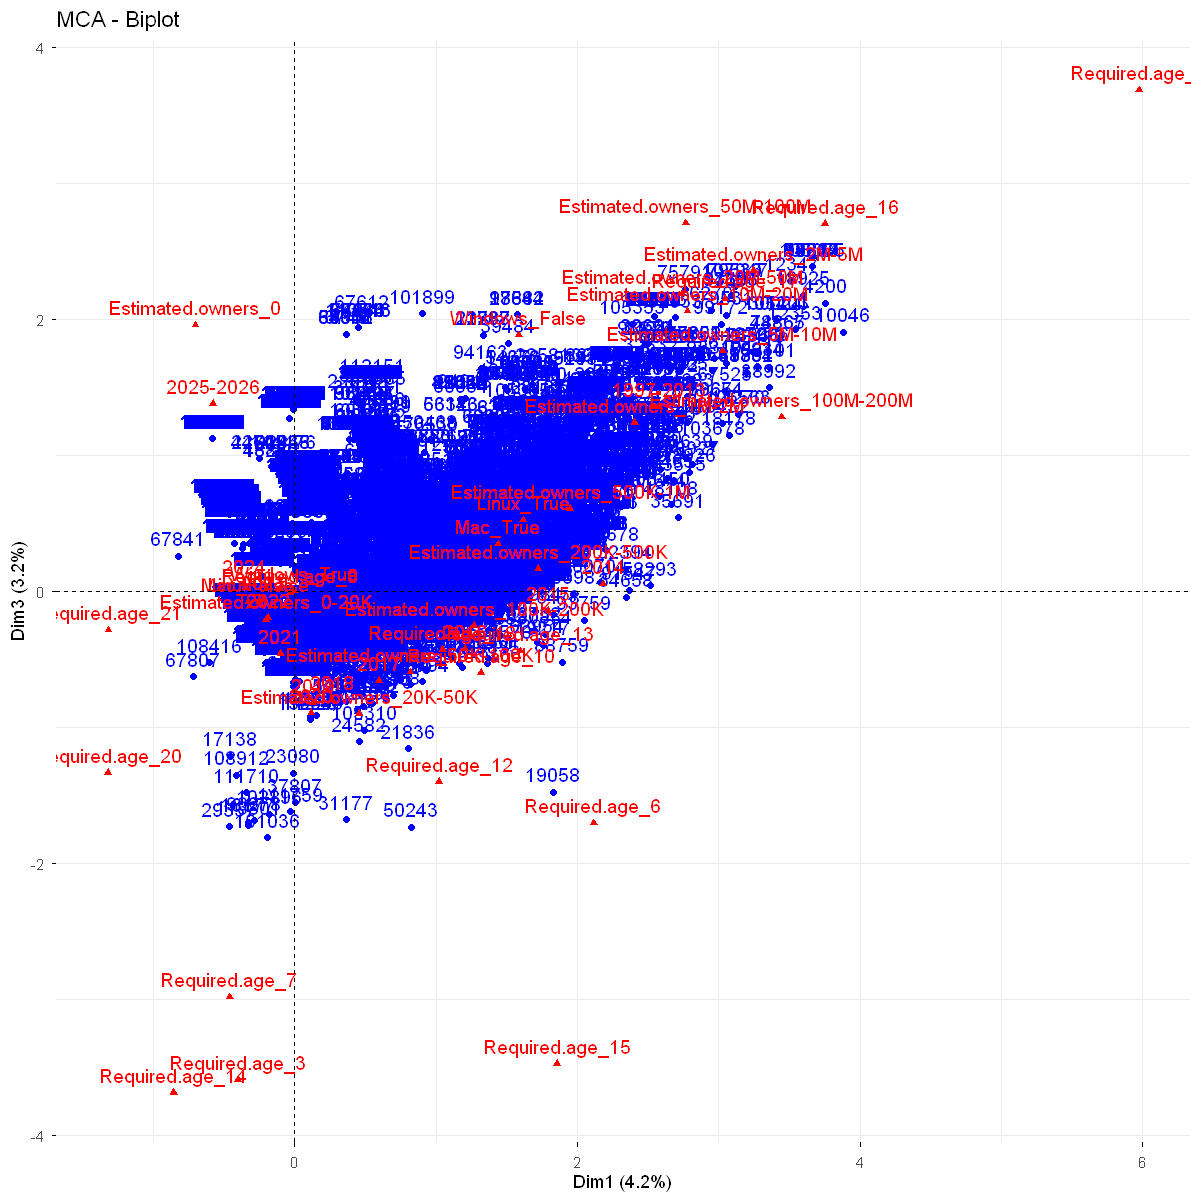

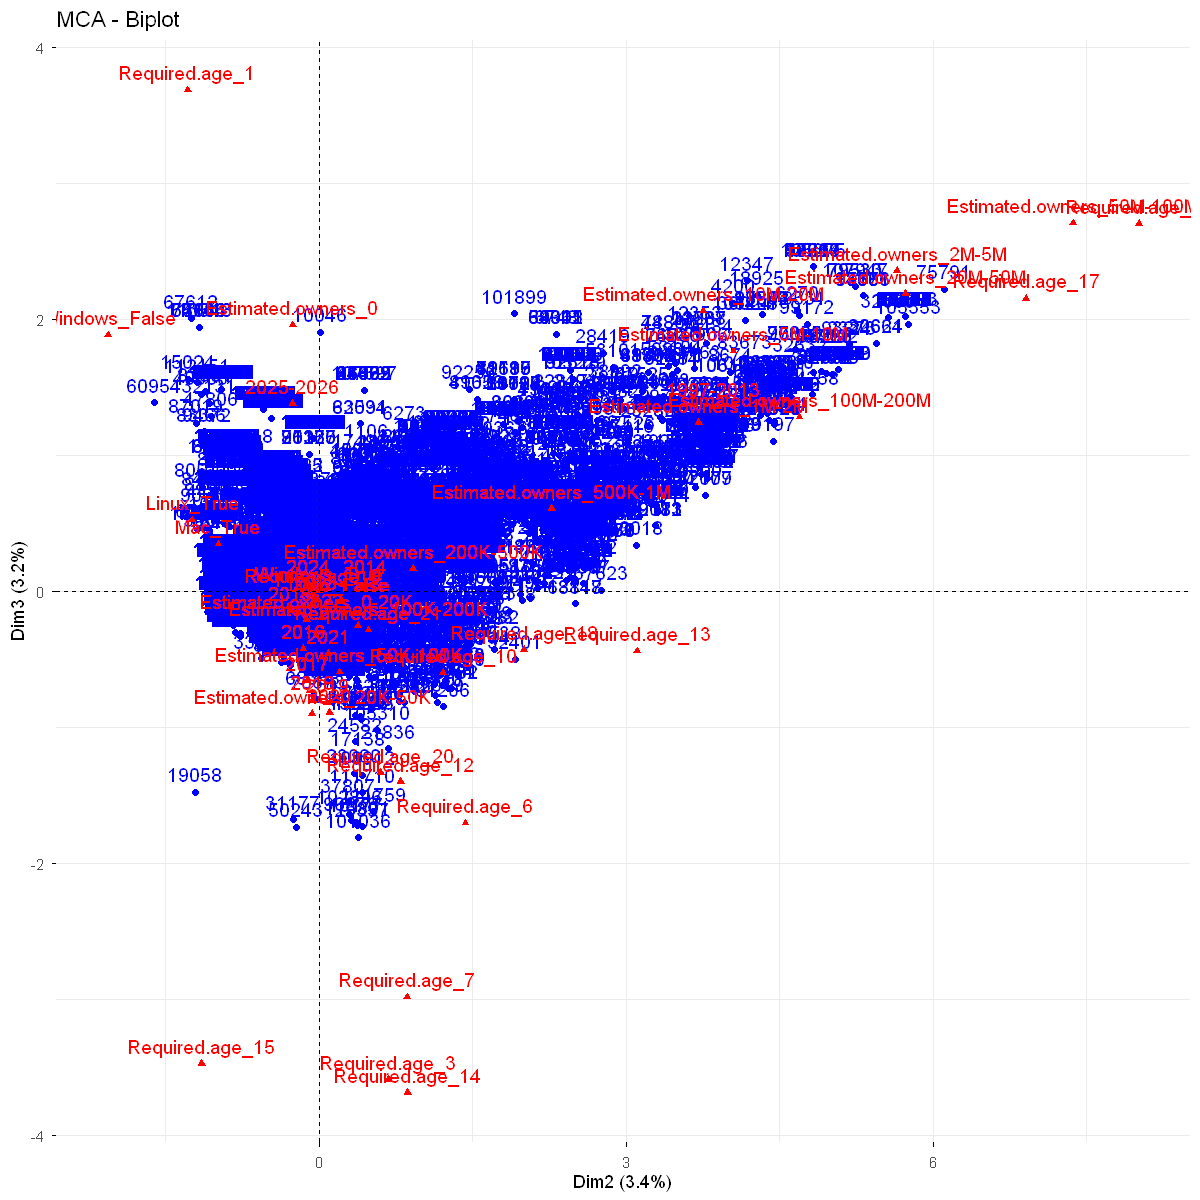

In [157]:
fviz_mca_biplot(res.mca,axes=c(1,3))
fviz_mca_biplot(res.mca,axes=c(2,3))

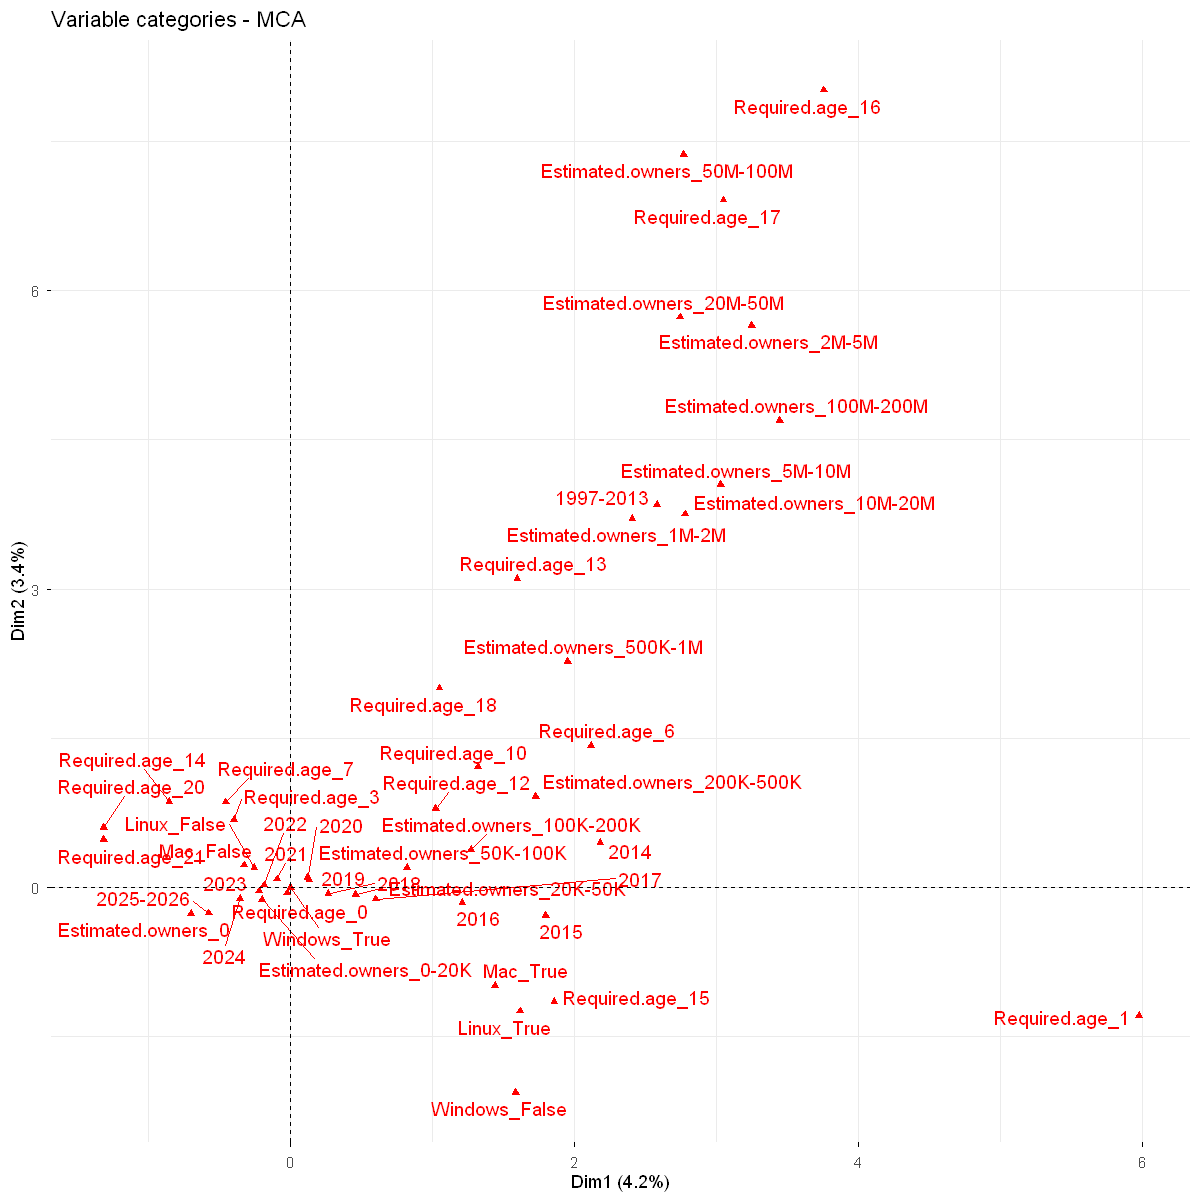

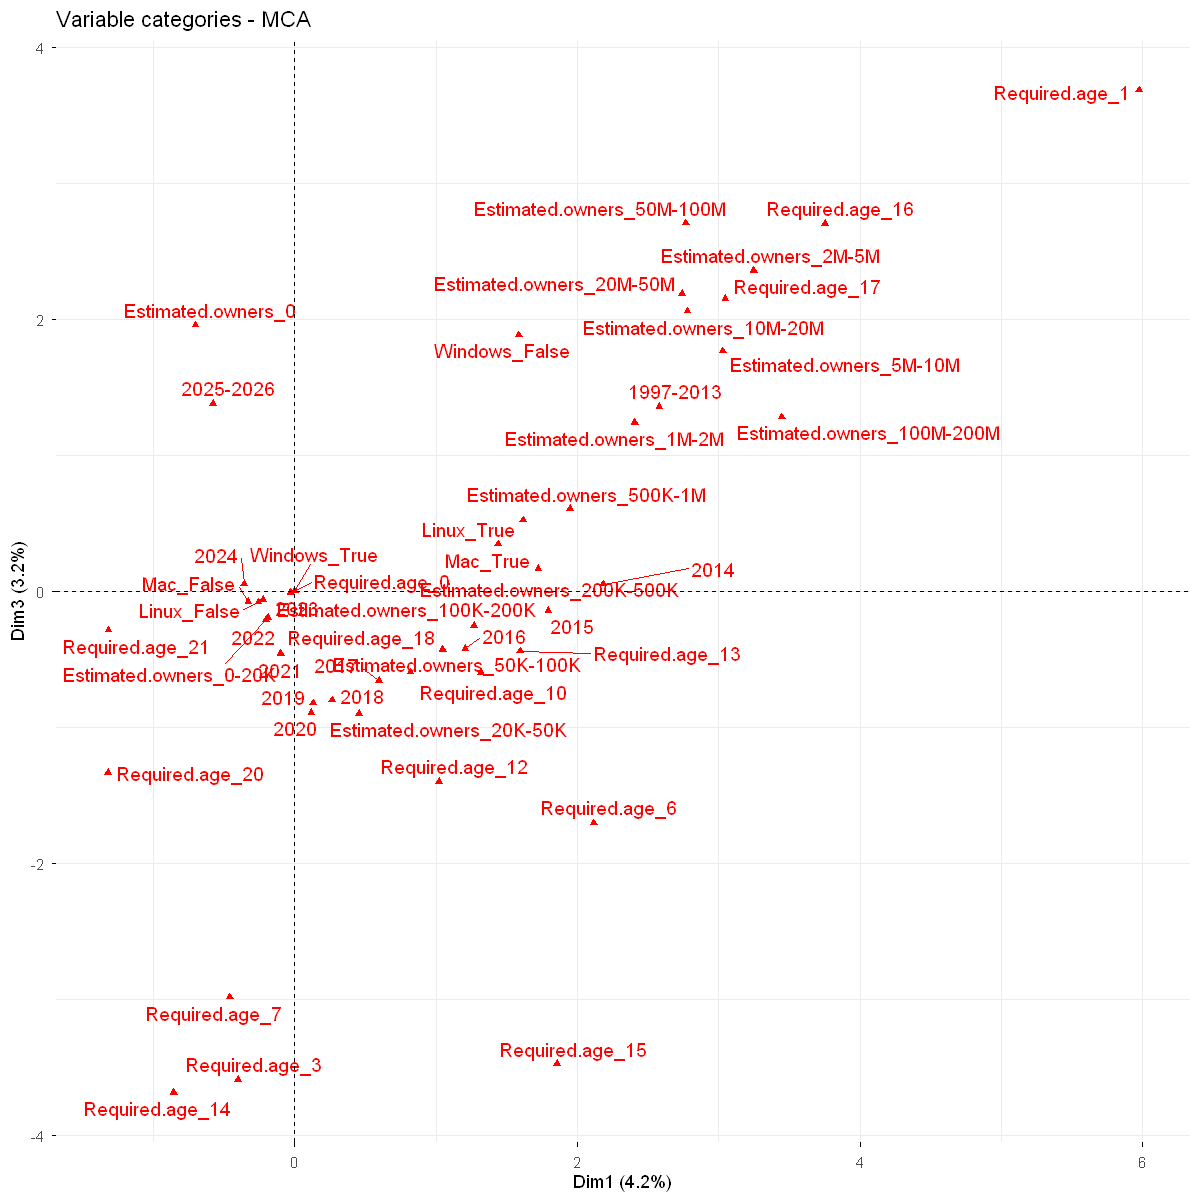

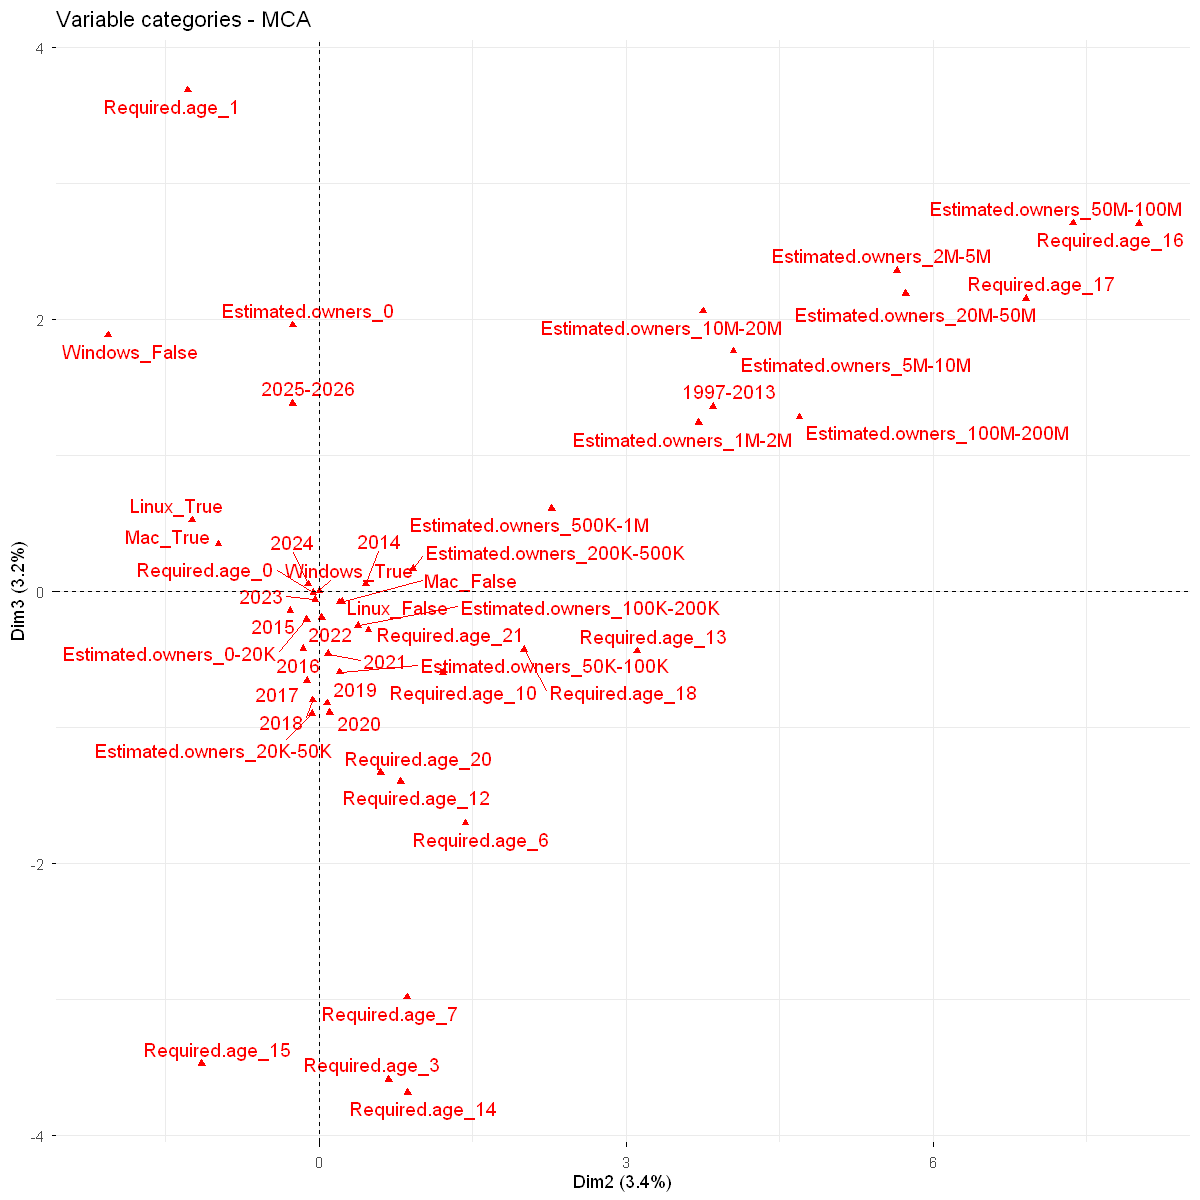

In [156]:
fviz_mca_var(res.mca, repel=TRUE)
fviz_mca_var(res.mca, repel=TRUE,axes = c(1,3))
fviz_mca_var(res.mca, repel=TRUE,axes = c(2,3))

## quality of representation

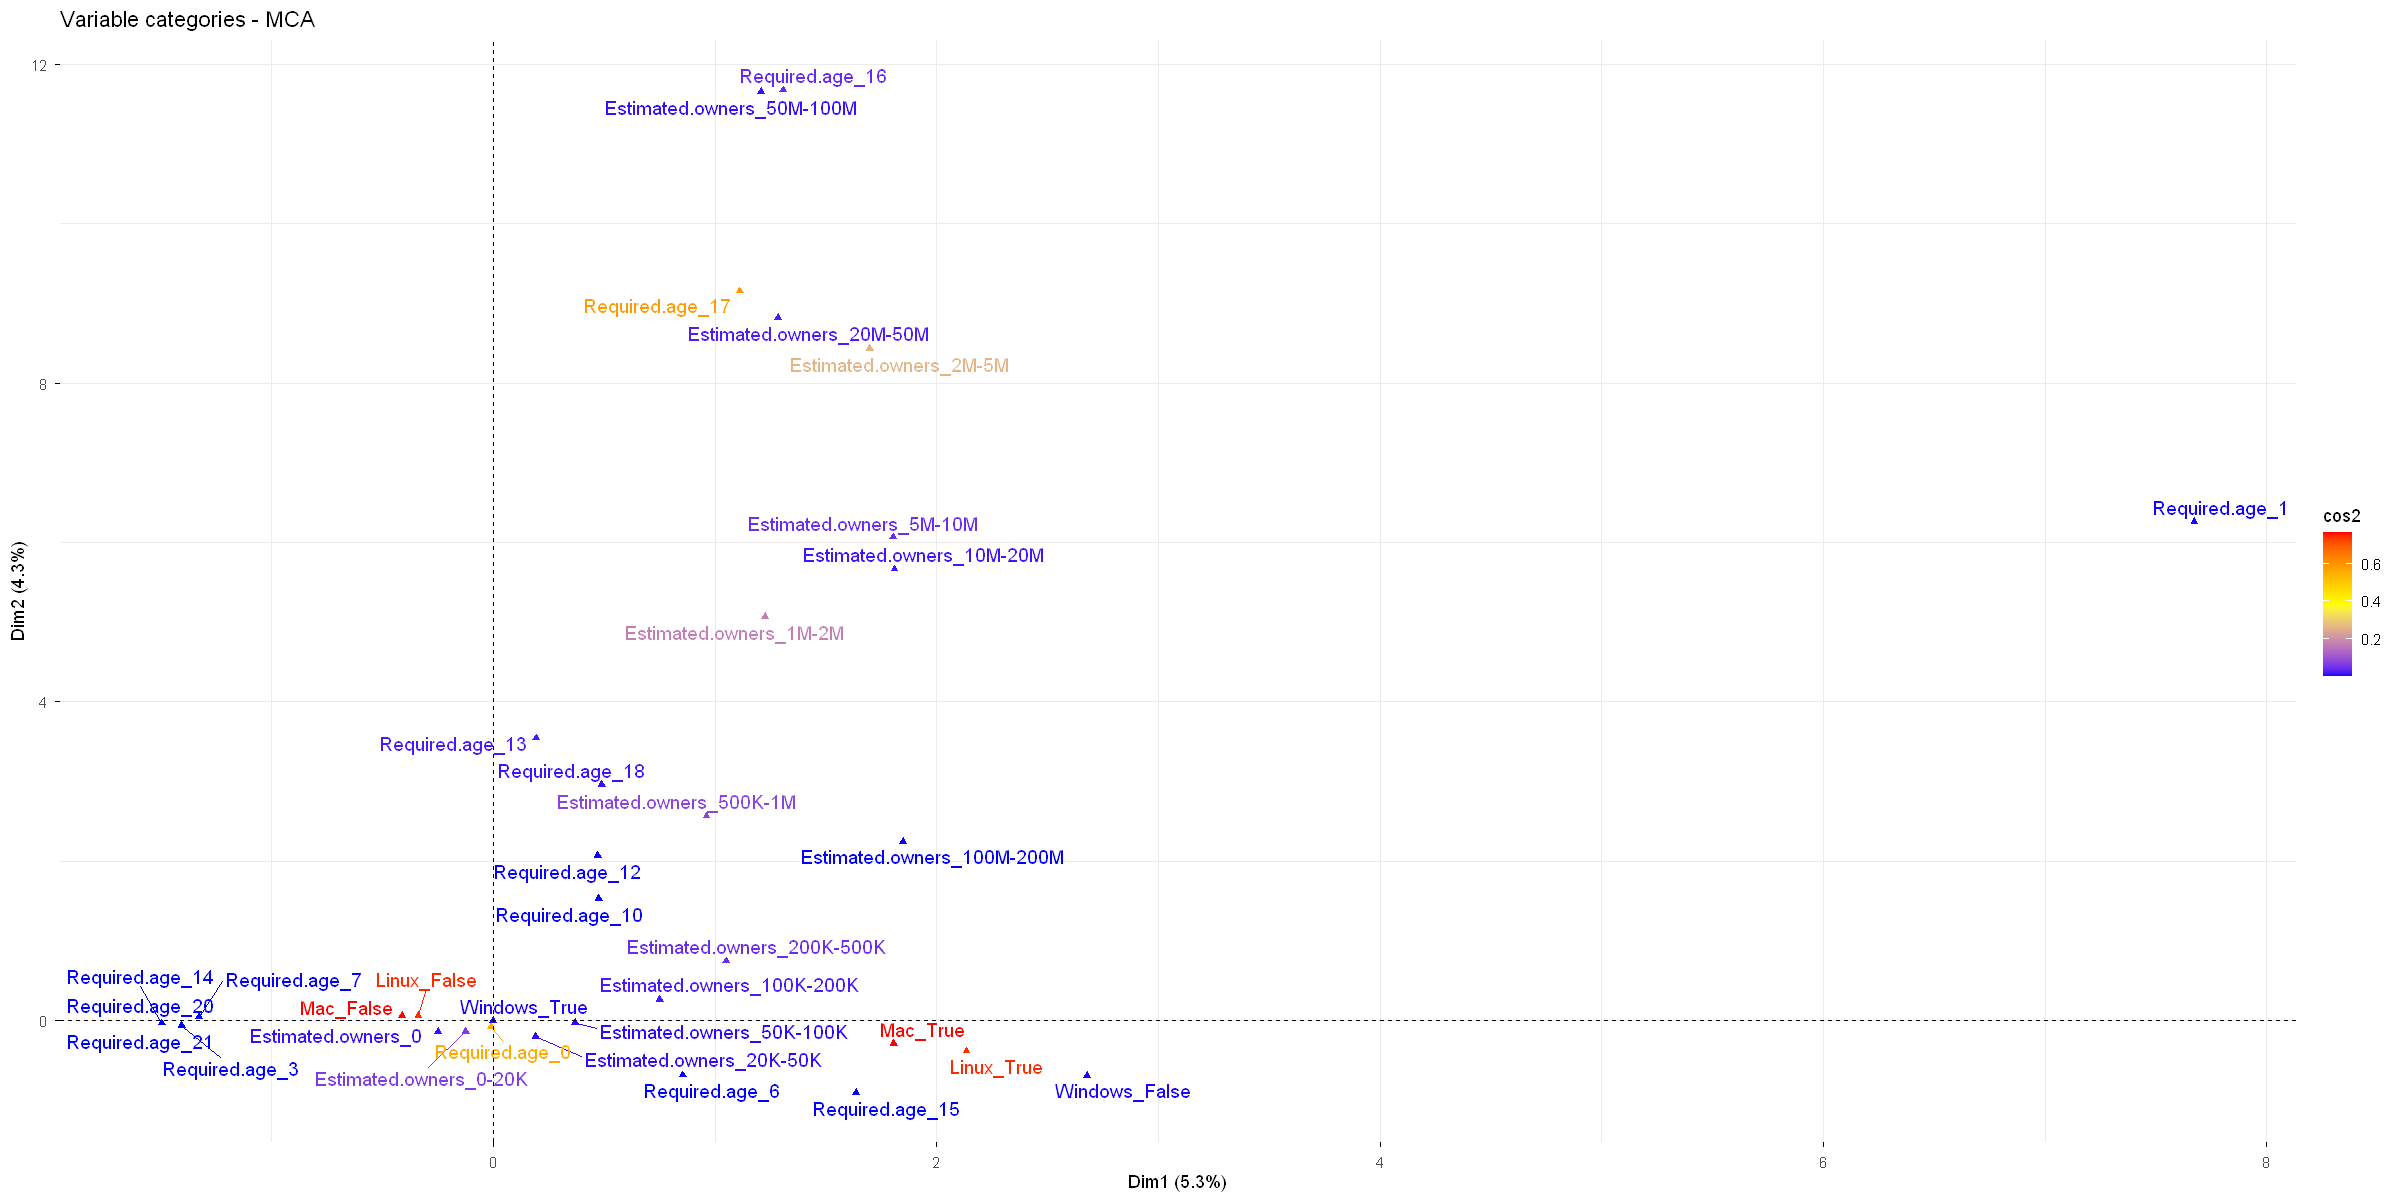

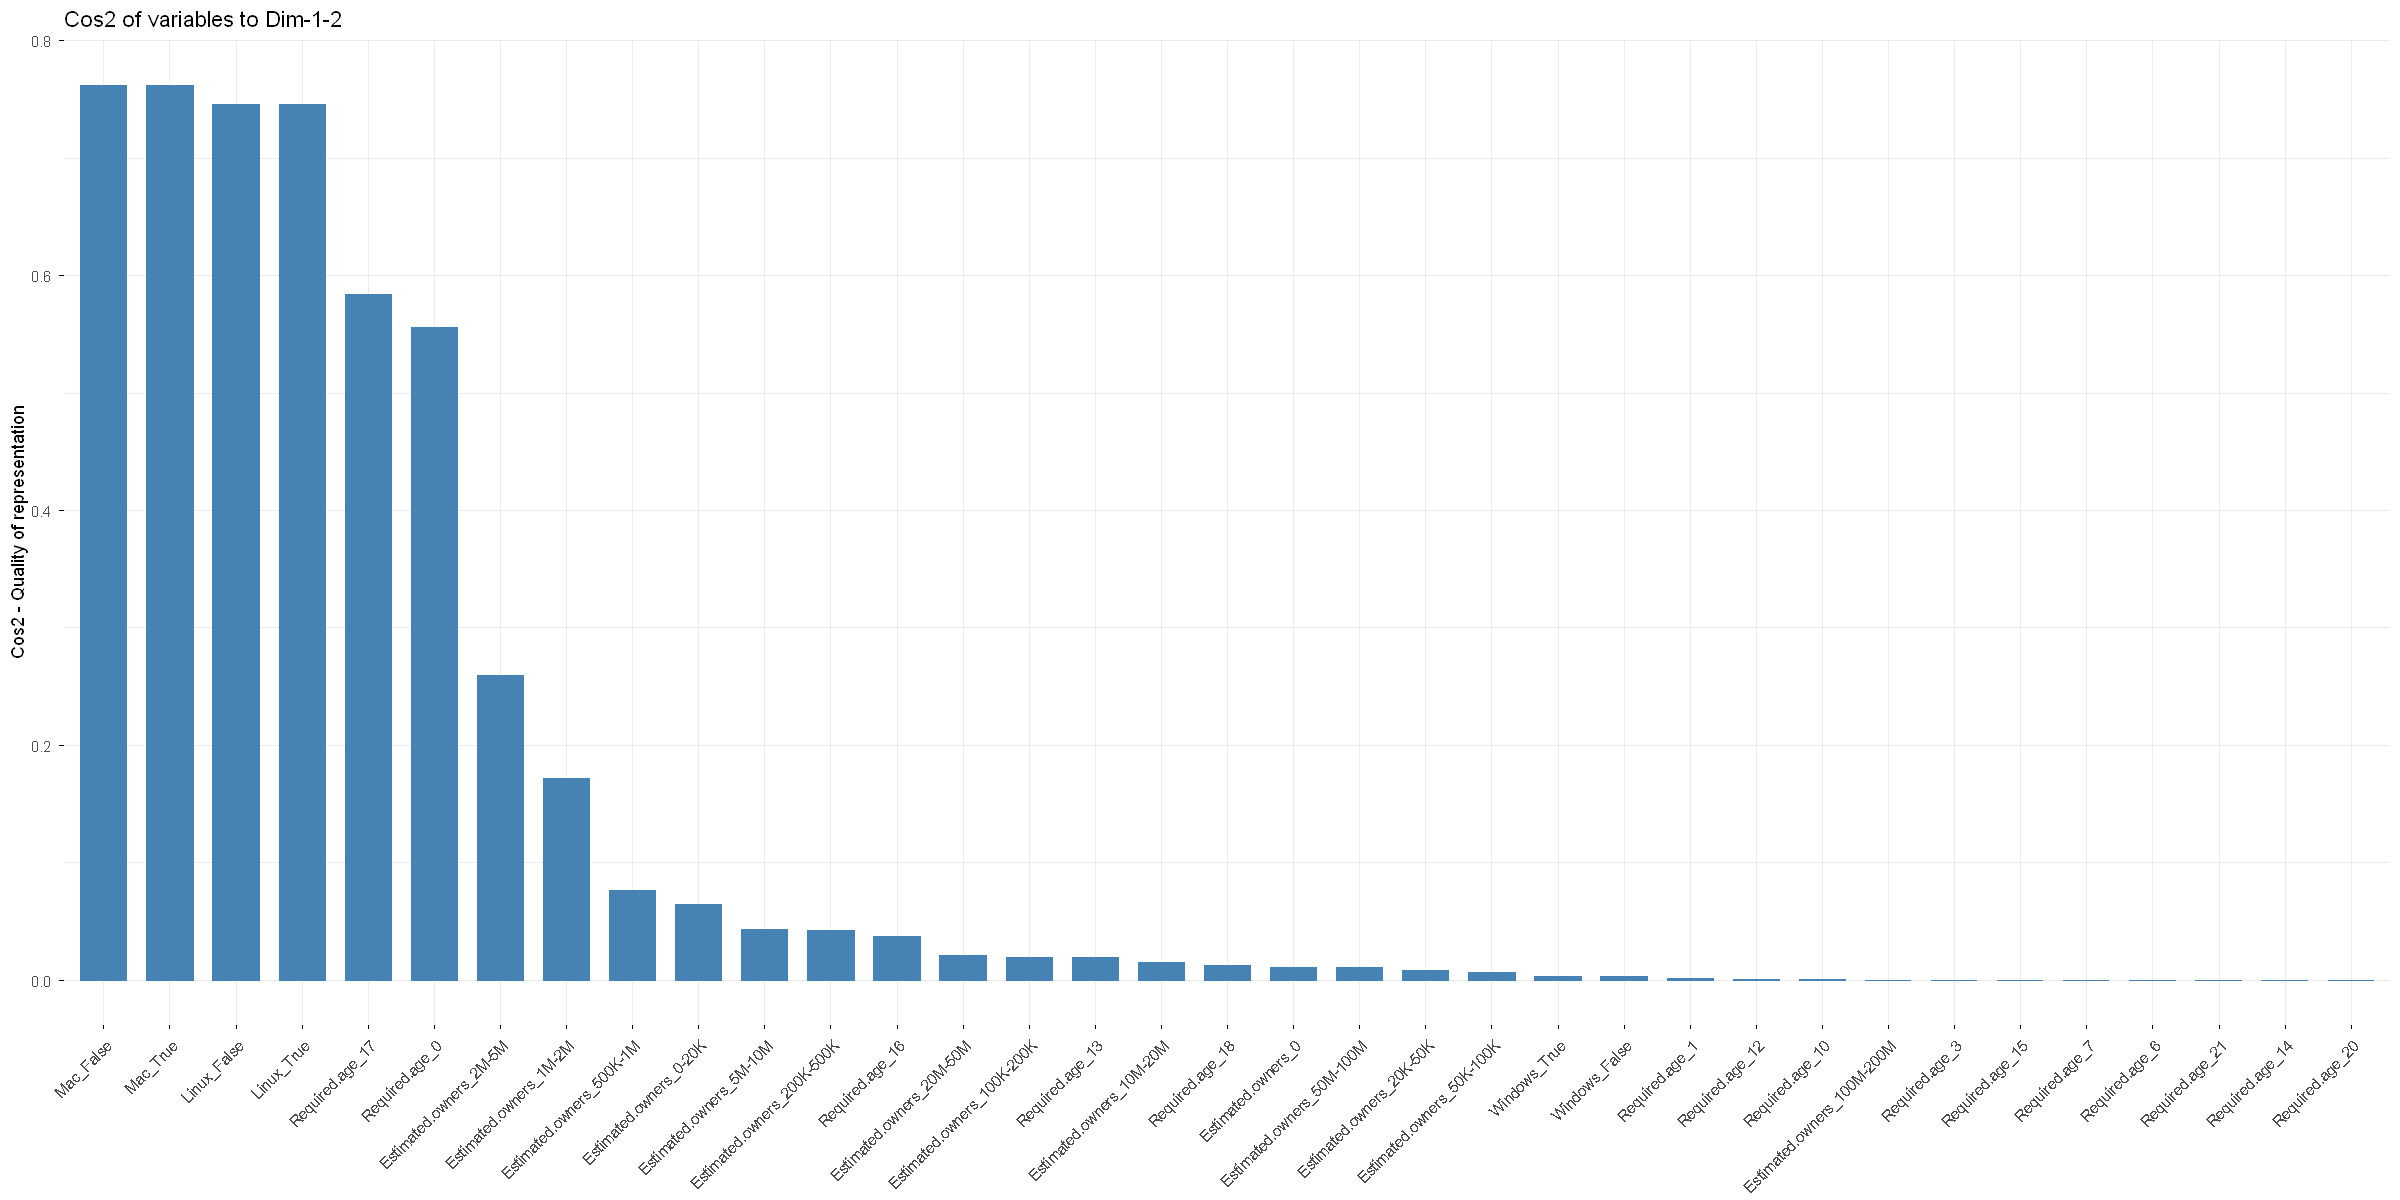

In [55]:
# Color by cos2 values: quality on the factor map
fviz_mca_var(res.mca, col.var = "cos2",
             gradient.cols = c("blue", "yellow", "red"), 
             repel = TRUE )


# Cos2 of variable categories on Dim.1 and Dim.2
fviz_cos2(res.mca, choice = "var", axes = 1:2)


## Contribution

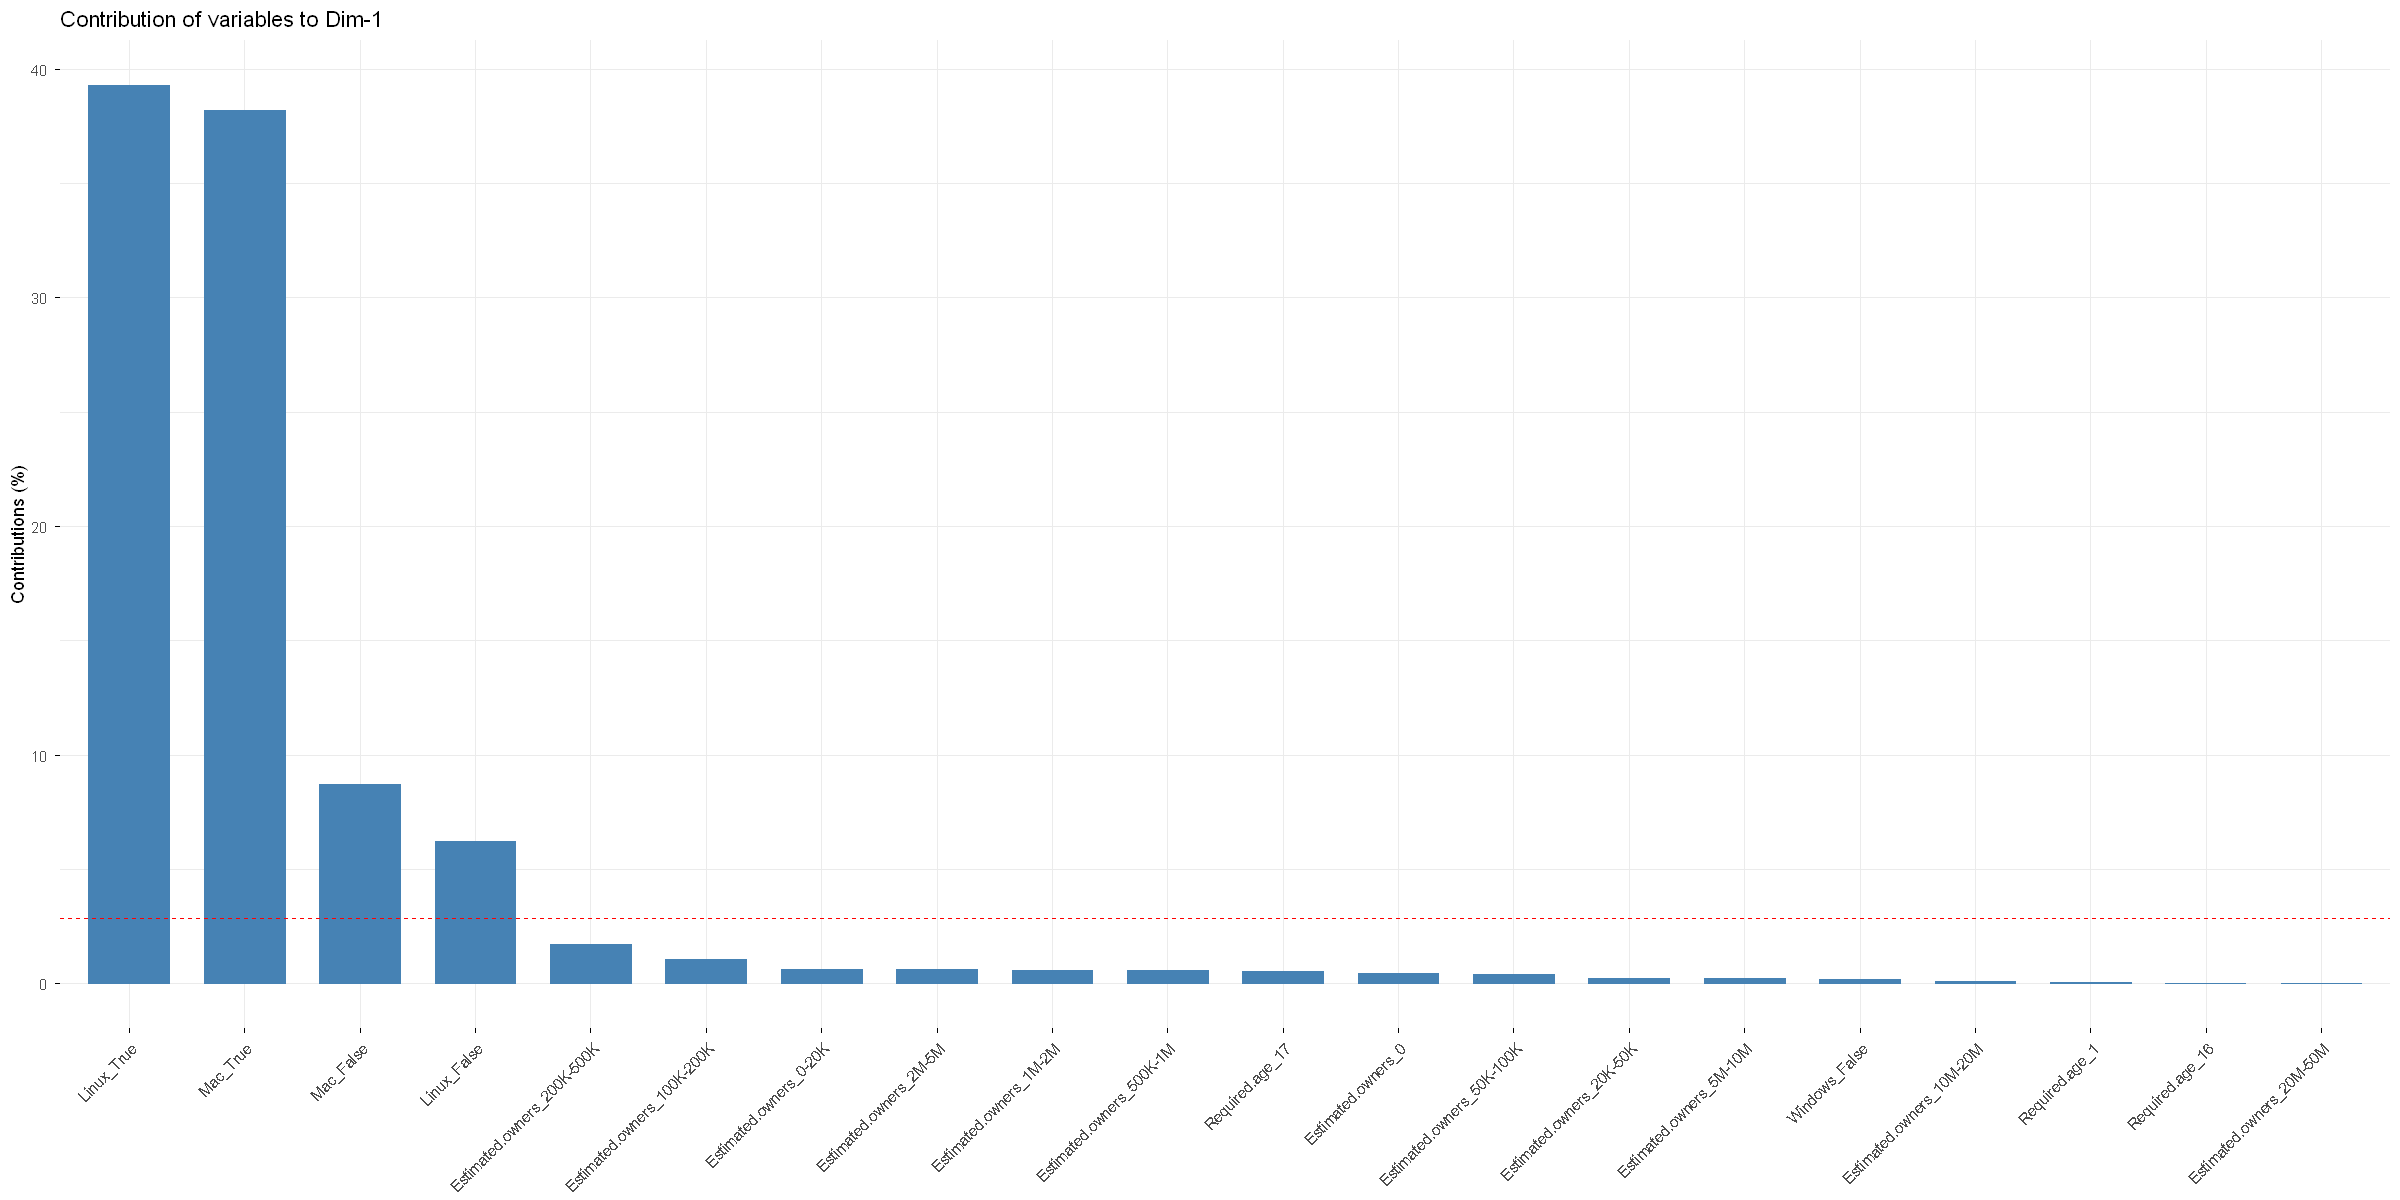

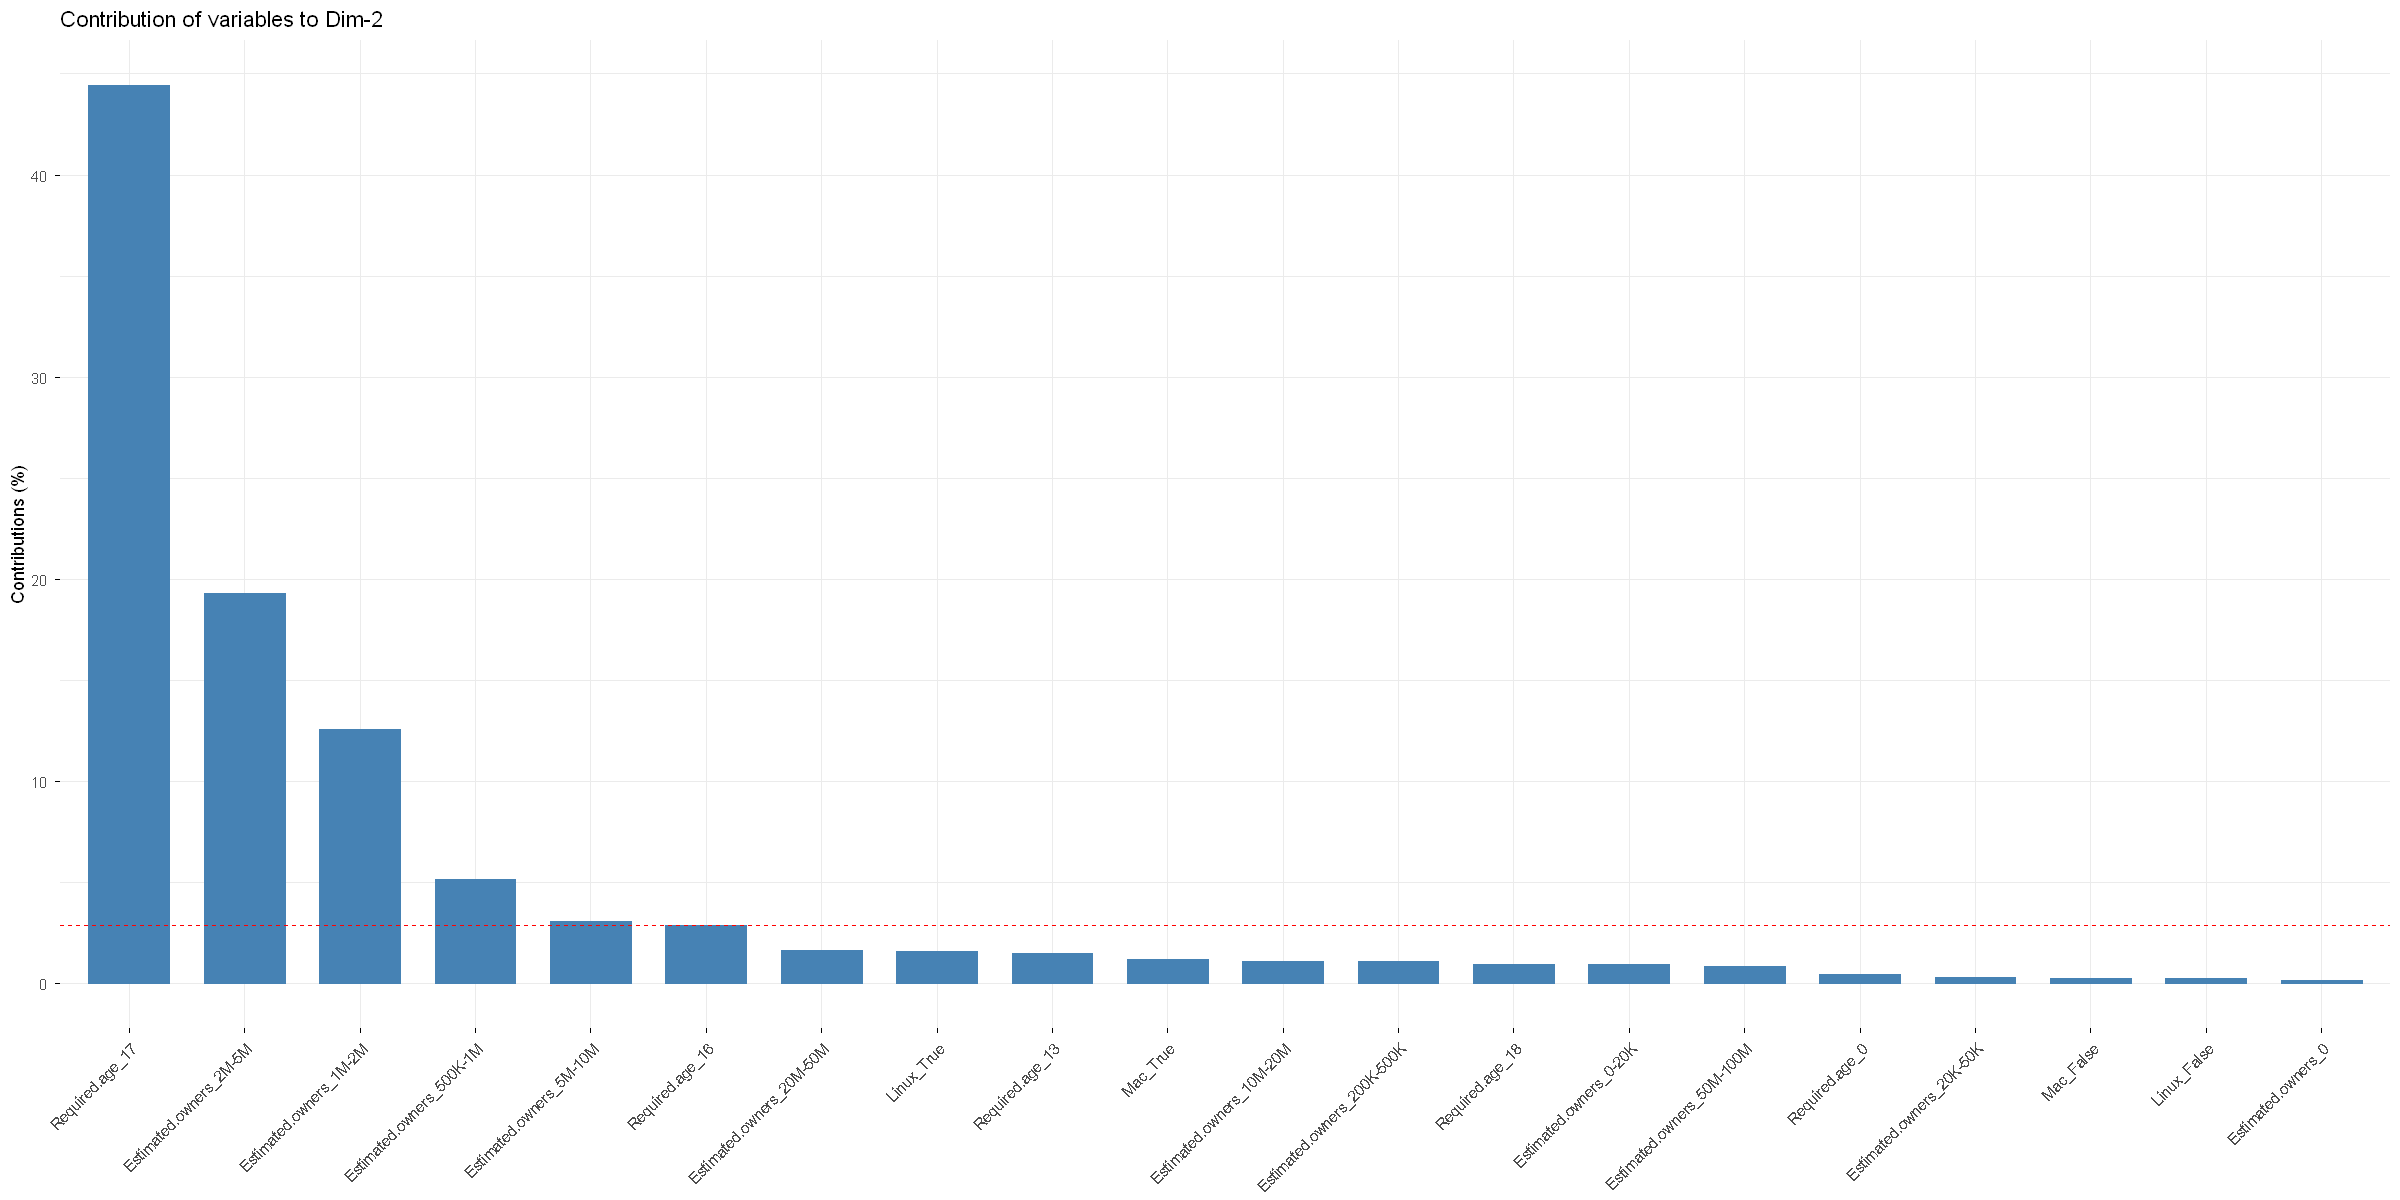

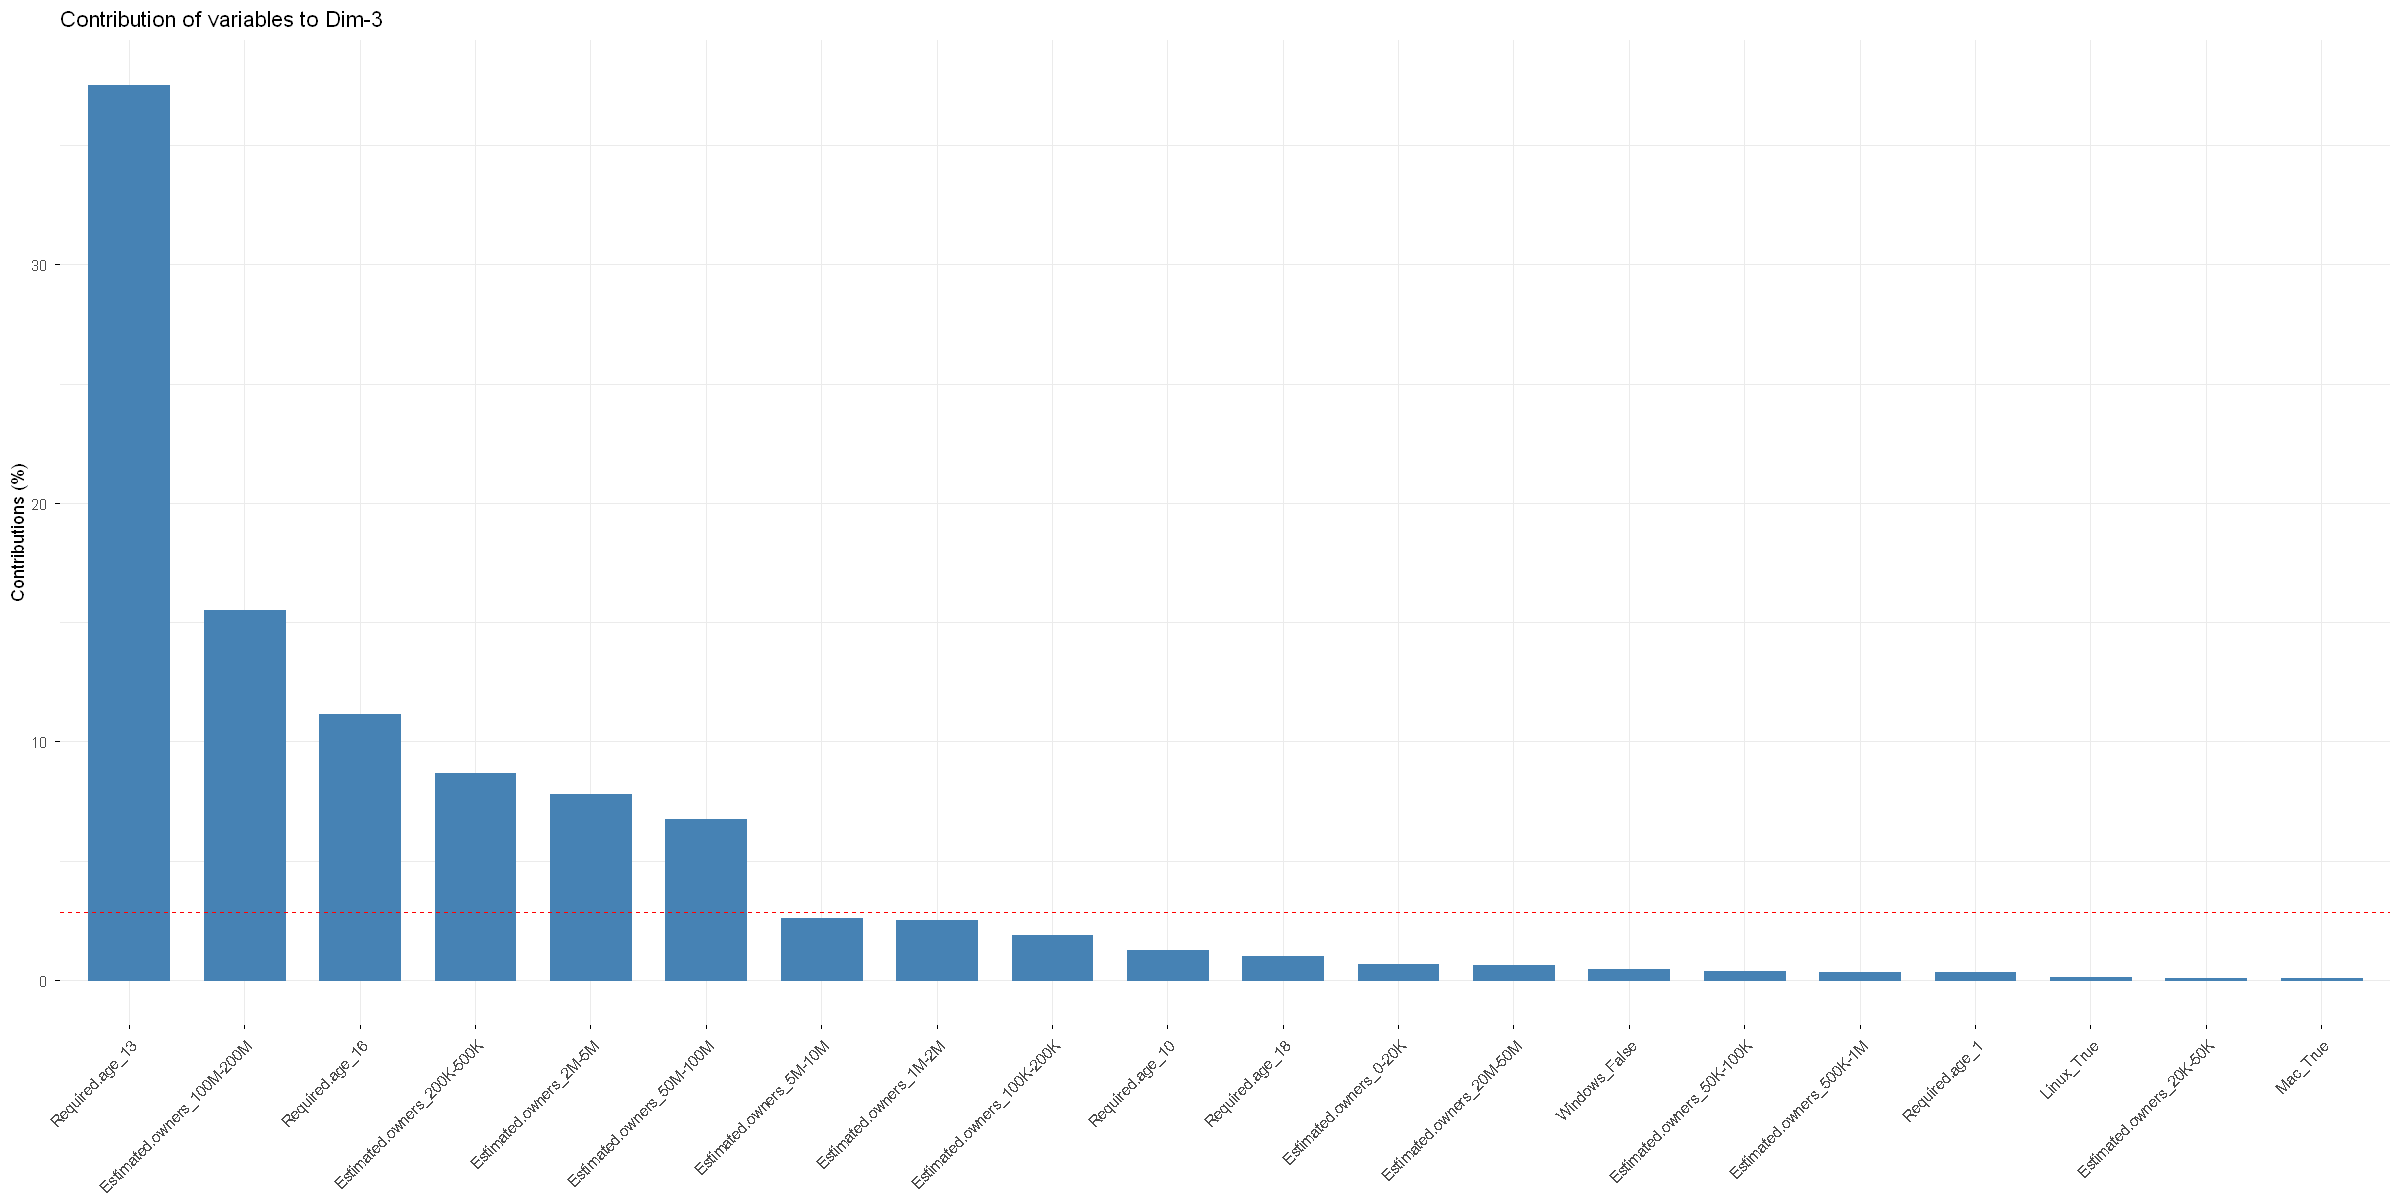

In [60]:
# Contributions of hobbies to dimension 1
fviz_contrib(res.mca, choice="var", axes=1, top=20)

# Contributions of hobbies to dimension 2
fviz_contrib(res.mca, choice="var", axes=2, top=20)
fviz_contrib(res.mca, choice="var", axes=3, top=20)


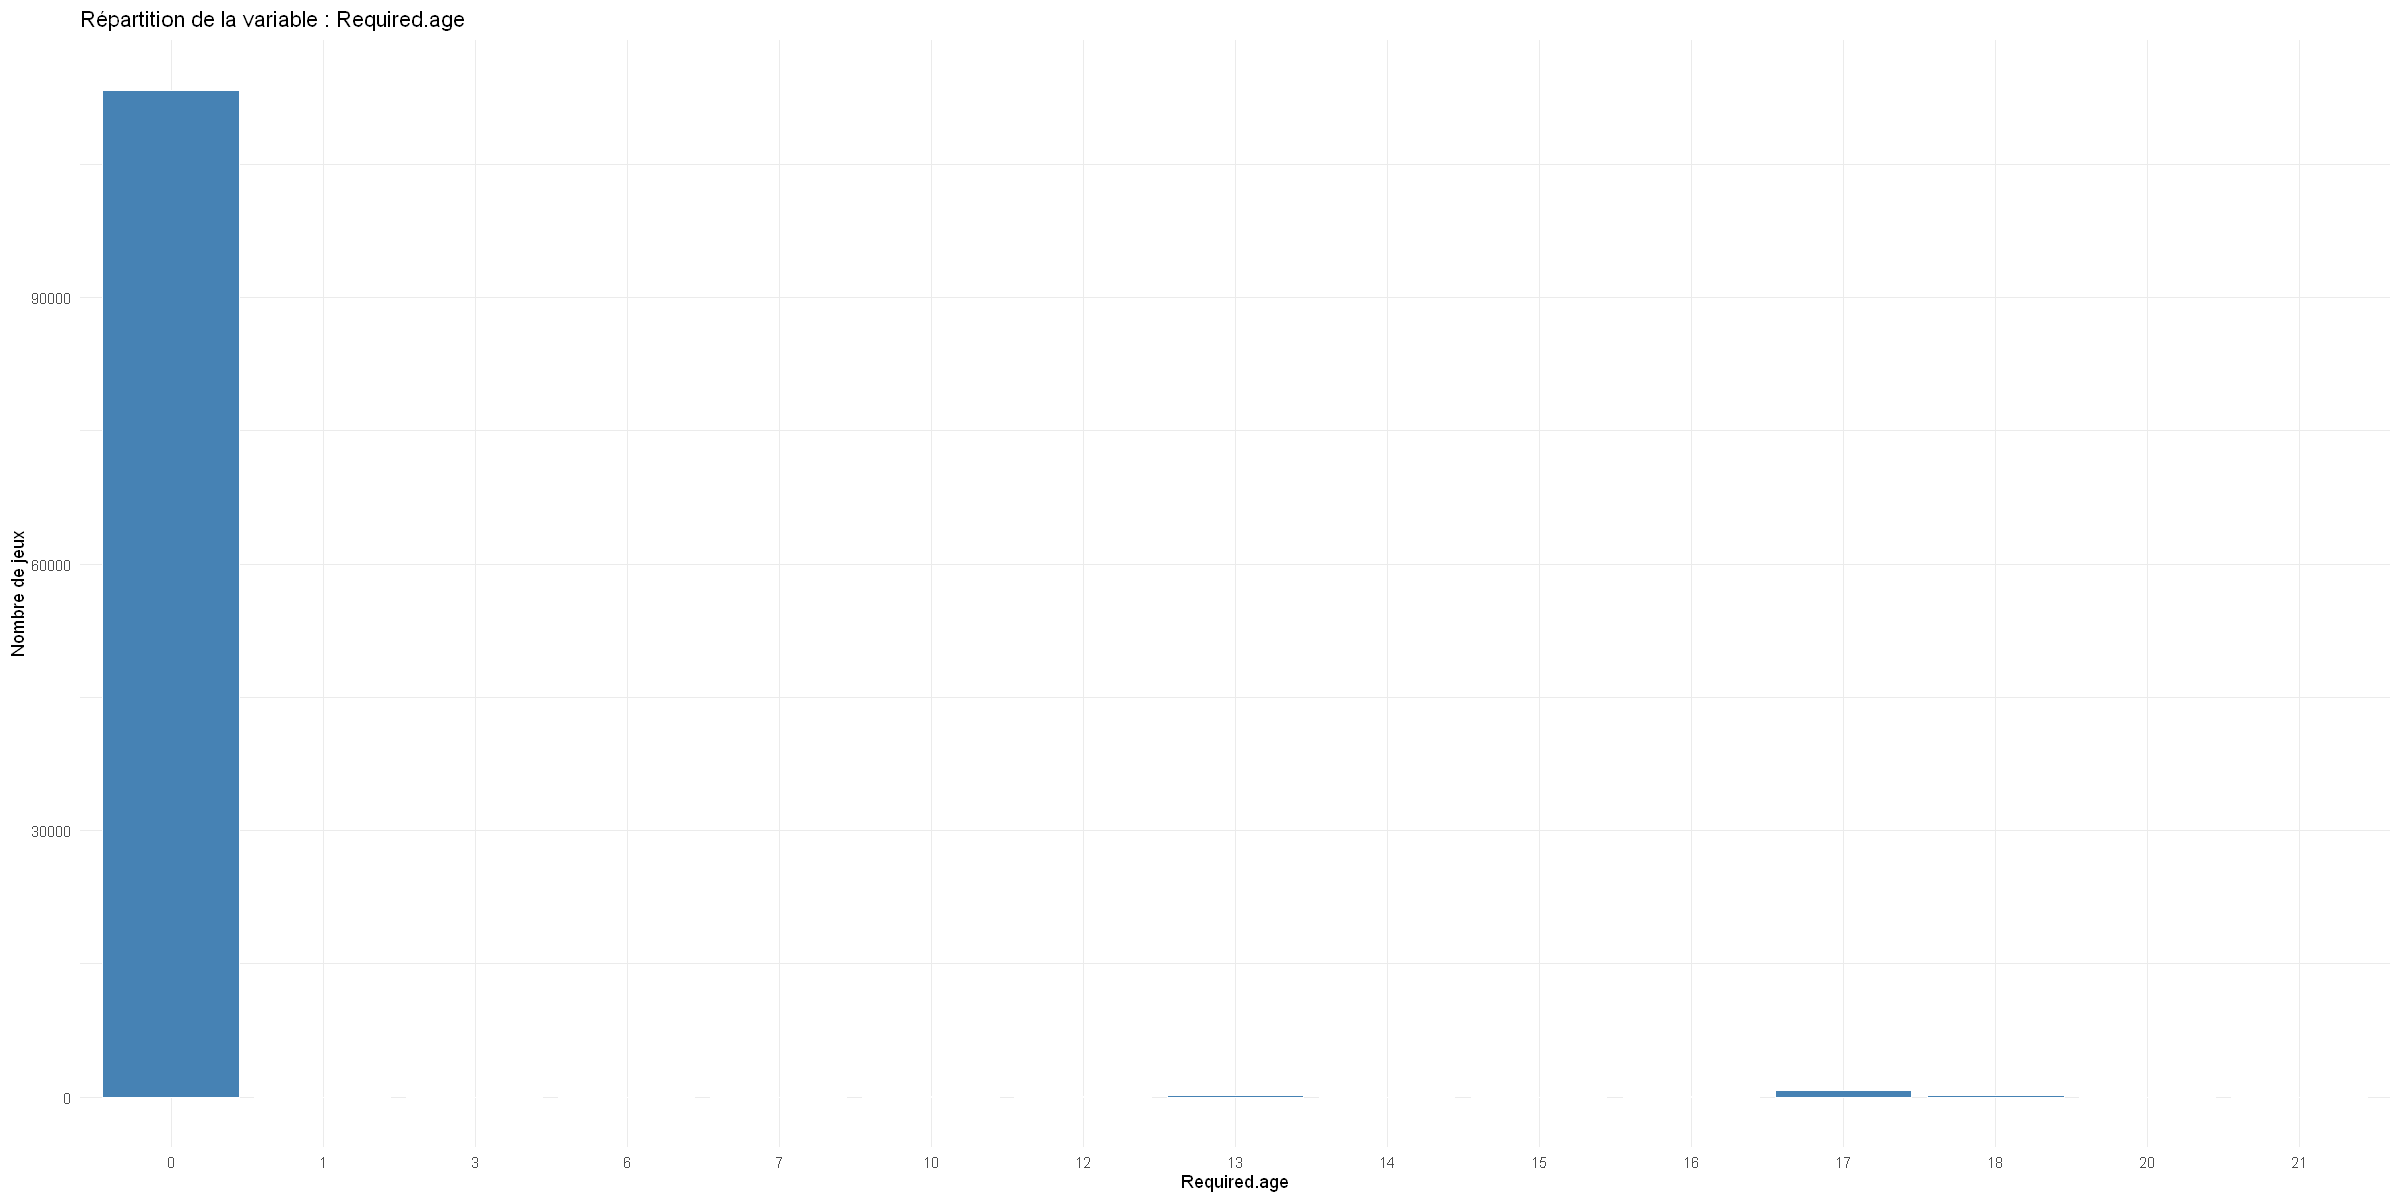

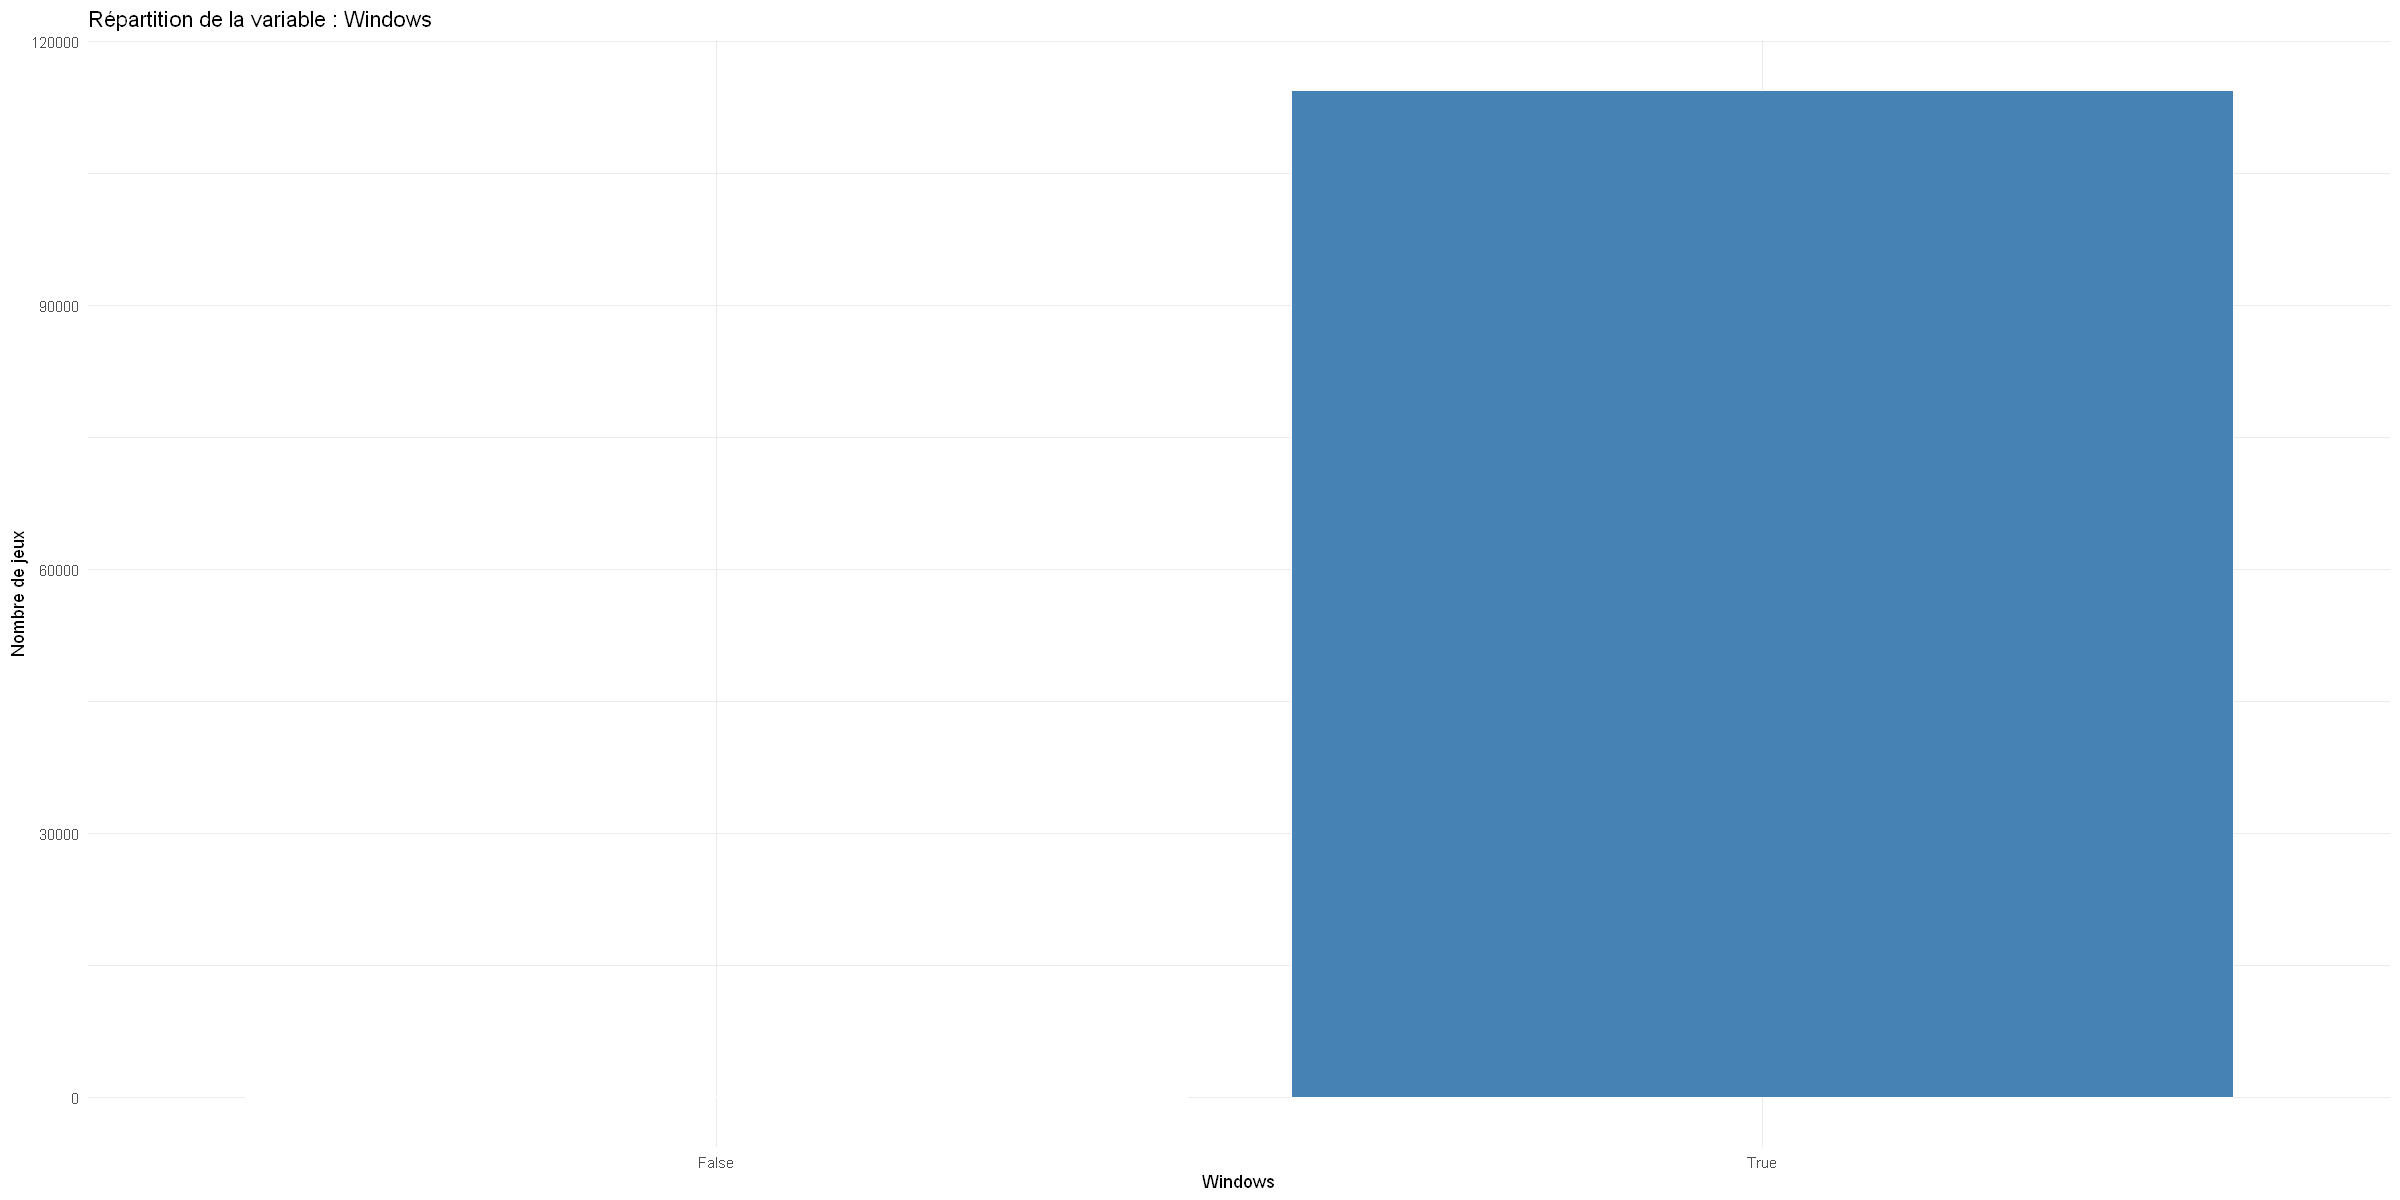

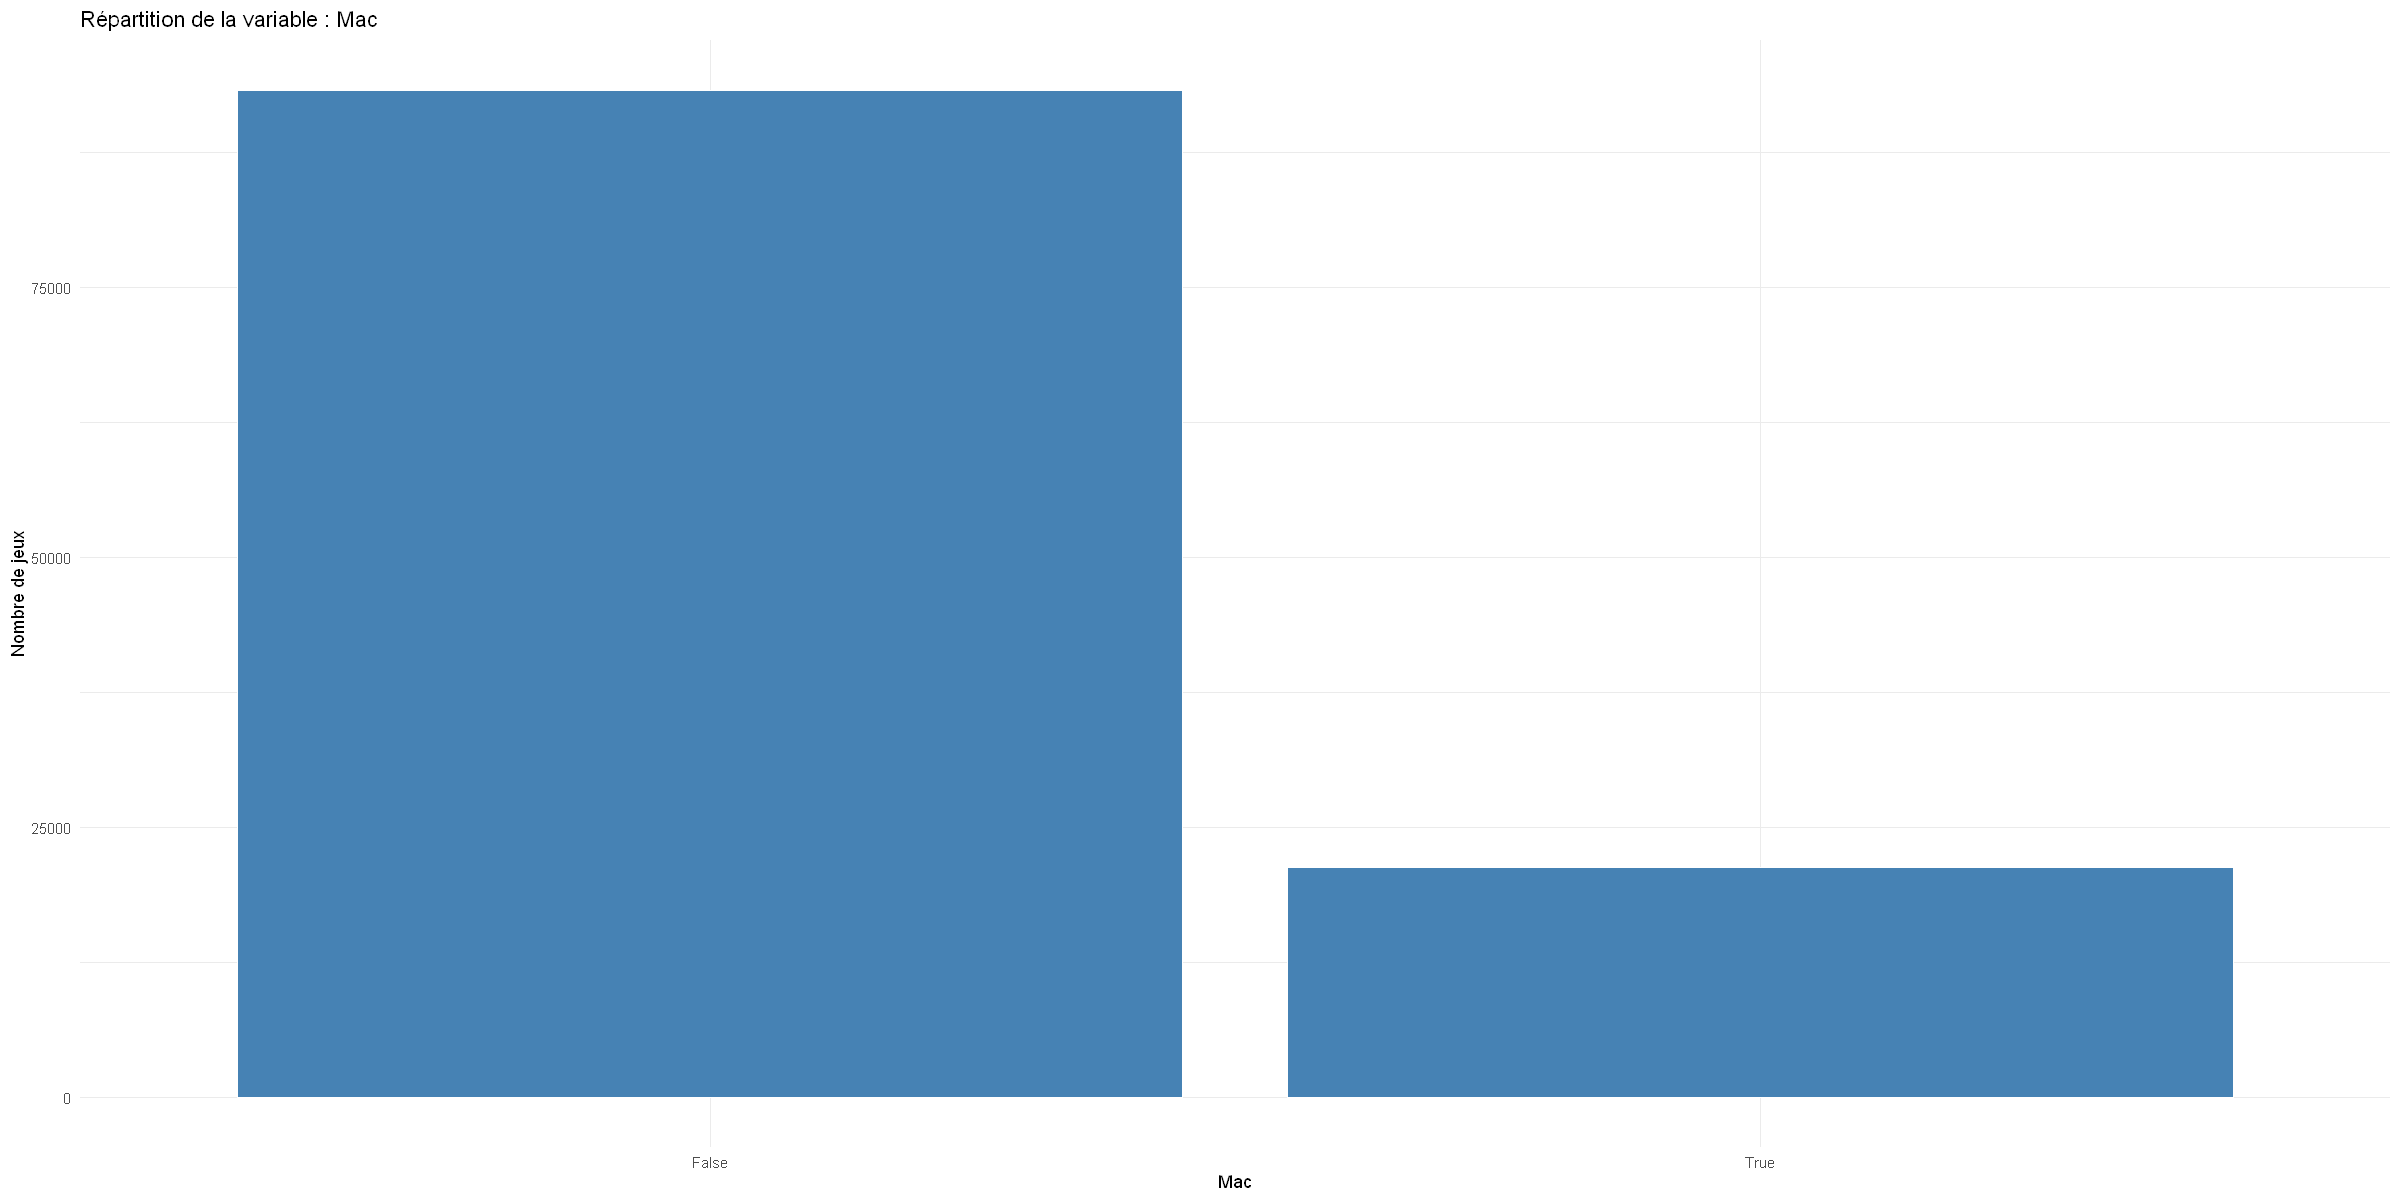

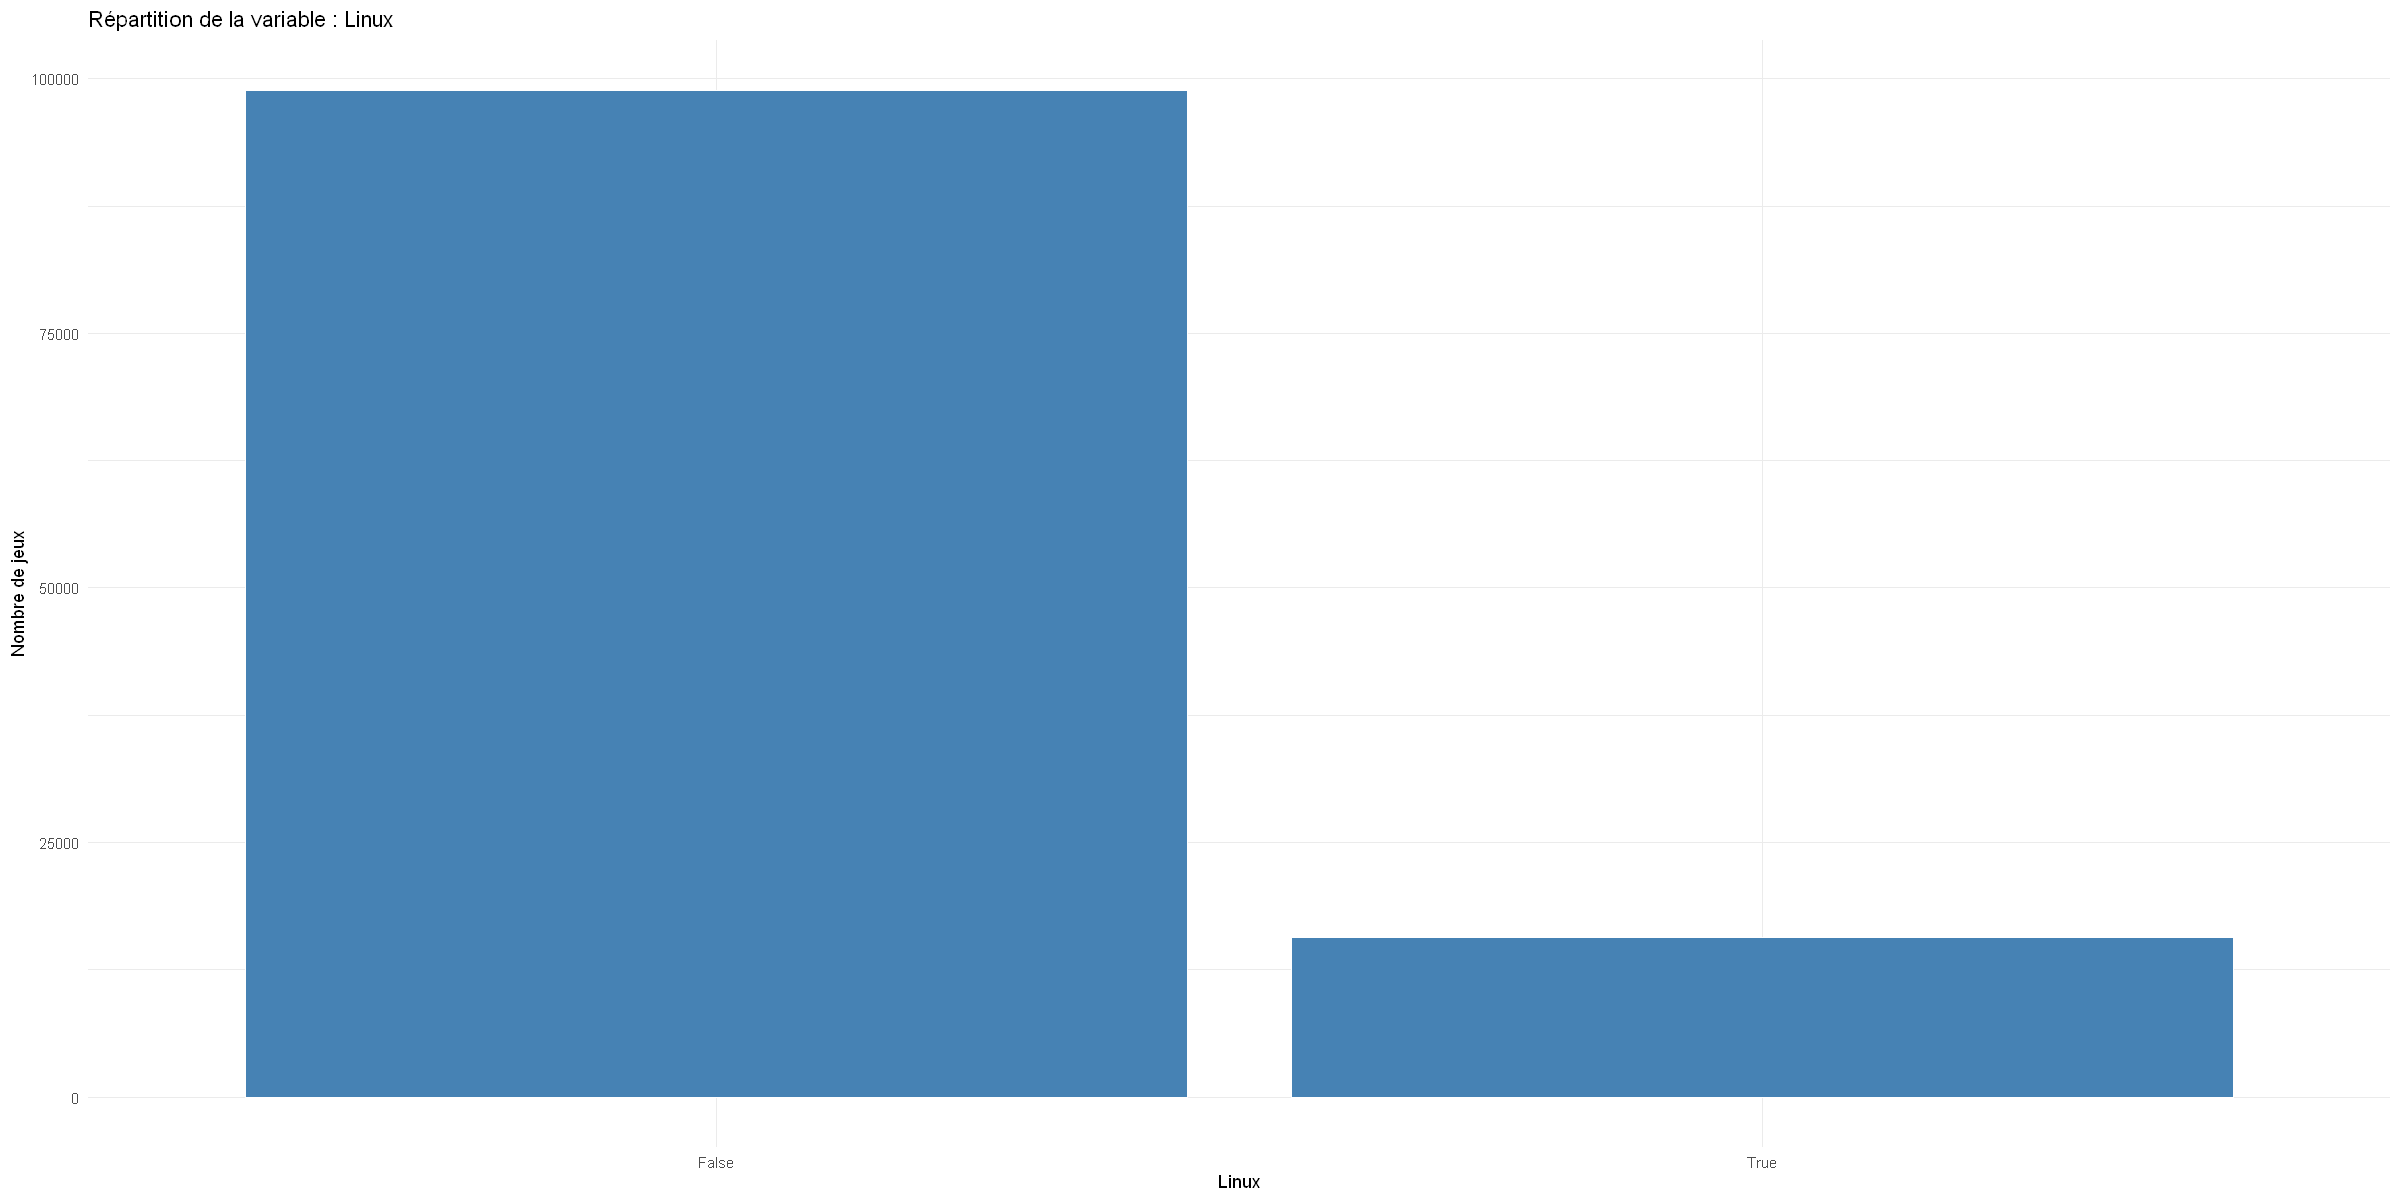

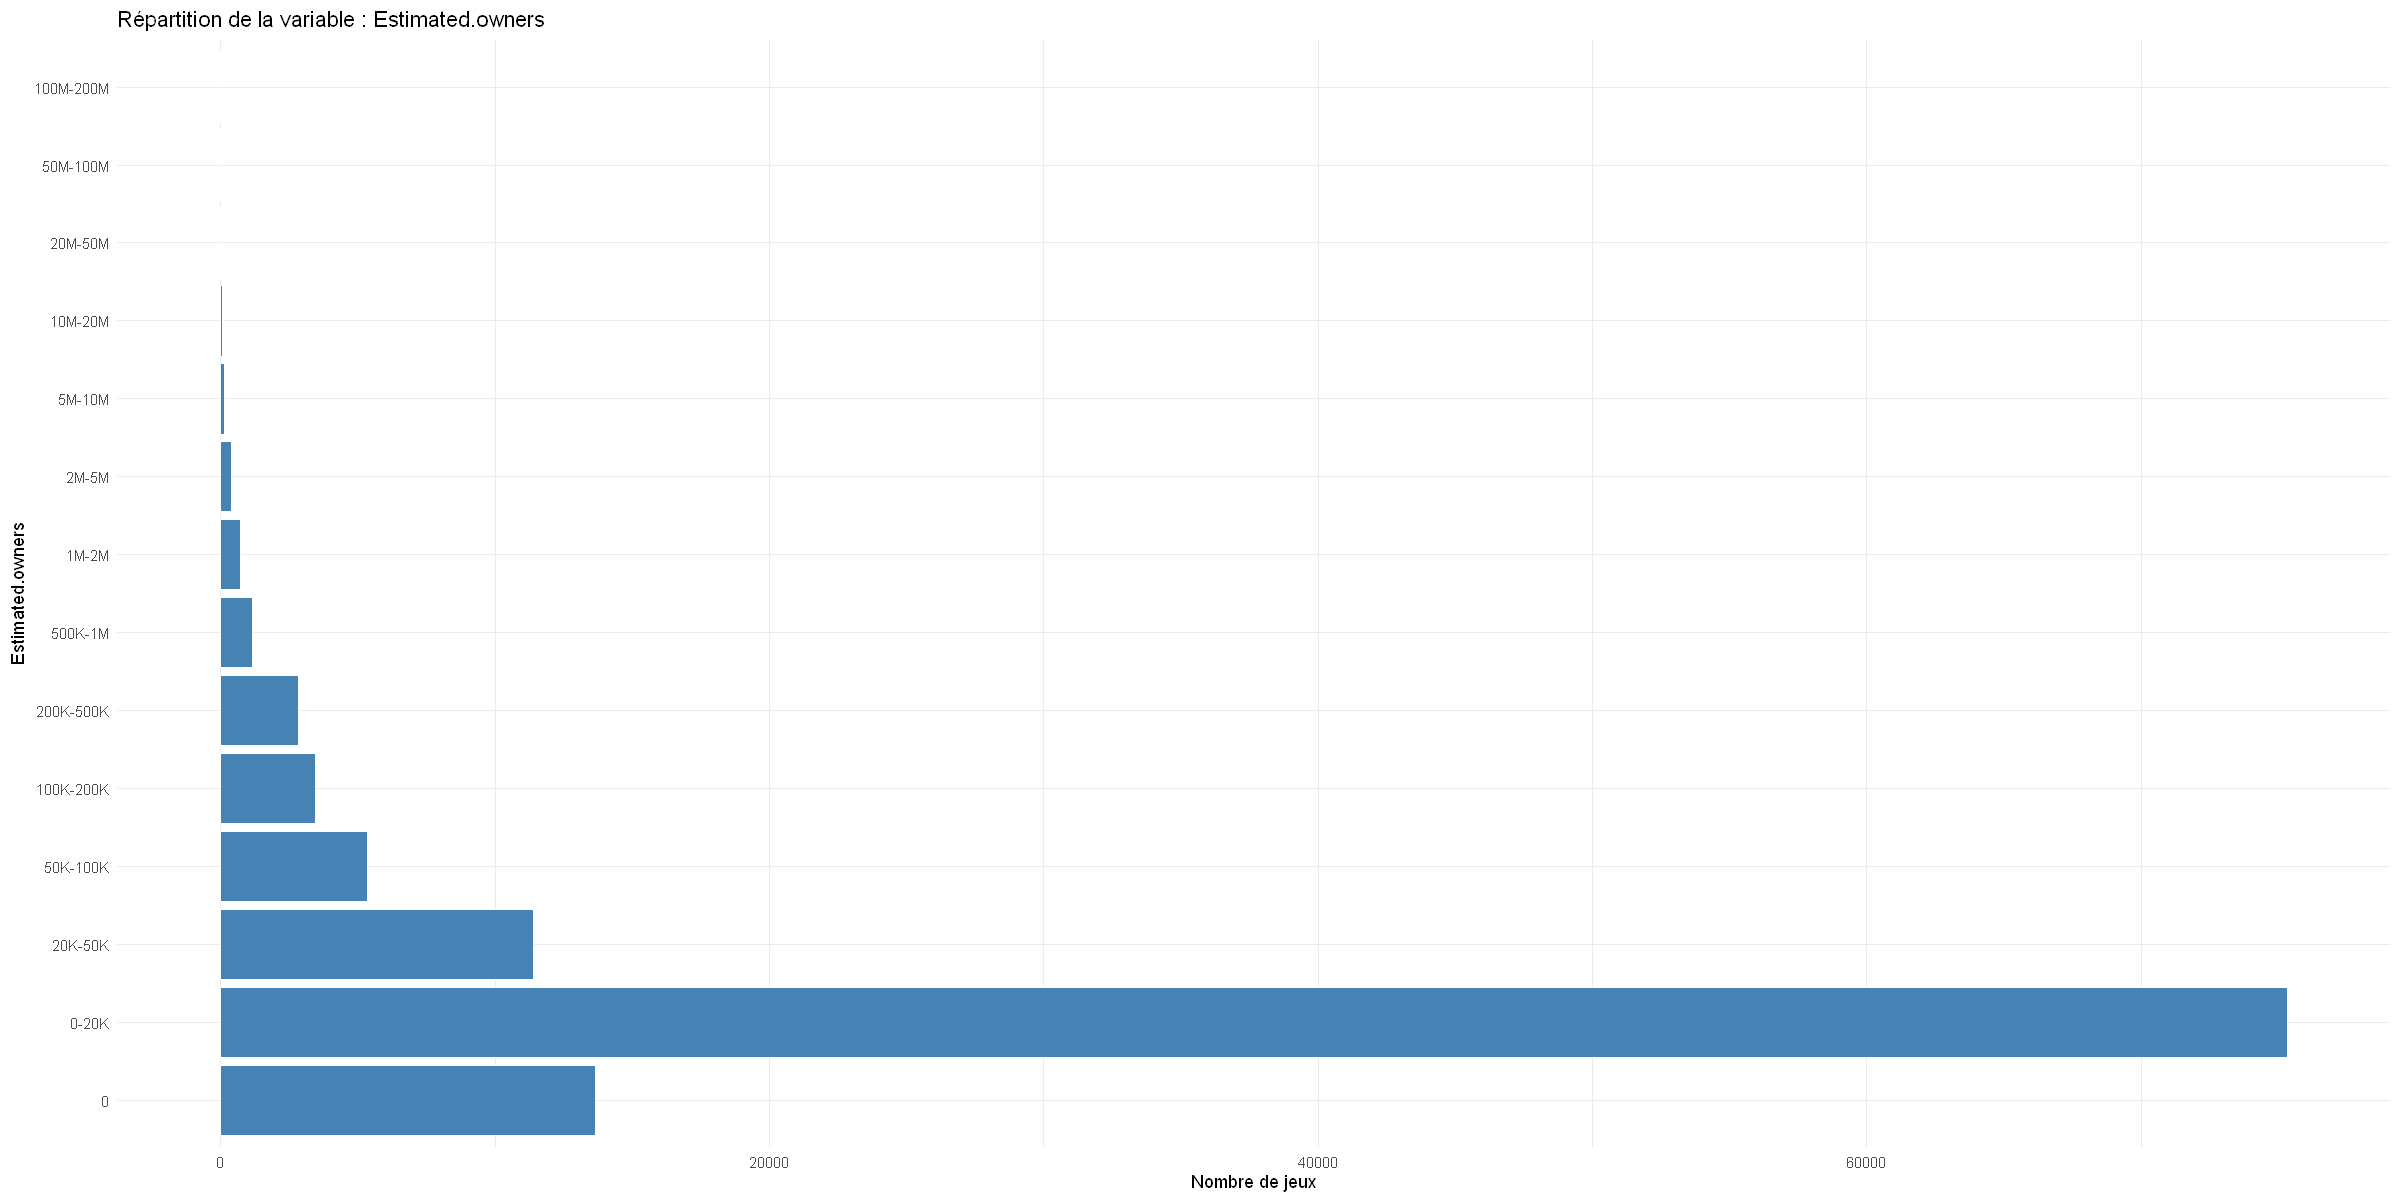

In [44]:

# On définit la liste de TES variables (car is.factor risque de rater le coche)
colonnes_qualitatives <- c("Required.age", "Windows", "Mac", "Linux", "Estimated.owners")

for (col in colonnes_qualitatives) {
    # On utilise geom_bar() car il compte les lignes automatiquement
    p <- ggplot(data_ready, aes(x = .data[[col]])) +
      geom_bar(fill = "steelblue", color = "white") +
      theme_minimal() +
      labs(
        title = paste("Répartition de la variable :", col),
        x = col,
        y = "Nombre de jeux"
      )
    
    # Gestion spécifique pour la lisibilité des owners
    if (col == "Estimated.owners") {
      p <- p + coord_flip()
    }
    
    print(p)

}

Pour les variables qualitatives, nous pouvons conclure que la quasi-totalité des jeux sont disponible sur Windows et seulement qu'une petite partie sur Windows et Linux.
De plus, il n'y a que très peu de jeux qui qui ont beaucoup d'utilisateurs, la plupart ont entre 0 et 20 000 déteneurs du jeu.
Enfin, on remarque que très peu de jeux ont des restriction d'âge

# Etude TagGgenre

[1] 452   2


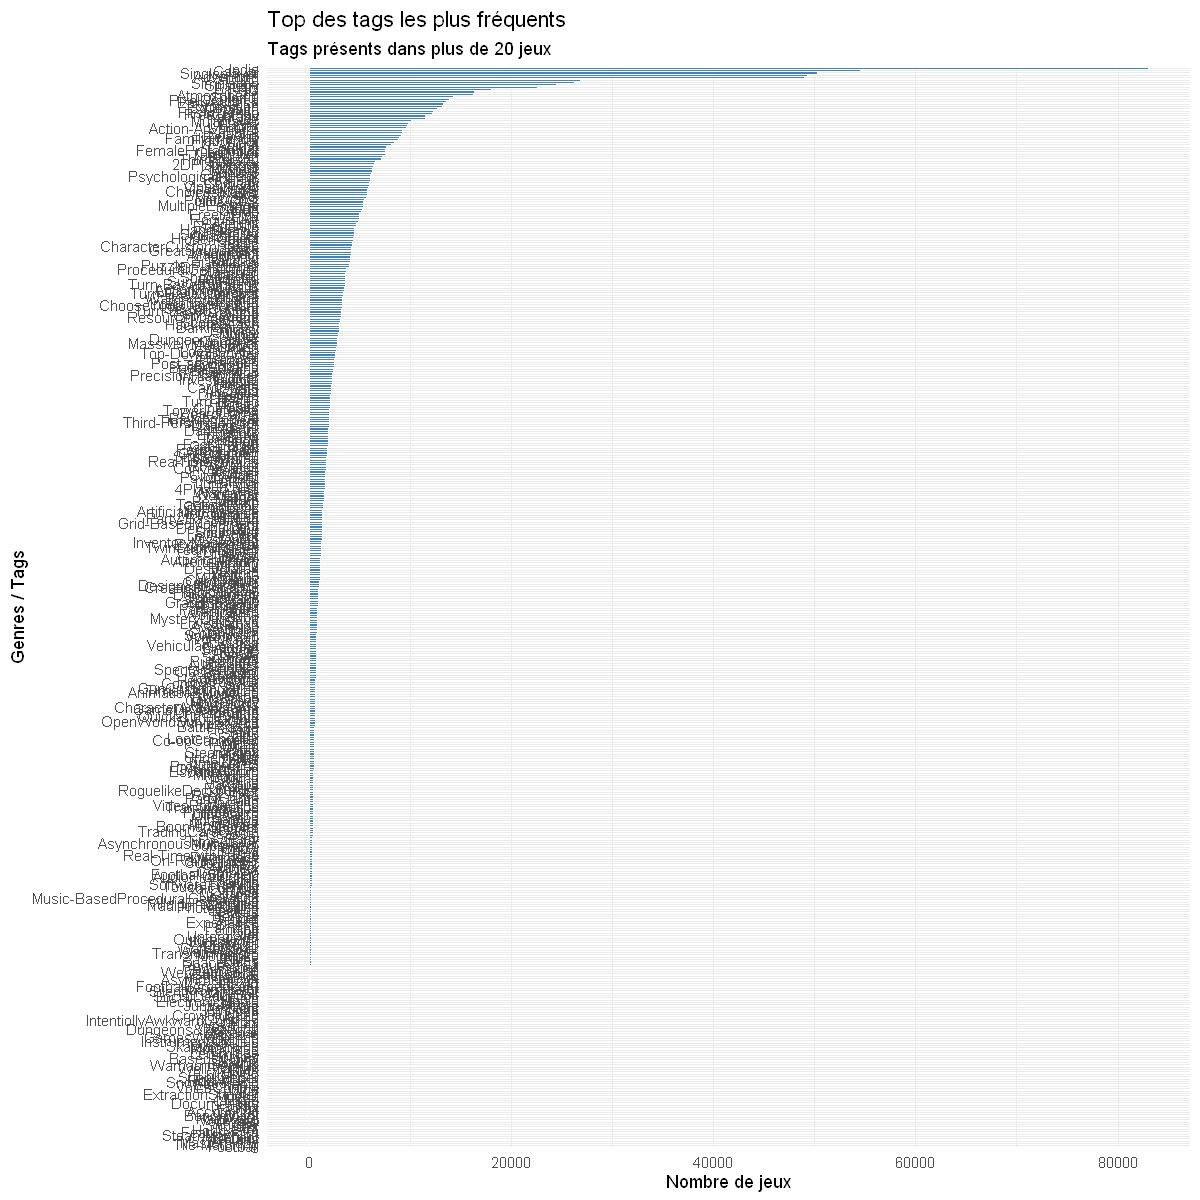

In [192]:
library(tidyverse)

# 1. Préparer les données (on garde le DataFrame, on ne fait pas pull)
df_tags <- data_ready %>%
  separate_rows(TagGenre, sep = ", ") %>%
  mutate(TagGenre = trimws(TagGenre)) %>% # Nettoie les espaces
  filter(TagGenre != "" & TagGenre != "Sans_Tag") %>% # Optionnel: filtrer les vides
  count(TagGenre) 

# 2. Créer le graphique
p <- ggplot(df_tags, aes(x = reorder(TagGenre, n), y = n)) +
  geom_col(fill = "steelblue", color = "white") + # geom_col est mieux quand on a déjà calculé 'n'
  coord_flip() +
  theme_minimal() +
  labs(
    title = "Top des tags les plus fréquents",
    subtitle = "Tags présents dans plus de 20 jeux",
    x = "Genres / Tags",
    y = "Nombre de jeux"
  )

print(p)
print(dim(df_tags))

In [197]:

data_one_hot <- data_ready %>%
  # 1. On remplace les NA et les chaînes vides par un nom explicite
  mutate(TagGenre = ifelse(is.na(TagGenre) | TagGenre == "", "Sans_Tag", TagGenre)) %>%
  
  # 2. On sépare les tags
  separate_rows(TagGenre, sep = ",") %>% 
  
  # 3. On nettoie les espaces (ex: " Action" -> "Action")
  mutate(TagGenre = str_trim(TagGenre)) %>%   
  # 5. One-Hot Encoding
  mutate(presence = 1) %>%
  pivot_wider(
    names_from = TagGenre, 
    values_from = presence, 
    values_fill = 0
  )

In [199]:
summary(data_one_hot)


     Name              Release.date    Estimated.owners    Peak.CCU        
 Length:114513      2025-2026:21812   0-20K    :75337   Min.   :0.000e+00  
 Class :character   2024     :18104   0        :13649   1st Qu.:0.000e+00  
 Mode  :character   2023     :13337   20K-50K  :11395   Median :0.000e+00  
                    2022     :11403   50K-100K : 5349   Mean   :5.844e+01  
                    2021     :10441   100K-200K: 3450   3rd Qu.:0.000e+00  
                    2020     : 8746   200K-500K: 2845   Max.   :1.014e+06  
                    (Other)  :30670   (Other)  : 2488                      
  Required.age        Price             Discount        DLC.count        
 0      :113288   Min.   :   0.000   Min.   :  0.00   Min.   :   0.0000  
 17     :   782   1st Qu.:   0.890   1st Qu.:  0.00   1st Qu.:   0.0000  
 13     :   175   Median :   2.690   Median :  0.00   Median :   0.0000  
 18     :   164   Mean   :   5.093   Mean   : 19.62   Mean   :   0.5549  
 16     :    31   3rd 

In [ ]:

# 1. Sélectionne uniquement tes colonnes One-Hot (les tags)
# Supprime les colonnes comme le titre du jeu ou l'ID pour l'analyse
df_mca <- data_one_hot %>% select(-c(1:)) 

# 2. Lancer l'ACM
res.mca <- MCA(df_mca, graph = FALSE)

# 3. Visualiser les catégories (les tags)
fviz_mca_var(res.mca, 
             repel = TRUE, # Évite que les noms se chevauchent
             ggtheme = theme_minimal())

 **Etude qu'on peut faire**: 
 - quels sont les individus(jeux) qui sont présent sur linux et Mac,peut etre les jeux qui sont les plus connus
 - est- ce que les jeux qui ont des restriction d'age marche mieux ou moins bien que les jeux sans?
 - ...

# Filtrage

## Etude variables par variables: gestion et suppression outliers

### Etude sur la variable supported.language

In [ ]:
head(data_filtered[,"Supported.languages"])

Plutôt que de garder la variable supported.languages qui ne contient que des chaines de caractère. On peut plutôt étudier le nombre de jeu supporté par chaque langue (première cellule) ou par jeux le nombre de langue supporté et est ce que ça à une influence sur la note du jeu ou autre chose (deuxième cellule).

In [ ]:
stats_langues <- data_filtered %>%
  # 1. On nettoie les symboles parasites [ ] ' "
  mutate(clean_txt = str_remove_all(Supported.languages, "\\[|\\]|'|\"")) %>%
  # 2. On "éclate" les listes : si un jeu a 3 langues, ça crée 3 lignes
  separate_rows(clean_txt, sep = ",\\s*") %>%
  # 3. On compte combien de fois chaque langue apparaît
  count(clean_txt, sort = TRUE) %>%
  # 4. On garde les 50 premières (en enlevant les vides)
  filter(clean_txt != "" & !is.na(clean_txt)) %>%
  head(40)


ggplot(stats_langues, aes(x = reorder(clean_txt, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() + # Pour mettre les noms à l'horizontale 
  labs(
    title = "Top 40 des langues les plus supportées sur Steam",
    x = "Langue",
    y = "Nombre de jeux"
  ) +
  theme_minimal()

language count variable

In [ ]:
data_filtered <- data_filtered|>
  mutate(nb_language_supported = case_when(          
    TRUE ~ str_count(Supported.languages, ",") + 1  
  ))
head(data_filtered$nb_language_supported)

### Etude des variables developers et publishers

Je propose de faire de même pour les variables developers et publishers: c'est à dire de regarder si la note du jeu a un lien avec sont studio de développement et son publieur. J'ai converti les chaines de caractères en minuscule et envelevé les points car dans un premier temps j'ai vu que certains chaines de caractère étaient la même mais juste en majuscule .

In [ ]:

# 1. On définit la liste des suffixes à nettoyer (le "bruit")
# Tu peux en ajouter d'autres ici si tu en vois de nouveaux dans tes données
bruit_juridique <- c("LTD", "INC", "LLC", "CORP", "CO", "SA", "SAS", "GMBH", "KK", "SL", "AS")

# On crée le "pattern" de recherche (Regex) : 
# Il cherche ces mots uniquement à la fin de la ligne (d'où le $)
pattern_bruit <- paste0("\\s*\\b(", paste(bruit_juridique, collapse = "|"), ")\\b[. ]*$")

# 2. Traitement du dataset
stat_dev_clean <- data_filtered |>
  # Nettoyage des crochets et guillemets de la liste brute
  mutate(Developers = str_remove_all(Developers, "['\\[\\]]")) |>
  
  # On sépare les jeux en multi-développeurs (une ligne par studio)
  separate_rows(Developers, sep = ",\\s*") |>
  
  # Nettoyage et standardisation
  mutate(
    dev_final = Developers |>
      str_to_upper() |>              # Tout en MAJ pour fusionner (ltd = LTD)
      str_remove_all("\\.") |>       # On enlève les points (INC. -> INC)
      str_remove_all(pattern_bruit)|> # On enlève les suffixes définis plus haut
      str_trim()                     # On enlève les espaces restants
  ) |>
  
  # On évite de compter deux fois le même dev sur un même jeu
  distinct() |>
  
  # On compte et on filtre
  count(dev_final, sort = TRUE) |>
  filter(dev_final != "" & !is.na(dev_final)) |>
  head(40)
  

# 3. Création du graphique
ggplot(stat_dev_clean, aes(x = reorder(dev_final, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Top 40 des développeurs les plus actifs sur Steam",
    subtitle = "Données nettoyées (suffixes juridiques harmonisés)",
    x = "Développeur",
    y = "Nombre de jeux"
  ) +
  theme_minimal()



In [ ]:

# 1. On définit la liste des suffixes à harmoniser (le "bruit")
bruit_juridique <- c("LTD", "INC", "LLC", "CORP", "CO", "SA", "SAS", "GMBH", "KK", "SL", "AS")
pattern_bruit <- paste0("\\s*\\b(", paste(bruit_juridique, collapse = "|"), ")\\b[. ]*$")

# 2. Nettoyage et préparation des données
stat_publisher <-data_filtered |>
  # Nettoyage des symboles de liste et des textes entre parenthèses (ex: (Mac))
  mutate(clean_publ = Publishers |> 
           str_remove_all("['\\[\\]]") |> 
           str_remove_all("\\(.*?\\)")) |> 
  
  # On sépare les co-éditeurs (une ligne par éditeur)
  separate_rows(clean_publ, sep = ",\\s*") |>
  
  # STANDARDISATION POUSSÉE
  mutate(
    clean_publ = clean_publ |>
      str_to_upper() |>              # Tout en MAJUSCULES pour fusionner les variantes
      str_remove_all("\\.") |>       # On enlève les points (INC. -> INC)
      str_remove_all(pattern_bruit) |> # On enlève les suffixes (LTD, LLC...)
      str_trim()                     # On nettoie les espaces restants
  ) |>
  
  # On évite de compter deux fois le même éditeur pour un même jeu (doublons internes)
  distinct() |>
  
  # On compte
  count(clean_publ, sort = TRUE) |>
  filter(clean_publ != "" & !is.na(clean_publ)) |>
  
  # On prend les 30 premiers pour le graphique
  head(30)

# 3. Visualisation moderne
ggplot(stat_publisher, aes(x = reorder(clean_publ, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() + # On garde coord_flip ou on inverse x et y dans aes()
  labs(
    title = "Top 30 des éditeurs sur Steam",
    subtitle = "Données nettoyées : suffixes supprimés et collaborations séparées",
    x = "Éditeurs",
    y = "Nombre de jeux"
  ) +
  theme_minimal()


### Etude variable release.date

A voir  comment les traiter: en variable qualitative ou autre .

### Etude required.age

In [ ]:
ggplot(data_filtered, aes(x = factor(1),fill = Required.age))+ geom_bar(width = 1) +
  coord_polar("y") +
  theme_void() +
  labs(
    title = "Répartition des jeux par limite d'âge",
    fill = "Âge Requis"
  )

On remarque que les jeux qui n'ont pas de limites sont en grande majorité qui rends la lecture du pie chart compliquée. Il faudrait enlevé cette modalité pour réaliser la stat descriptive. C'est ce qui est fait dans la cellule suivante.

In [ ]:


# filtrage de 0
data_age <- data_filtered |> 
  filter(as.character(Required.age) != "0")


ggplot(data_age, aes(x = factor(1), fill = factor(Required.age))) +
  geom_bar(width = 1) +
  coord_polar("y") +
  theme_void() + 
  labs(
    title = "Répartition des restrictions d'âge (Hors 0+)",
    fill = "Âge"
  )

On remarque une majorité de restriction pour les moins de 17 ans.

# Traitement des outliers

In [ ]:

data2 <- data_filtered[data_filtered$Estimated.owners != "0 - 0", ]

dim(data2)


In [ ]:

data2$Positive=data2$Positive+1
data2$Negative=data2$Negative+1


data2[, "LPositive"] <- log(data2[, "Positive"])

data2[, "LNegative"] <- log(data2[, "Negative"])


In [ ]:
g1<-ggplot(data1,aes(x=Positive))+ geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=100)
g2<-ggplot(data1,aes(x=Negative)) + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=100)
 grid.arrange(g1,g2,ncol=2)

In [ ]:



 lg1<-ggplot(data2,aes(x=LPositive))+geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)))
 lg2<-ggplot(data2,aes(x=LNegative))+geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)))  

 grid.arrange(lg1,lg2,ncol=2)

# Concaténation variable Tag et genres

On concatène les variables Tags et Genres car on s'est rendu compte que la variables Tags contenait la variable Genres la plus part du temps.

In [ ]:

data3 <- data2 %>%
  # 1. On travaille ligne par ligne
  rowwise() %>%
  
  mutate(
    # 2. On fusionne les deux colonnes
    temp_concat = paste(Tags, Genres, sep = ","),
    
    # 3. On nettoie à l'intérieur de la ligne
    Tags_Genres_Final = temp_concat %>%
      # On découpe par la virgule
      str_split(",") %>%
      # On transforme en vecteur simple
      unlist() %>%
      # On enlève les espaces inutiles
      str_trim() %>%
      # On enlève les vides, les "NA", "NaN", "null" (insensible à la casse)
      .[. != "" & !is.na(.) & !str_detect(tolower(.), "^na$|nan|null")] %>%
      # On garde les valeurs uniques (supprime les doublons entre Tags et Genres)
      unique() %>%
      # On recolle le tout
      paste(collapse = ", ")
  ) %>%
  
  # 4. On repasse en mode normal et on supprime la colonne temporaire
  ungroup() %>%
  select(-temp_concat)


In [ ]:
head(data3)

### On enleve les anciennes variables que l'on a modifié

In [ ]:
data4 <- data3 %>% select(-c(Tags,Genres,Positive,Negative))

In [ ]:
summary(data4)

## Etude variariable métacrique score

C'est une variable très importante qu'il faudra exploiter. C'est une note moyenne donnée par des journalistes, des magazines de jeux vidéo et des sites web experts. Cette note est entre 0 et 100 plus on est proche de 100 mieux c'est. Cependant, beaucoup de jeux n'ont pas de note car peux de journaux ont parlé d'eux assez pour que Steam en prenne compte dans une note, donc qu'il est une note different de 0.

In [ ]:

100-(sum(data4$Metacritic.score == 0)/length(data$Metacritic.score))*100

En effet, il y a que 21% des jeux qui ont une note superieur à 0. La question c'est est ce qu'on garde que c'est jeux là pour une étude pour prédire le score metacritic?  

### Etude temps de jeux

In [ ]:
ggplot(data4, aes(x = Average.playtime.forever)) +
  geom_histogram(fill = "skyblue", color = "white", bins = 30) +
  theme_minimal() +
  labs(title = "Distribution du temps de jeu (Échelle Logarithmique)")

ggplot(data4, aes(x = Median.playtime.forever)) +
  geom_histogram(fill = "skyblue", color = "white", bins = 30) +
  theme_minimal() +
  labs(title = "Distribution du temps de jeu (Échelle Logarithmique)")

In [ ]:
sum(data4$Average.playtime.forever==0)
sum(data4$Median.playtime.forever==0)

On se rend compte que le nombre de jeux qui on un temps de jeux égale à 0 fausse l'étude: on a qu'un seul pic à 0. Aussi, on remarque que l'on a une échelle en x de 1e+06 ce qui veut dire que l'on a aussi des jeux qui ont un temps de jeux énorme donc en plus d'enlever les 0 on va transformer en log les données.

In [ ]:

data5 <- data4 %>%
    filter(
    Average.playtime.forever > 0,         
    Median.playtime.forever > 0
 
  ) %>%
  # 2. On calcule les versions Log
  mutate(
    LAverage_playtime = log(Average.playtime.forever),
    LMedian_playtime = log(Median.playtime.forever)
  ) 

# Visualisation pour vérifier l'effet du Log
ggplot(data5, aes(x = LAverage_playtime)) +
  geom_histogram(fill = "skyblue", color = "white", bins = 30) +
  theme_minimal() +
  labs(title = "Distribution du temps de jeu (Échelle Logarithmique)")

ggplot(data5, aes(x = LMedian_playtime)) +
  geom_histogram(fill = "skyblue", color = "white", bins = 30) +
  theme_minimal() +
  labs(title = "Distribution du temps de jeu (Échelle Logarithmique)")

Ainsi, on peut se satisfaire de ces graphs.**on pourra supprimerAverage.playtime.forever, Median.playtime.forever et garder la version log**

# Etude influence estimated_owners

In [ ]:
head(data5$Estimated.owners)

Pour que ça soit plus clair je vais renommer les variables car on peut se perdre dans la notation

In [ ]:
data_rename <- data5 %>%
  mutate(Estimated.owners = fct_recode(Estimated.owners,
    "0"           = "0 - 0",
    "0-20K"       = "0 - 20000",
    "20K-50K"     = "20000 - 50000",
    "50K-100K"    = "50000 - 100000",
    "100K-200K"   = "100000 - 200000",
    "200K-500K"   = "200000 - 500000",
    "500K-1M"     = "500000 - 1000000",
    "1M-2M"       = "1000000 - 2000000",
    "2M-5M"       = "2000000 - 5000000",
    "5M-10M"      = "5000000 - 10000000",
    "10M-20M"     = "10000000 - 20000000",
    "20M-50M"     = "20000000 - 50000000",
    "50M-100M"    = "50000000 - 100000000",
    "100M-200M"   = "100000000 - 200000000"
  ))

In [ ]:
ggplot(data_rename, aes(x=Estimated.owners)) + 
  geom_bar()+labs(title = "Répartition des ventes (Owners)", x = "Nombre de possesseurs", y = "Nombre de jeux")

On va devoir ordonner les modalités car elle ne permettent pas d'être lu dans l'odre croissant des détenteur des jeux

In [ ]:
ordre_logique <- c(
  "0", "0-20K", "20K-50K", "50K-100K", "100K-200K", 
  "200K-500K", "500K-1M", "1M-2M", "2M-5M", "5M-10M", 
  "10M-20M", "20M-50M", "50M-100M", "100M-200M"
)

data_rename <- data_rename %>%
  mutate(Estimated.owners = fct_relevel(Estimated.owners, ordre_logique))


In [ ]:
ggplot(data_rename, aes(x=Estimated.owners)) + 
  geom_bar()+labs(title = "Répartition des ventes (Owners)", x = "Nombre de possesseurs", y = "Nombre de jeux")

On remarque qu'il y a tres peu de jeux qui sont téléchargés en très grande quantités. La plupart des jeux on entre 0 et 20K utilisateurs.

In [ ]:
nrow(data_rename)

## Etude du prix sur estimated owners

On peut commencer par étudier l'inflence des prix des jeux sur le succés des jeux. Par exemple, qu'elle est la part des jeux gratuits. Pour cela on va créer un nouveau data_frame  sans les jeux gratuit et un DF qui répertorie le nombre de jeux gratuit par tranche et le pourcentage des jeux gratuits par rapport à la totalité des jeux.

In [ ]:

df_percent_free <- data_rename %>%
  group_by(Estimated.owners) %>%
  summarise(
    total = n(),
    gratuits = sum(Price == 0, na.rm = TRUE),
    percent_free = (gratuits / total) * 100
  )


df_wo_free <- data_rename %>%
  filter(Price != 0)

In [ ]:
tail(df_percent_free)
head(df_wo_free)

In [ ]:
ggplot(df_percent_free, aes(x = Estimated.owners, y = percent_free)) +
  geom_col(fill = "darkgreen") +
  coord_flip() +
  theme_minimal() +
  labs(
    title = "Part des jeux gratuits par tranche de possesseurs",
    x = "Tranche d'owners",
    y = "% de jeux gratuits"
  )

On constate que la plupart des jeux gratuits sont les jeux qui "marchent" le plus en pourcentage.

## Inflence variable L_positive et L_negative

Plutôt que d'utiliser les variables metacritic.score ou user.score qui contiennent enormément de 0 (équivalent à pas de note on va analyser les variables transformée LNegative et LPositive.

In [ ]:
ggplot(data_rename, aes(x = Estimated.owners, y = LPositive, fill = Estimated.owners)) +
  geom_boxplot() +
  coord_flip() +
  theme_minimal() +
  labs(title = "Nombre de Reviews Positives (Log) par tranche de succès")

In [ ]:
ggplot(data_rename, aes(x = Estimated.owners, y = LNegative, fill = Estimated.owners)) +
  geom_boxplot() +
  coord_flip() +
  theme_minimal() +
  labs(title = "Nombre de Reviews Negative (Log) par tranche de détention")

L'analyse des boxplots montre une progression quasi linéaire entre le logarithme des reviews (positives et négatives) et les tranches de détention. Nous pouvons en conclure que le succès commercial (Estimated.owners) est l'un des principals facteur du volume d'expression des joueurs. Bien que les deux courbes ont la même tendance, l'échelle atteinte par les critiques positives est nettement supérieure que les critiques négatives. Avec un plafond à environ $e^{15}$  (environ 3,2 millions) contre $e^{13}$ (~440 000) pour les négatives, on constate que le succès sur Steam reste fortement lié à une satisfaction globale. Plus on augmente en popularité plus le nombre de critique tout court mais aussi positive augmente.

Pour vérifier que les tranches de owners les plus élévés est des critiques positives en plus grand nombre que les critiques négatives on va réaliser une ratio (score) de satisfaction. Pour cela je vais revenir au variables sans le log sinon ça va fausser le résultat.

In [ ]:
df_ratio <- data_rename %>%
  mutate(
    Vraies_Positives = exp(LPositive) - 1, 
    Vraies_Negatives = exp(LNegative) - 1,
    
    Total_Reviews = Vraies_Positives + Vraies_Negatives,
    
    # Calcul du vrai ratio de satisfaction
    Satisfaction_Ratio = ifelse(Total_Reviews > 0, 
                                (Vraies_Positives / Total_Reviews) * 100, 
                                NA)
  ) %>%
  group_by(Estimated.owners) %>%
  summarise(
    Moyenne_Satisfaction = mean(Satisfaction_Ratio, na.rm = TRUE),
    Mediane_Satisfaction = median(Satisfaction_Ratio, na.rm = TRUE),
    Nb_Jeux = n()
  )

print(df_ratio)

In [ ]:
ggplot(df_ratio, aes(x = Estimated.owners, y = Moyenne_Satisfaction)) +

  geom_col(fill = "darkolivegreen", alpha = 0.8) +
  theme_minimal() +
  labs(
    title = "Taux de satisfaction moyen par tranche de ventes",
    subtitle = "Moyenne du ratio (Positives / Total) par catégorie d'owners",
    x = "Tranches de owners",
    y = "Satisfaction moyenne (%)"
  )

L'analyse du taux de satisfaction moyen révèle une dynamique non-linéaire. Si la satisfaction croît mécaniquement avec le volume de ventes jusqu'au palier des 5 millions d'owners (validant l'idée que la qualité perçue booste les ventes), on observe une baisse du ratio pour les jeux dépassant les 100 millions de détenteurs. On peut trouver plusieurs raions à cette décroissance commme: 
- les joueurs postent souvent des reviews négatives après beaucoup d'heures de jeu suite à une mise à jour qu'ils n'ont pas aimé, même s'ils aiment le jeu.
- Ou bien quand un jeu devient un vraiment un succes international, il attire des joueurs qui ne sont pas forcément la cible de base, ce qui augmente les critiques négatives.

## Inflence du genre

## Influence du logiciel (windows , mac, linux)

# ACP 

## Création dataframe avec variable quantitative

In [ ]:
df_pca <- data_rename %>%
  select(where(is.numeric)) %>%
  select(-contains("AppID"), -any_of(c("Release.date", "Required.age","Peak.CCU","Metacritic.score","User.score","Achievements","Median.playtime.forever","Average.playtime.forever"))) 


# Vérification de la taille finale
print(paste("Nombre de lignes pour l'ACP :", nrow(df_pca)))
print(colnames(df_pca))

In [ ]:
res.pca <- PCA(df_pca, scale.unit = TRUE, graph = FALSE)

In [ ]:
res.pca <- PCA(df_pca, scale.unit = TRUE, graph = FALSE)
fviz_eig(res.pca)
res.pca$eig

On regarde quand il y a un coude présent soir garder 4 dimensions cela explique 65% de la variance: c'est un peu bas (inférieur à 80%).On va continuer notre analyse pour voir si on peu en dire plus de choses.

In [ ]:
fviz_pca_var(res.pca,axes = c(1,2),repel=TRUE)
fviz_pca_var(res.pca,axes = c(1,3),repel=TRUE)
fviz_pca_var(res.pca,axes = c(1,4),repel=TRUE)
fviz_pca_var(res.pca,axes = c(2,3),repel=TRUE)
fviz_pca_var(res.pca,axes = c(2,4),repel=TRUE)


Commentaires:

In [ ]:
fviz_pca_biplot(res.pca,axes = c(1,2),repel=TRUE)
fviz_pca_biplot(res.pca,axes = c(1,3),repel=TRUE)
fviz_pca_biplot(res.pca,axes = c(1,4),repel=TRUE)
fviz_pca_biplot(res.pca,axes = c(2,3),repel=TRUE)
fviz_pca_biplot(res.pca,axes = c(2,4),repel=TRUE)


In [ ]:
fviz_pca_biplot(res.pca,axes = c(2,4))